<a id="top"></a>

# COMP9414 - Assignment 2 - Collaborative Multi-Agent Reinforcement Learning
### z5742721 - Troy Coleman

## Contents

- [Task 1: Multi-Agent Reinforcement Learning Environment](#task-1)
  - [1.1: Gridworld Implementation](#t-1-1)
  - [1.2: Gridworld Visualization](#t-1-2)
  - [1.3: Demonstration Script](#t-1-3)
  - [1.4: Collision Verification](#t-1-4)
- [Task 2: Modular PPO Pipeline Construction](#task-2)
  - [2.1: PPO Actor and Critic](#t-2-1)
  - [2.2: Rollout Buffer Module](#t-2-2)
  - [2.3: Advantage Estimator Module](#t-2-3)
  - [2.4: Optimizer Module](#t-2-4)
- [Task 3: Independent Proximal Policy Optimization](#task-3)
  - [3.1: Source](#t-3-1)
  - [3.2: IPPO Training Results](#t-3-2)
  - [3.3: IPPO Performance Evaluation](#t-3-3)
  - [3.4: IPPO Visual Demonstration](#t-3-4)
- [Task 4: Multi-Agent Proximal Policy Optimization](#task-4)
  - [4.1: Source](#t-4-1)
  - [4.2: MAPPO Training Results](#t-4-2)
  - [4.3: MAPPO Performance Evaluation](#t-4-3)
  - [4.4: MAPPO Visual Demonstration](#t-4-4)
- [Task 5: Comprehensive Evaluation](#task-5)
  - [5.1: Generalization Analysis](#t-5-1)
  - [5.2: Global Redundancy Coverage Ratio Map](#t-5-2)
  - [5.3: Agents' Contribution Analysis](#t-5-3)
  - [5.4: Jensen–Shannon Divergence Pairwise Matrix](#t-5-4)


In [227]:
from __future__ import annotations

FAST_MODE = True
RUN_TRAINING = True

import importlib
import importlib.util
import subprocess
import sys

_required_packages = {
    "numpy": "numpy",
    "pandas": "pandas",
    "matplotlib": "matplotlib",
    "torch": "torch",
    "tqdm": "tqdm",
}

_missing_packages = [
    package
    for module, package in _required_packages.items()
    if importlib.util.find_spec(module) is None
]

if _missing_packages:
    subprocess.check_call([
        sys.executable,
        "-m",
        "pip",
        "install",
        *_missing_packages,
    ])
    importlib.invalidate_caches()

import json
import math
import os
import platform
import random
import re
import time
from dataclasses import asdict, dataclass, field
from enum import IntEnum
from pathlib import Path
from typing import Dict, Iterable, List, Optional, Sequence, Tuple

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from IPython.display import display
from torch.distributions import Categorical
from torch.utils.data import BatchSampler, SubsetRandomSampler

try:
    from tqdm.auto import trange
except ImportError:
    trange = range

SEED = 42
MODEL_INITIALIZATION_SEED = 7_941
DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

ARTIFACT_DIR = Path("assignment2_artifacts")
FIGURE_DIR = ARTIFACT_DIR / "figures"
CHECKPOINT_DIR = ARTIFACT_DIR / "checkpoints"
DATA_DIR = ARTIFACT_DIR / "data"

for directory in (
    ARTIFACT_DIR,
    FIGURE_DIR,
    CHECKPOINT_DIR,
    DATA_DIR,
):
    directory.mkdir(parents=True, exist_ok=True)


def set_global_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


set_global_seed(SEED)


@dataclass(frozen=True)
class PPOConfig:
    gamma: float = 0.95
    gae_lambda: float = 0.95
    clip_epsilon: float = 0.20

    actor_learning_rate: float = 3e-4
    critic_learning_rate: float = 1e-3

    entropy_coefficient: float = 0.01
    value_coefficient: float = 0.50
    max_gradient_norm: float = 0.50

    rollout_length: int = 400
    minibatch_size: int = 200
    update_epochs: int = 8

    hidden_dimensions: Tuple[int, ...] = (128, 128)
    weight_decay: float = 1e-5


@dataclass(frozen=True)
class ExperimentConfig:
    training_updates: int
    evaluation_episodes: int
    generalisation_episodes: int
    probe_observations: int
    bootstrap_samples: int


FAST_PPO_CONFIG = PPOConfig(
    rollout_length=32,
    minibatch_size=16,
    update_epochs=1,
    hidden_dimensions=(32, 32),
)

FULL_PPO_CONFIG = PPOConfig()

FAST_EXPERIMENT_CONFIG = ExperimentConfig(
    training_updates=1,
    evaluation_episodes=2,
    generalisation_episodes=3,
    probe_observations=24,
    bootstrap_samples=250,
)

FULL_EXPERIMENT_CONFIG = ExperimentConfig(
    training_updates=300,
    evaluation_episodes=250,
    generalisation_episodes=400,
    probe_observations=256,
    bootstrap_samples=5_000,
)

PPO_CONFIG = (
    FAST_PPO_CONFIG
    if FAST_MODE
    else FULL_PPO_CONFIG
)

EXPERIMENT_CONFIG = (
    FAST_EXPERIMENT_CONFIG
    if FAST_MODE
    else FULL_EXPERIMENT_CONFIG
)

plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 180,
    "axes.titleweight": "bold",
    "axes.titlesize": 14,
    "axes.labelsize": 11,
    "legend.frameon": False,
    "font.size": 10,
})


def slugify(text: str) -> str:
    return re.sub(
        r"[^a-z0-9]+",
        "_",
        text.lower(),
    ).strip("_")


def finish_axis(
    axis,
    title: str,
    x_label: Optional[str] = None,
    y_label: Optional[str] = None,
    legend: bool = False,
) -> None:
    axis.set_title(title, pad=12)

    if x_label:
        axis.set_xlabel(x_label)

    if y_label:
        axis.set_ylabel(y_label)

    axis.grid(
        axis="y",
        linestyle="--",
        linewidth=0.7,
        alpha=0.45,
    )
    axis.spines["top"].set_visible(False)
    axis.spines["right"].set_visible(False)

    if legend:
        axis.legend(ncol=3, loc="best")


def save_and_show(figure, title: str) -> Path:
    path = FIGURE_DIR / f"{slugify(title)}.png"
    figure.savefig(path, bbox_inches="tight")
    plt.show()
    return path


def rolling_mean(
    values: Sequence[float],
    window: int,
) -> np.ndarray:
    values = np.asarray(values, dtype=float)

    if window <= 1 or len(values) < window:
        return values.copy()

    result = np.full_like(
        values,
        np.nan,
        dtype=float,
    )
    result[window - 1:] = np.convolve(
        values,
        np.ones(window) / window,
        mode="valid",
    )
    return result


def parameter_vector(
    model: nn.Module,
) -> torch.Tensor:
    return torch.cat([
        parameter.detach().reshape(-1).cpu()
        for parameter in model.parameters()
    ])


_environment_report = pd.DataFrame([
    {
        "Python executable": sys.executable,
        "Python": sys.version.split()[0],
        "NumPy": np.__version__,
        "pandas": pd.__version__,
        "Matplotlib": plt.matplotlib.__version__,
        "PyTorch": torch.__version__,
        "Device": str(DEVICE),
        "Platform": platform.platform(),
        "Fast mode": FAST_MODE,
    }
])

display(_environment_report)

display(pd.DataFrame({
    "PPO parameter": list(asdict(PPO_CONFIG).keys()),
    "Value": list(asdict(PPO_CONFIG).values()),
}))

,Python executable,Python,NumPy,pandas,Matplotlib,PyTorch,Device,Platform,Fast mode
0,C:\Users\isawe\AppData\Local\Programs\Python\P...,3.12.6,2.4.2,3.0.1,3.10.8,2.13.0+cpu,cpu,Windows-11-10.0.26200-SP0,True


,PPO parameter,Value
0,gamma,0.95
1,gae_lambda,0.95
2,clip_epsilon,0.2
3,actor_learning_rate,0.0003
4,critic_learning_rate,0.001
5,entropy_coefficient,0.01
6,value_coefficient,0.5
7,max_gradient_norm,0.5
8,rollout_length,32
9,minibatch_size,16


# <a id="task-1">Task 1: Multi-Agent Reinforcement Learning Environment</a>

<a id="task-1-navigation"></a>

> **Task 1 Navigation**

- [Back to Contents](#top)



- [1.1: Gridworld Implementation](#t-1-1)
- [1.2: Gridworld Visualization](#t-1-2)
- [1.3: Demonstration Script](#t-1-3)
- [1.4: Collision Verification](#t-1-4)

<a id="t-1-1"></a>

## <a id="t-1-1">1.1: Gridworld Implementation</a>

In [228]:
GRID_SIZE = 12
NUM_AGENTS = 3
ACTION_DIMENSION = 5
LOCAL_CHANNELS = 5
LOCAL_OBSERVATION_DIMENSION = GRID_SIZE * GRID_SIZE * LOCAL_CHANNELS
GLOBAL_STATE_DIMENSION = NUM_AGENTS * LOCAL_OBSERVATION_DIMENSION
MAX_EPISODE_STEPS = 50

START_POSITIONS = (
    (0, 2),   # Agent 1: assignment coordinate (1, 3)
    (11, 2),  # Agent 2: assignment coordinate (12, 3)
    (6, 11),  # Agent 3: assignment coordinate (7, 12)
)

FRAGILE_POSITIONS = frozenset({
    (1, 1), (3, 3), (5, 5), (6, 1), (7, 3), (9, 5),
    (0, 6), (3, 6), (7, 6), (11, 6),
    (2, 10), (7, 8), (5, 9), (10, 10),
})

FIXED_LARGE_DIRT = frozenset({
    (1, 4), (2, 8), (3, 1), (5, 6),
    (7, 7), (8, 3), (9, 10), (11, 1),
})

FIXED_NORMAL_DIRT = frozenset({
    (0, 3), (0, 9), (2, 1), (3, 7),
    (4, 8), (6, 2), (8, 10), (11, 5),
})

assert len(START_POSITIONS) == 3
assert len(FRAGILE_POSITIONS) == 14
assert len(FIXED_LARGE_DIRT) == 8
assert len(FIXED_NORMAL_DIRT) == 8

In [229]:
class Action(IntEnum):
    IDLE = 0
    UP = 1
    DOWN = 2
    LEFT = 3
    RIGHT = 4


class CleaningGridEnv:
    """Self-contained three-agent collaborative cleaning environment."""

    MOVEMENTS = {
        Action.IDLE: (0, 0),
        Action.UP: (-1, 0),
        Action.DOWN: (1, 0),
        Action.LEFT: (0, -1),
        Action.RIGHT: (0, 1),
    }

    def __init__(
        self,
        dirt_mode: str = 'fixed',
        seed: Optional[int] = None,
        truncate_on_safety_violation: bool = True,
    ) -> None:
        if dirt_mode not in {'fixed', 'random'}:
            raise ValueError("dirt_mode must be 'fixed' or 'random'.")

        self.dirt_mode = dirt_mode
        self.truncate_on_safety_violation = truncate_on_safety_violation
        self.rng = np.random.default_rng(seed)

        self.agent_positions: List[Tuple[int, int]] = []
        self.normal_dirt: set[Tuple[int, int]] = set()
        self.large_dirt: set[Tuple[int, int]] = set()
        self.explored_by = np.full((GRID_SIZE, GRID_SIZE), -1, dtype=np.int32)
        self.visit_map = np.zeros((GRID_SIZE, GRID_SIZE), dtype=np.int32)
        self.revisit_map = np.zeros((GRID_SIZE, GRID_SIZE), dtype=np.int32)
        self.step_count = 0
        self.last_info: Dict = {}

    def reset(self, seed: Optional[int] = None):
        if seed is not None:
            self.rng = np.random.default_rng(seed)

        self.agent_positions = list(START_POSITIONS)
        self.step_count = 0
        self.explored_by.fill(-1)
        self.visit_map.fill(0)
        self.revisit_map.fill(0)

        for agent_id, position in enumerate(self.agent_positions):
            self.explored_by[position] = agent_id
            self.visit_map[position] += 1

        if self.dirt_mode == 'fixed':
            self.normal_dirt = set(FIXED_NORMAL_DIRT)
            self.large_dirt = set(FIXED_LARGE_DIRT)
        else:
            self.normal_dirt, self.large_dirt = self._sample_random_dirt()

        self.last_info = self._build_info()
        return self.get_local_observations(), self.last_info.copy()

    def _sample_random_dirt(self):
        unavailable = set(START_POSITIONS) | set(FRAGILE_POSITIONS)
        candidates = [
            (row, col)
            for row in range(GRID_SIZE)
            for col in range(GRID_SIZE)
            if (row, col) not in unavailable
        ]
        selected = self.rng.choice(len(candidates), size=16, replace=False)
        cells = [candidates[index] for index in selected]
        return set(cells[:8]), set(cells[8:])

    @staticmethod
    def _inside_grid(position: Tuple[int, int]) -> bool:
        row, col = position
        return 0 <= row < GRID_SIZE and 0 <= col < GRID_SIZE

    def _detect_robot_collisions(
        self,
        proposed_positions: Sequence[Tuple[int, int]],
        violations: Dict[int, str],
    ) -> None:
        for first in range(NUM_AGENTS):
            for second in range(first + 1, NUM_AGENTS):
                same_target = proposed_positions[first] == proposed_positions[second]
                position_swap = (
                    proposed_positions[first] == self.agent_positions[second]
                    and proposed_positions[second] == self.agent_positions[first]
                )
                if same_target or position_swap:
                    violations[first] = 'robot_collision'
                    violations[second] = 'robot_collision'

    def step(self, actions: Sequence[int]):
        if len(actions) != NUM_AGENTS:
            raise ValueError(f'Expected {NUM_AGENTS} actions, got {len(actions)}.')

        actions = [Action(int(action)) for action in actions]
        self.step_count += 1

        # The team time-step penalty is applied to every agent.
        rewards = np.full(NUM_AGENTS, -0.1, dtype=np.float32)
        reward_events = [list() for _ in range(NUM_AGENTS)]

        for agent_id, action in enumerate(actions):
            reward_events[agent_id].append(('time_step', -0.1))
            if action == Action.IDLE:
                rewards[agent_id] -= 0.1
                reward_events[agent_id].append(('idle', -0.1))

        proposed_positions: List[Tuple[int, int]] = []
        violations: Dict[int, str] = {}

        for agent_id, (position, action) in enumerate(
            zip(self.agent_positions, actions)
        ):
            row_change, col_change = self.MOVEMENTS[action]
            proposed = (
                position[0] + row_change,
                position[1] + col_change,
            )

            if not self._inside_grid(proposed):
                violations[agent_id] = 'boundary'
                proposed = position
            elif proposed in FRAGILE_POSITIONS:
                violations[agent_id] = 'fragile_object'
                proposed = position

            proposed_positions.append(proposed)

        self._detect_robot_collisions(proposed_positions, violations)

        # Safety shield: unsafe actions are converted to IDLE.
        for agent_id in violations:
            proposed_positions[agent_id] = self.agent_positions[agent_id]
            rewards[agent_id] -= 20.0
            reward_events[agent_id].append((violations[agent_id], -20.0))

        self.agent_positions = proposed_positions

        for agent_id, position in enumerate(self.agent_positions):
            already_explored = self.explored_by[position] != -1
            self.visit_map[position] += 1

            if already_explored:
                self.revisit_map[position] += 1
                rewards[agent_id] -= 1.0
                reward_events[agent_id].append(('revisit', -1.0))
            else:
                self.explored_by[position] = agent_id
                rewards[agent_id] += 2.0
                reward_events[agent_id].append(('new_cell', 2.0))

            if position in self.normal_dirt:
                self.normal_dirt.remove(position)
                rewards[agent_id] += 2.0
                reward_events[agent_id].append(('normal_dirt', 2.0))

            if position in self.large_dirt:
                self.large_dirt.remove(position)
                rewards[agent_id] += 4.0
                reward_events[agent_id].append(('large_dirt', 4.0))

        terminated = not self.normal_dirt and not self.large_dirt
        safety_truncation = self.truncate_on_safety_violation and bool(violations)
        time_truncation = self.step_count >= MAX_EPISODE_STEPS and not terminated
        truncated = safety_truncation or time_truncation

        if terminated:
            rewards += 20.0
            for events in reward_events:
                events.append(('completion_bonus', 20.0))

        termination_reason = (
            'completed' if terminated
            else 'safety_violation' if safety_truncation
            else 'time_limit' if time_truncation
            else 'running'
        )

        info = self._build_info()
        info.update({
            'all_dirt_cleaned': terminated,
            'violation_agents': sorted(violations),
            'violation_reasons': violations,
            'reward_events': reward_events,
            'termination_reason': termination_reason,
            'global_rcr': self.global_rcr(),
        })
        self.last_info = info

        return self.get_local_observations(), rewards, terminated, truncated, info

    def _get_local_observation(self, agent_id: int) -> np.ndarray:
        observation = np.zeros(
            (GRID_SIZE, GRID_SIZE, LOCAL_CHANNELS),
            dtype=np.float32,
        )

        for position in FRAGILE_POSITIONS:
            observation[position][0] = 1.0

        observation[self.agent_positions[agent_id]][1] = 1.0

        for other_agent_id, position in enumerate(self.agent_positions):
            if other_agent_id != agent_id:
                observation[position][2] = 1.0

        observation[:, :, 3] = (self.explored_by != -1).astype(np.float32)
        observation[START_POSITIONS[agent_id]][4] = 1.0
        return observation

    def get_local_observations(self) -> np.ndarray:
        return np.stack([
            self._get_local_observation(agent_id)
            for agent_id in range(NUM_AGENTS)
        ])

    def get_global_state(self) -> np.ndarray:
        return self.get_local_observations()

    def weighted_cleaning_fraction(self) -> float:
        total_weight = 8 + 2 * 8
        remaining_weight = len(self.normal_dirt) + 2 * len(self.large_dirt)
        return float(1.0 - remaining_weight / total_weight)

    def global_rcr(self) -> float:
        return float(self.revisit_map.sum() / max(1, self.visit_map.sum()))

    def rcr_map(self) -> np.ndarray:
        return np.divide(
            self.revisit_map,
            self.visit_map,
            out=np.zeros_like(self.revisit_map, dtype=np.float32),
            where=self.visit_map > 0,
        )

    def _build_info(self) -> Dict:
        return {
            'step': self.step_count,
            'agent_positions': list(self.agent_positions),
            'normal_dirt_remaining': len(self.normal_dirt),
            'large_dirt_remaining': len(self.large_dirt),
            'weighted_dirt_remaining': (
                len(self.normal_dirt) + 2 * len(self.large_dirt)
            ),
            'weighted_cleaning_fraction': self.weighted_cleaning_fraction(),
        }

    def render(self, title: Optional[str] = None, show_legend: bool = True):
        from matplotlib.lines import Line2D
        from matplotlib.patches import Patch, Rectangle

        agent_colours = ('#F4D03F', '#58D68D', '#5DADE2')
        explored_colours = ('#FCF3CF', '#D5F5E3', '#D6EAF8')

        figure, axis = plt.subplots(figsize=(9.6, 8.5), constrained_layout=True)
        axis.set_facecolor('white')

        for row in range(GRID_SIZE):
            for col in range(GRID_SIZE):
                owner = int(self.explored_by[row, col])
                if owner >= 0:
                    axis.add_patch(Rectangle(
                        (col - 0.5, row - 0.5), 1, 1,
                        facecolor=explored_colours[owner],
                        edgecolor='none', zorder=0,
                    ))

        for row, col in FRAGILE_POSITIONS:
            axis.add_patch(Rectangle(
                (col - 0.5, row - 0.5), 1, 1,
                facecolor='#E74C3C', edgecolor='none', zorder=1,
            ))

        for row, col in self.large_dirt:
            axis.add_patch(Rectangle(
                (col - 0.5, row - 0.5), 1, 1,
                facecolor='#5D6D7E', edgecolor='none', zorder=2,
            ))

        for row, col in self.normal_dirt:
            axis.add_patch(Rectangle(
                (col - 0.5, row - 0.5), 1, 1,
                facecolor='#D5D8DC', edgecolor='none', zorder=2,
            ))

        for row, col in START_POSITIONS:
            axis.scatter(
                col, row, marker='*', s=270,
                facecolor='white', edgecolor='#17202A',
                linewidth=1.4, zorder=5,
            )

        for agent_id, (row, col) in enumerate(self.agent_positions):
            axis.add_patch(Rectangle(
                (col - 0.38, row - 0.38), 0.76, 0.76,
                facecolor=agent_colours[agent_id],
                edgecolor='#17202A', linewidth=1.4, zorder=6,
            ))
            axis.text(
                col, row, f'A{agent_id + 1}',
                ha='center', va='center', fontsize=9,
                fontweight='bold', color='#17202A', zorder=7,
            )

        axis.set_xlim(-0.5, GRID_SIZE - 0.5)
        axis.set_ylim(GRID_SIZE - 0.5, -0.5)
        axis.set_aspect('equal')
        axis.set_xticks(range(GRID_SIZE))
        axis.set_yticks(range(GRID_SIZE))
        axis.set_xticklabels(range(1, GRID_SIZE + 1))
        axis.set_yticklabels(range(1, GRID_SIZE + 1))
        axis.set_xticks(np.arange(-0.5, GRID_SIZE, 1), minor=True)
        axis.set_yticks(np.arange(-0.5, GRID_SIZE, 1), minor=True)
        axis.grid(which='minor', linewidth=0.8, color='#566573')
        axis.tick_params(which='minor', bottom=False, left=False)
        axis.set_xlabel('Column')
        axis.set_ylabel('Row')
        axis.set_title(
            title or f'Collaborative Cleaning Grid — Step {self.step_count}',
            pad=14,
        )

        if show_legend:
            legend_items = [
                Patch(facecolor='#E74C3C', label='Fragile object'),
                Patch(facecolor='#5D6D7E', label='Large dirt'),
                Patch(facecolor='#D5D8DC', label='Normal dirt'),
                Patch(facecolor=agent_colours[0], label='Agent 1'),
                Patch(facecolor=agent_colours[1], label='Agent 2'),
                Patch(facecolor=agent_colours[2], label='Agent 3'),
                Line2D(
                    [0], [0], marker='*', linestyle='none',
                    markerfacecolor='white', markeredgecolor='#17202A',
                    markersize=12, label='Docking position',
                ),
            ]
            axis.legend(
                handles=legend_items,
                loc='upper left', bbox_to_anchor=(1.02, 1.0),
                title='Grid contents', frameon=True,
            )

        return figure, axis

In [230]:
fixed_environment = CleaningGridEnv(
    "fixed",
    seed=SEED,
)
fixed_observations, fixed_info = (
    fixed_environment.reset()
)

display(pd.DataFrame([fixed_info]))

assert fixed_observations.shape == (
    NUM_AGENTS,
    GRID_SIZE,
    GRID_SIZE,
    LOCAL_CHANNELS,
)
assert fixed_environment.get_global_state().shape == (
    NUM_AGENTS,
    GRID_SIZE,
    GRID_SIZE,
    LOCAL_CHANNELS,
)

,step,agent_positions,normal_dirt_remaining,large_dirt_remaining,weighted_dirt_remaining,weighted_cleaning_fraction
0,0,"[(0, 2), (11, 2), (6, 11)]",8,8,24,0.0


<a id="t-1-2"></a>

## <a id="t-1-2">1.2: Gridworld Visualization</a>

Local observations: (3, 12, 12, 5)
Global state: (3, 12, 12, 5)
Initial info: {'step': 0, 'agent_positions': [(0, 2), (11, 2), (6, 11)], 'normal_dirt_remaining': 8, 'large_dirt_remaining': 8, 'weighted_dirt_remaining': 24, 'weighted_cleaning_fraction': 0.0}


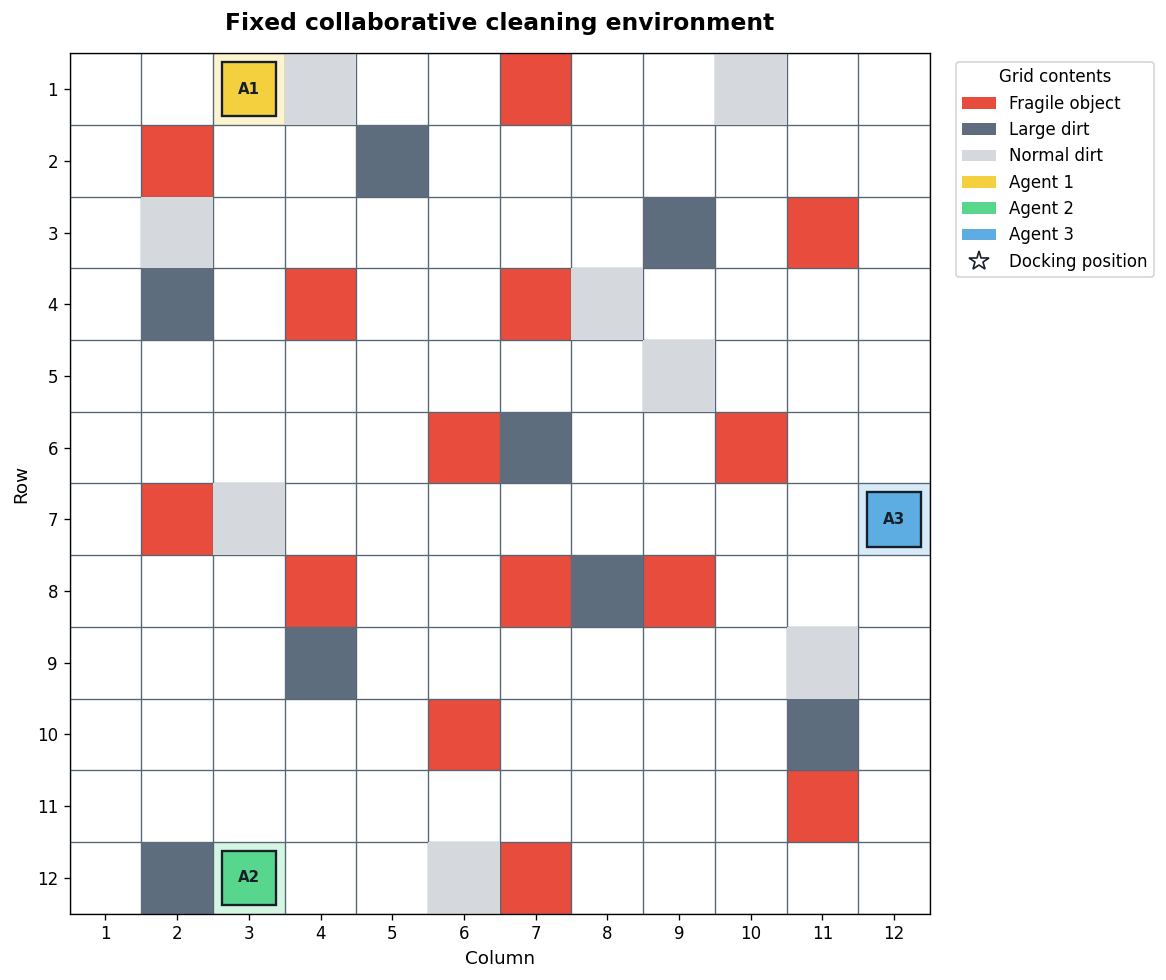

WindowsPath('assignment2_artifacts/figures/task_1_fixed_environment.png')

In [231]:
fixed_environment = CleaningGridEnv('fixed', seed=SEED)
fixed_observations, fixed_info = fixed_environment.reset()

print('Local observations:', fixed_observations.shape)
print('Global state:', fixed_environment.get_global_state().shape)
print('Initial info:', fixed_info)

figure, _ = fixed_environment.render('Fixed collaborative cleaning environment')
save_and_show(figure, 'task_1_fixed_environment')

In [232]:
assert fixed_observations.shape == (3, 12, 12, 5)
assert fixed_environment.get_global_state().shape == (3, 12, 12, 5)
assert len(fixed_environment.normal_dirt) == 8
assert len(fixed_environment.large_dirt) == 8

for agent_id in range(NUM_AGENTS):
    observation = fixed_observations[agent_id]
    assert observation[:, :, 0].sum() == 14
    assert observation[:, :, 1].sum() == 1
    assert observation[:, :, 2].sum() == 2
    assert observation[:, :, 3].sum() == 3
    assert observation[:, :, 4].sum() == 1

random_environment = CleaningGridEnv('random', seed=SEED + 1)
random_observations, _ = random_environment.reset()

unavailable = set(START_POSITIONS) | set(FRAGILE_POSITIONS)
assert not (random_environment.normal_dirt & unavailable)
assert not (random_environment.large_dirt & unavailable)
assert not (random_environment.normal_dirt & random_environment.large_dirt)

print('All layout and observation assertions passed.')

All layout and observation assertions passed.


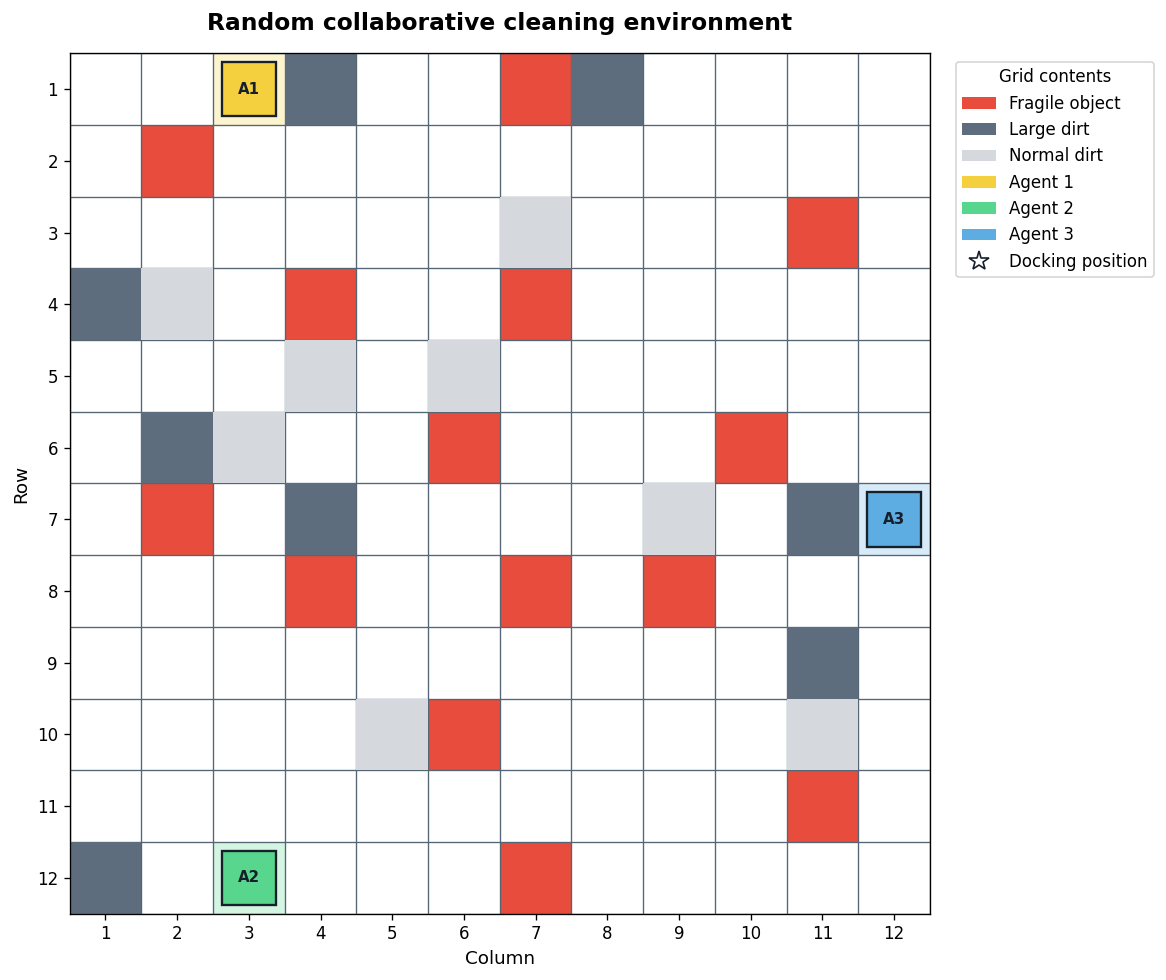

WindowsPath('assignment2_artifacts/figures/task_1_random_environment.png')

In [233]:
random_figure, _ = random_environment.render(
    "Random collaborative cleaning environment"
)
save_and_show(
    random_figure,
    "task_1_random_environment",
)

### Agent 1 local-observation channels

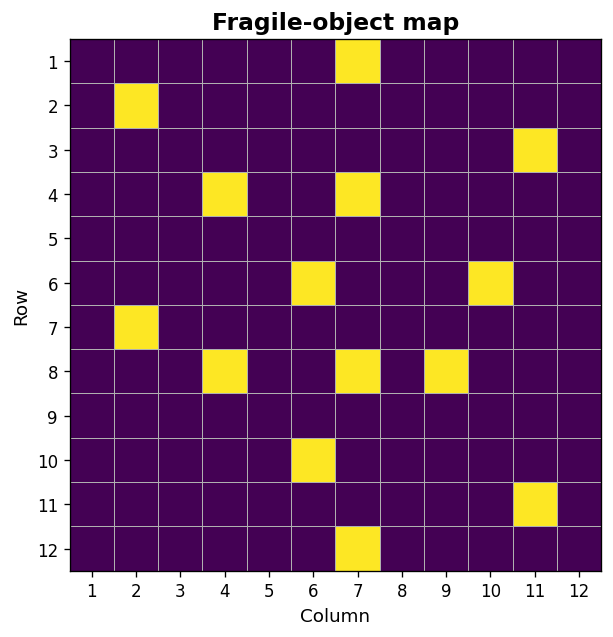

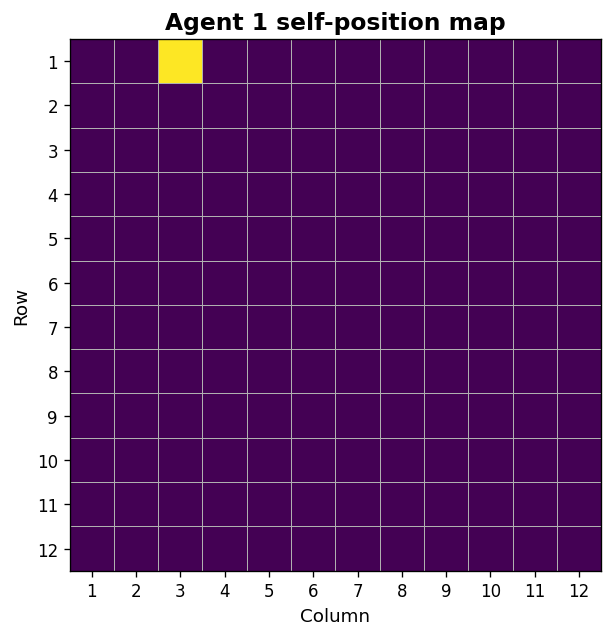

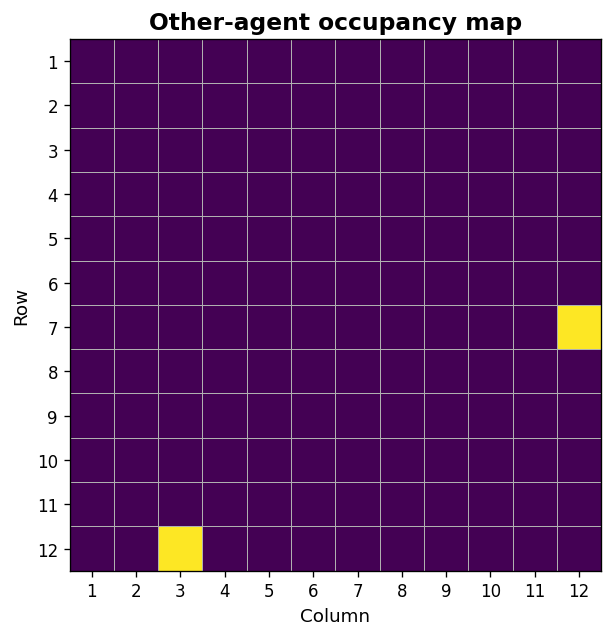

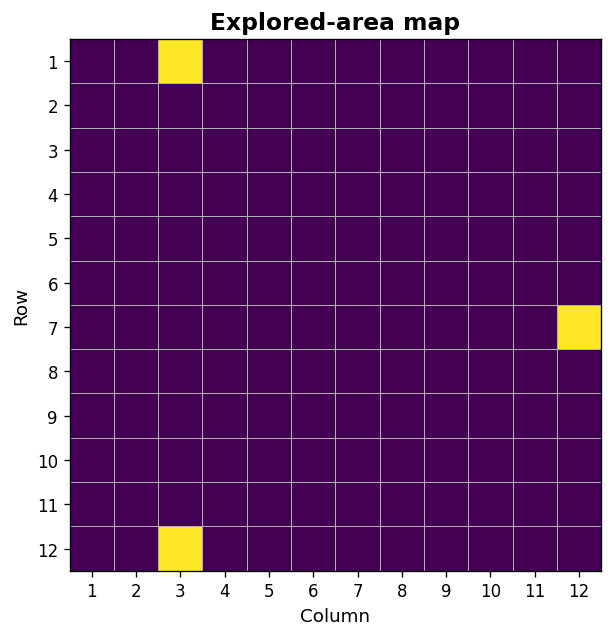

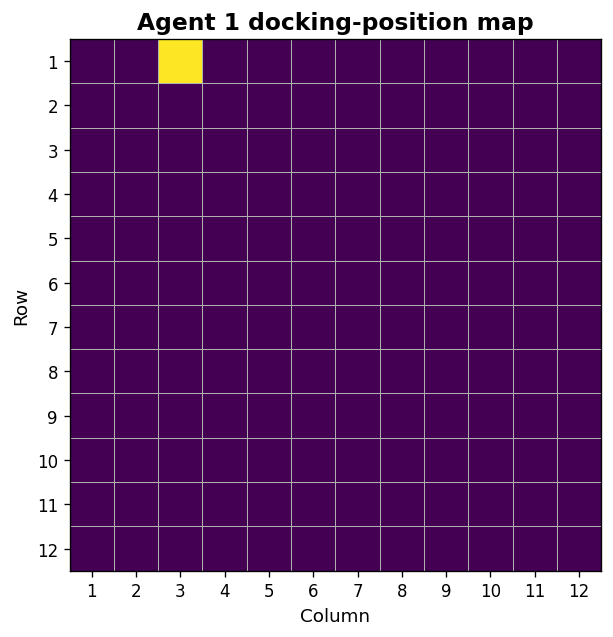

In [234]:
channel_names = [
    "Fragile-object map",
    "Agent 1 self-position map",
    "Other-agent occupancy map",
    "Explored-area map",
    "Agent 1 docking-position map",
]

for channel_index, channel_name in enumerate(
    channel_names
):
    figure, axis = plt.subplots(
        figsize=(5.8, 5.2),
        constrained_layout=True,
    )

    axis.imshow(
        fixed_observations[
            0,
            :,
            :,
            channel_index,
        ],
        origin="upper",
        vmin=0,
        vmax=1,
        interpolation="nearest",
    )

    axis.set_xticks(range(GRID_SIZE))
    axis.set_yticks(range(GRID_SIZE))
    axis.set_xticklabels(
        range(1, GRID_SIZE + 1)
    )
    axis.set_yticklabels(
        range(1, GRID_SIZE + 1)
    )
    axis.set_xlabel("Column")
    axis.set_ylabel("Row")
    axis.set_title(channel_name)

    axis.set_xticks(
        np.arange(-0.5, GRID_SIZE, 1),
        minor=True,
    )
    axis.set_yticks(
        np.arange(-0.5, GRID_SIZE, 1),
        minor=True,
    )
    axis.grid(
        which="minor",
        linewidth=0.6,
    )
    axis.tick_params(
        which="minor",
        bottom=False,
        left=False,
    )

    save_and_show(
        figure,
        (
            "task_1_agent_1_channel_"
            f"{channel_index + 1}"
        ),
    )

<a id="t-1-3"></a>

## <a id="t-1-3">1.3: Demonstration Script</a>

In [235]:
demo_environment = CleaningGridEnv(
    'fixed', seed=SEED + 2, truncate_on_safety_violation=False
)
demo_observations, _ = demo_environment.reset()

demo_rows = []
for step_index in range(8):
    actions = demo_environment.rng.integers(0, ACTION_DIMENSION, size=NUM_AGENTS)
    demo_observations, rewards, terminated, truncated, info = (
        demo_environment.step(actions)
    )
    demo_rows.append({
        'Step': step_index + 1,
        'Actions': actions.tolist(),
        'Rewards': np.round(rewards, 2).tolist(),
        'Positions': info['agent_positions'],
        'Violations': info['violation_reasons'],
        'Cleaning fraction': round(info['weighted_cleaning_fraction'], 3),
    })
    if terminated or truncated:
        break

display(pd.DataFrame(demo_rows))

,Step,Actions,Rewards,Positions,Violations,Cleaning fraction
0,1,"[3, 0, 4]","[1.899999976158142, -1.2000000476837158, -21.1...","[(0, 1), (11, 2), (6, 11)]",{2: 'boundary'},0.000
1,2,"[1, 3, 2]","[-21.100000381469727, 5.900000095367432, 1.899...","[(0, 1), (11, 1), (7, 11)]",{0: 'boundary'},0.083
2,3,"[0, 4, 2]","[-1.2000000476837158, -1.100000023841858, 1.89...","[(0, 1), (11, 2), (8, 11)]",{},0.083
3,4,"[0, 4, 4]","[-1.2000000476837158, 1.899999976158142, -21.1...","[(0, 1), (11, 3), (8, 11)]",{2: 'boundary'},0.083
4,5,"[0, 0, 0]","[-1.2000000476837158, -1.2000000476837158, -1....","[(0, 1), (11, 3), (8, 11)]",{},0.083
5,6,"[1, 2, 3]","[-21.100000381469727, -21.100000381469727, 3.9...","[(0, 1), (11, 3), (8, 10)]","{0: 'boundary', 1: 'boundary'}",0.125
6,7,"[3, 3, 2]","[1.899999976158142, -1.100000023841858, 5.9000...","[(0, 0), (11, 2), (9, 10)]",{},0.208
7,8,"[4, 1, 2]","[-1.100000023841858, 1.899999976158142, -21.10...","[(0, 1), (10, 2), (9, 10)]",{2: 'fragile_object'},0.208


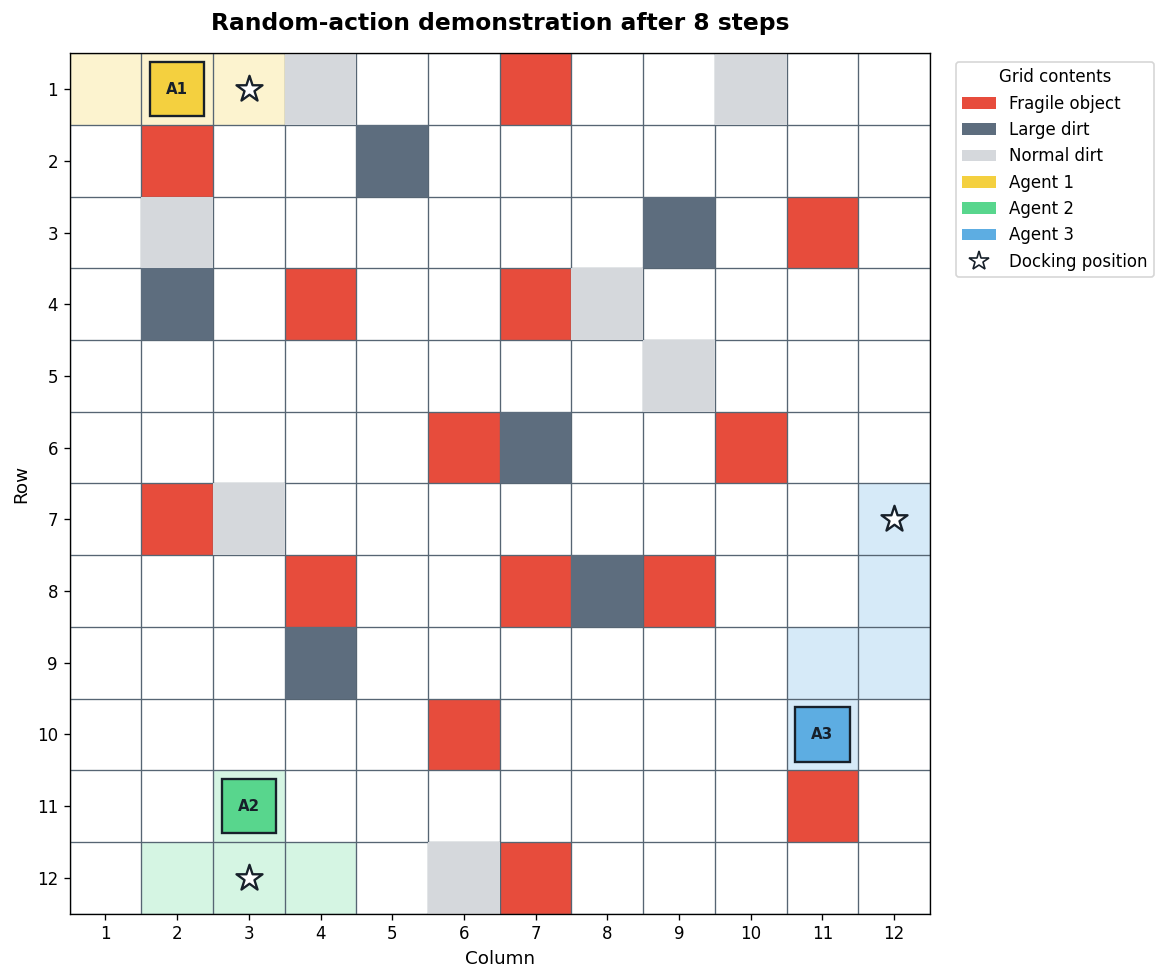

WindowsPath('assignment2_artifacts/figures/task_1_random_action_demo_final_state.png')

In [236]:
np.savez_compressed(
    DATA_DIR
    / "task_1_random_action_demo.npz",
    final_observations=demo_observations,
    visit_map=demo_environment.visit_map,
    revisit_map=demo_environment.revisit_map,
)

demo_figure, _ = demo_environment.render(
    (
        "Random-action demonstration after "
        f"{len(demo_rows)} steps"
    )
)
save_and_show(
    demo_figure,
    "task_1_random_action_demo_final_state",
)

<a id="t-1-4"></a>

## <a id="t-1-4">1.4: Collision Verification</a>

In [237]:
# Agent 1 moves right onto a new normal-dirt cell.
reward_environment = CleaningGridEnv(
    'fixed', seed=1, truncate_on_safety_violation=False
)
reward_environment.reset()
_, rewards, _, _, reward_info = reward_environment.step([
    Action.RIGHT, Action.IDLE, Action.IDLE
])

print('Stacked reward test:', rewards)
print('Agent 1 events:', reward_info['reward_events'][0])
assert np.isclose(rewards[0], 3.9, atol=1e-5)

# Boundary violation must be shielded, penalised, and truncated.
boundary_environment = CleaningGridEnv('fixed', seed=2)
boundary_environment.reset()
_, rewards, terminated, truncated, boundary_info = boundary_environment.step([
    Action.UP, Action.IDLE, Action.IDLE
])

assert not terminated
assert truncated
assert boundary_info['violation_reasons'][0] == 'boundary'
assert boundary_environment.agent_positions[0] == START_POSITIONS[0]
assert rewards[0] <= -20.0

# Fragile-object test: move left, then down into (2,2) in assignment coordinates.
fragile_environment = CleaningGridEnv(
    'fixed', seed=3, truncate_on_safety_violation=False
)
fragile_environment.reset()
fragile_environment.step([Action.LEFT, Action.IDLE, Action.IDLE])
fragile_environment.truncate_on_safety_violation = True
_, _, _, truncated, fragile_info = fragile_environment.step([
    Action.DOWN, Action.IDLE, Action.IDLE
])

assert truncated
assert fragile_info['violation_reasons'][0] == 'fragile_object'

print('Reward and safety verification passed.')

Stacked reward test: [ 3.9 -1.2 -1.2]
Agent 1 events: [('time_step', -0.1), ('new_cell', 2.0), ('normal_dirt', 2.0)]
Reward and safety verification passed.


In [238]:
# Same-target robot collision.
robot_environment = CleaningGridEnv(
    "fixed",
    seed=4,
)
robot_environment.reset()
robot_environment.agent_positions = [
    (4, 4),
    (4, 6),
    (6, 11),
]

(
    _,
    robot_rewards,
    robot_terminated,
    robot_truncated,
    robot_info,
) = robot_environment.step([
    Action.RIGHT,
    Action.LEFT,
    Action.IDLE,
])

assert not robot_terminated
assert robot_truncated
assert (
    robot_info["violation_reasons"][0]
    == "robot_collision"
)
assert (
    robot_info["violation_reasons"][1]
    == "robot_collision"
)

# Fifty-step time-limit truncation.
time_environment = CleaningGridEnv(
    "fixed",
    seed=5,
    truncate_on_safety_violation=False,
)
time_environment.reset()
time_environment.step_count = (
    MAX_EPISODE_STEPS - 1
)

(
    _,
    _,
    time_terminated,
    time_truncated,
    time_info,
) = time_environment.step([
    Action.IDLE,
    Action.IDLE,
    Action.IDLE,
])

assert not time_terminated
assert time_truncated
assert (
    time_info["step"]
    == MAX_EPISODE_STEPS
)

display(pd.DataFrame([
    {
        "Verification": "Cumulative reward",
        "Status": "Passed",
    },
    {
        "Verification": "Boundary shielding",
        "Status": "Passed",
    },
    {
        "Verification": "Fragile-object shielding",
        "Status": "Passed",
    },
    {
        "Verification": "Robot collision",
        "Status": "Passed",
    },
    {
        "Verification": "Time-limit truncation",
        "Status": "Passed",
    },
]))

,Verification,Status
0,Cumulative reward,Passed
1,Boundary shielding,Passed
2,Fragile-object shielding,Passed
3,Robot collision,Passed
4,Time-limit truncation,Passed


# <a id="task-2">Task 2: Modular PPO Pipeline Construction</a>

<a id="task-2-navigation"></a>

> **Task 2 Navigation**

- [Back to Contents](#top)



- [2.1: PPO Actor and Critic](#t-2-1)
- [2.2: Rollout Buffer Module](#t-2-2)
- [2.3: Advantage Estimator Module](#t-2-3)
- [2.4: Optimizer Module](#t-2-4)

<a id="t-2-1"></a>

## <a id="t-2-1">2.1: PPO Actor and Critic</a>

In [239]:
def build_mlp(
    input_dimension: int,
    hidden_dimensions: Sequence[int],
    output_dimension: int,
) -> nn.Sequential:
    layers: List[nn.Module] = []
    previous_dimension = input_dimension

    for hidden_dimension in hidden_dimensions:
        layers.extend([
            nn.Linear(previous_dimension, hidden_dimension),
            nn.Tanh(),
        ])
        previous_dimension = hidden_dimension

    layers.append(nn.Linear(previous_dimension, output_dimension))
    return nn.Sequential(*layers)


class ActorNetwork(nn.Module):
    def __init__(
        self,
        observation_dimension: int = LOCAL_OBSERVATION_DIMENSION,
        hidden_dimensions: Sequence[int] = (128, 128),
        agent_id_dimension: int = 0,
    ) -> None:
        super().__init__()
        self.agent_id_dimension = agent_id_dimension
        self.network = build_mlp(
            observation_dimension + agent_id_dimension,
            hidden_dimensions,
            ACTION_DIMENSION,
        )

    def forward(
        self,
        observations: torch.Tensor,
        agent_ids: Optional[torch.Tensor] = None,
    ) -> torch.Tensor:
        flattened = observations.reshape(observations.shape[0], -1)
        if self.agent_id_dimension:
            if agent_ids is None:
                raise ValueError('agent_ids are required for the shared actor.')
            flattened = torch.cat([flattened, agent_ids], dim=-1)
        return self.network(flattened)

    def distribution(
        self,
        observations: torch.Tensor,
        agent_ids: Optional[torch.Tensor] = None,
    ) -> Categorical:
        return Categorical(logits=self.forward(observations, agent_ids))


class CriticNetwork(nn.Module):
    def __init__(
        self,
        input_dimension: int,
        output_dimension: int,
        hidden_dimensions: Sequence[int] = (128, 128),
    ) -> None:
        super().__init__()
        self.network = build_mlp(
            input_dimension,
            hidden_dimensions,
            output_dimension,
        )

    def forward(self, states: torch.Tensor) -> torch.Tensor:
        flattened = states.reshape(states.shape[0], -1)
        return self.network(flattened)


def trainable_parameter_count(model: nn.Module) -> int:
    return sum(
        parameter.numel()
        for parameter in model.parameters()
        if parameter.requires_grad
    )

In [240]:
TASK2_CONFIG = PPOConfig(
    gamma=PPO_CONFIG.gamma,
    gae_lambda=PPO_CONFIG.gae_lambda,
    clip_epsilon=PPO_CONFIG.clip_epsilon,
    actor_learning_rate=(
        PPO_CONFIG.actor_learning_rate
    ),
    critic_learning_rate=(
        PPO_CONFIG.critic_learning_rate
    ),
    entropy_coefficient=(
        PPO_CONFIG.entropy_coefficient
    ),
    value_coefficient=(
        PPO_CONFIG.value_coefficient
    ),
    max_gradient_norm=(
        PPO_CONFIG.max_gradient_norm
    ),
    rollout_length=200,
    minibatch_size=100,
    update_epochs=4,
    hidden_dimensions=(
        PPO_CONFIG.hidden_dimensions
    ),
    weight_decay=PPO_CONFIG.weight_decay,
)

task2_actors = nn.ModuleList([
    ActorNetwork(
        hidden_dimensions=(
            TASK2_CONFIG.hidden_dimensions
        )
    )
    for _ in range(NUM_AGENTS)
]).to(DEVICE)

task2_critics = nn.ModuleList([
    CriticNetwork(
        LOCAL_OBSERVATION_DIMENSION,
        1,
        TASK2_CONFIG.hidden_dimensions,
    )
    for _ in range(NUM_AGENTS)
]).to(DEVICE)

observation_tensor = torch.as_tensor(
    fixed_observations,
    dtype=torch.float32,
    device=DEVICE,
)

network_rows = []

with torch.no_grad():
    for agent_id in range(NUM_AGENTS):
        agent_observation = (
            observation_tensor[
                agent_id
            ].unsqueeze(0)
        )

        distribution = task2_actors[
            agent_id
        ].distribution(agent_observation)

        value = task2_critics[
            agent_id
        ](agent_observation).squeeze(-1)

        probabilities = (
            distribution.probs
            .squeeze(0)
            .cpu()
            .numpy()
        )

        assert np.isclose(
            probabilities.sum(),
            1.0,
        )
        assert value.shape == (1,)

        network_rows.append({
            "Agent": agent_id + 1,
            "Actor parameters": (
                trainable_parameter_count(
                    task2_actors[agent_id]
                )
            ),
            "Critic parameters": (
                trainable_parameter_count(
                    task2_critics[agent_id]
                )
            ),
            "Probability sum": float(
                probabilities.sum()
            ),
            "Initial value": float(
                value.item()
            ),
        })

display(pd.DataFrame(network_rows))

,Agent,Actor parameters,Critic parameters,Probability sum,Initial value
0,1,24293,24161,1.0,-0.044641
1,2,24293,24161,1.0,0.045853
2,3,24293,24161,1.0,-0.066903


<a id="t-2-2"></a>

## <a id="t-2-2">2.2: Rollout Buffer Module</a>

In [241]:
@dataclass
class RolloutBatch:
    observations: torch.Tensor
    global_states: torch.Tensor
    actions: torch.Tensor
    old_log_probabilities: torch.Tensor
    rewards: torch.Tensor
    values: torch.Tensor
    dones: torch.Tensor
    advantages: torch.Tensor
    returns: torch.Tensor
    episode_summaries: List[Dict] = field(default_factory=list)


def generalized_advantage_estimation(
    rewards: torch.Tensor,
    values: torch.Tensor,
    dones: torch.Tensor,
    final_values: torch.Tensor,
    gamma: float,
    gae_lambda: float,
) -> Tuple[torch.Tensor, torch.Tensor]:
    """Compute vectorized GAE for all agents."""
    time_steps, num_agents = rewards.shape
    advantages = torch.zeros_like(rewards)
    running_advantage = torch.zeros(num_agents, device=rewards.device)
    next_values = final_values

    for time_index in reversed(range(time_steps)):
        non_terminal = 1.0 - dones[time_index]
        temporal_difference = (
            rewards[time_index]
            + gamma * next_values * non_terminal
            - values[time_index]
        )
        running_advantage = (
            temporal_difference
            + gamma * gae_lambda * non_terminal * running_advantage
        )
        advantages[time_index] = running_advantage
        next_values = values[time_index]

    returns = advantages + values
    return advantages, returns

In [242]:
@dataclass
class OpenLoopRolloutBuffer:
    observations: List[np.ndarray] = (
        field(default_factory=list)
    )
    global_states: List[np.ndarray] = (
        field(default_factory=list)
    )
    actions: List[np.ndarray] = (
        field(default_factory=list)
    )
    log_probabilities: List[np.ndarray] = (
        field(default_factory=list)
    )
    rewards: List[np.ndarray] = (
        field(default_factory=list)
    )
    values: List[np.ndarray] = (
        field(default_factory=list)
    )
    dones: List[float] = (
        field(default_factory=list)
    )

    def add(
        self,
        observations: np.ndarray,
        global_state: np.ndarray,
        actions: np.ndarray,
        log_probabilities: np.ndarray,
        rewards: np.ndarray,
        values: np.ndarray,
        done: bool,
    ) -> None:
        self.observations.append(
            observations.copy()
        )
        self.global_states.append(
            global_state.copy()
        )
        self.actions.append(actions.copy())
        self.log_probabilities.append(
            log_probabilities.copy()
        )
        self.rewards.append(rewards.copy())
        self.values.append(values.copy())
        self.dones.append(float(done))

    def arrays(
        self,
    ) -> Dict[str, np.ndarray]:
        return {
            "observations": np.asarray(
                self.observations,
                dtype=np.float32,
            ),
            "global_states": np.asarray(
                self.global_states,
                dtype=np.float32,
            ),
            "actions": np.asarray(
                self.actions,
                dtype=np.int64,
            ),
            "log_probabilities": np.asarray(
                self.log_probabilities,
                dtype=np.float32,
            ),
            "rewards": np.asarray(
                self.rewards,
                dtype=np.float32,
            ),
            "values": np.asarray(
                self.values,
                dtype=np.float32,
            ),
            "dones": np.asarray(
                self.dones,
                dtype=np.float32,
            ),
        }


@torch.no_grad()
def task2_action_and_value(
    observations: np.ndarray,
):
    observation_tensor = torch.as_tensor(
        observations,
        dtype=torch.float32,
        device=DEVICE,
    )

    actions = []
    log_probabilities = []
    values = []

    for agent_id in range(NUM_AGENTS):
        agent_observation = (
            observation_tensor[
                agent_id
            ].unsqueeze(0)
        )

        distribution = task2_actors[
            agent_id
        ].distribution(agent_observation)

        action = distribution.sample()

        value = task2_critics[
            agent_id
        ](agent_observation).squeeze(-1)

        actions.append(action.item())
        log_probabilities.append(
            distribution.log_prob(
                action
            ).item()
        )
        values.append(value.item())

    return (
        np.asarray(
            actions,
            dtype=np.int64,
        ),
        np.asarray(
            log_probabilities,
            dtype=np.float32,
        ),
        np.asarray(
            values,
            dtype=np.float32,
        ),
    )


task2_environment = CleaningGridEnv(
    "fixed",
    seed=SEED + 100,
)
task2_observations, _ = (
    task2_environment.reset()
)
task2_buffer = OpenLoopRolloutBuffer()

for _ in range(
    TASK2_CONFIG.rollout_length
):
    global_state = (
        task2_environment
        .get_global_state()
    )

    (
        actions,
        log_probabilities,
        values,
    ) = task2_action_and_value(
        task2_observations
    )

    (
        next_observations,
        rewards,
        terminated,
        truncated,
        _,
    ) = task2_environment.step(actions)

    done = terminated or truncated

    task2_buffer.add(
        task2_observations,
        global_state,
        actions,
        log_probabilities,
        rewards,
        values,
        done,
    )

    task2_observations = (
        next_observations
    )

    if done:
        task2_observations, _ = (
            task2_environment.reset()
        )

if task2_buffer.dones[-1]:
    task2_final_values = np.zeros(
        NUM_AGENTS,
        dtype=np.float32,
    )
else:
    (
        _,
        _,
        task2_final_values,
    ) = task2_action_and_value(
        task2_observations
    )

task2_rollout = task2_buffer.arrays()

task2_rollout_path = (
    DATA_DIR
    / "task_2_open_loop_rollout.npz"
)

np.savez_compressed(
    task2_rollout_path,
    **task2_rollout,
    final_values=task2_final_values,
)

display(pd.DataFrame([
    {
        "Field": name,
        "Shape": str(value.shape),
        "Data type": str(value.dtype),
    }
    for name, value
    in task2_rollout.items()
]))

display(pd.DataFrame({
    "Time step": np.arange(5),
    "Actions": [
        row.tolist()
        for row
        in task2_rollout["actions"][:5]
    ],
    "Rewards": [
        np.round(row, 2).tolist()
        for row
        in task2_rollout["rewards"][:5]
    ],
    "Values": [
        np.round(row, 4).tolist()
        for row
        in task2_rollout["values"][:5]
    ],
    "Done": (
        task2_rollout["dones"][:5]
        .astype(bool)
    ),
}))

assert task2_rollout[
    "observations"
].shape == (
    TASK2_CONFIG.rollout_length,
    NUM_AGENTS,
    GRID_SIZE,
    GRID_SIZE,
    LOCAL_CHANNELS,
)

,Field,Shape,Data type
0,observations,"(200, 3, 12, 12, 5)",float32
1,global_states,"(200, 3, 12, 12, 5)",float32
2,actions,"(200, 3)",int64
3,log_probabilities,"(200, 3)",float32
4,rewards,"(200, 3)",float32
5,values,"(200, 3)",float32
6,dones,"(200,)",float32


,Time step,Actions,Rewards,Values,Done
0,0,"[1, 1, 2]","[-21.100000381469727, 1.899999976158142, 1.899...","[-0.044599998742341995, 0.045899998396635056, ...",True
1,1,"[0, 3, 4]","[-1.2000000476837158, 5.900000095367432, -21.1...","[-0.044599998742341995, 0.045899998396635056, ...",True
2,2,"[3, 4, 4]","[1.899999976158142, 1.899999976158142, -21.100...","[-0.044599998742341995, 0.045899998396635056, ...",True
3,3,"[1, 4, 1]","[-21.100000381469727, 1.899999976158142, 1.899...","[-0.044599998742341995, 0.045899998396635056, ...",True
4,4,"[2, 2, 2]","[1.899999976158142, -21.100000381469727, 1.899...","[-0.044599998742341995, 0.045899998396635056, ...",True


<a id="t-2-3"></a>

## <a id="t-2-3">2.3: Advantage Estimator Module</a>

,Agent,TD mean,TD variance,Advantage mean,Advantage variance,Return mean
0,1,-4.051239,89.467873,-8.980755,100.347076,-9.035810
1,2,-2.009139,66.779129,-4.287774,94.888756,-4.245744
2,3,-3.380826,75.429497,-6.270418,102.846786,-6.329165


,GAE lambda,Advantage variance,Mean absolute advantage,Return variance
0,0.00,77.691208,5.512740,77.774734
1,0.50,78.541054,6.407046,78.655891
2,0.95,102.735390,8.684251,102.892891
3,1.00,110.139709,9.105481,110.303879


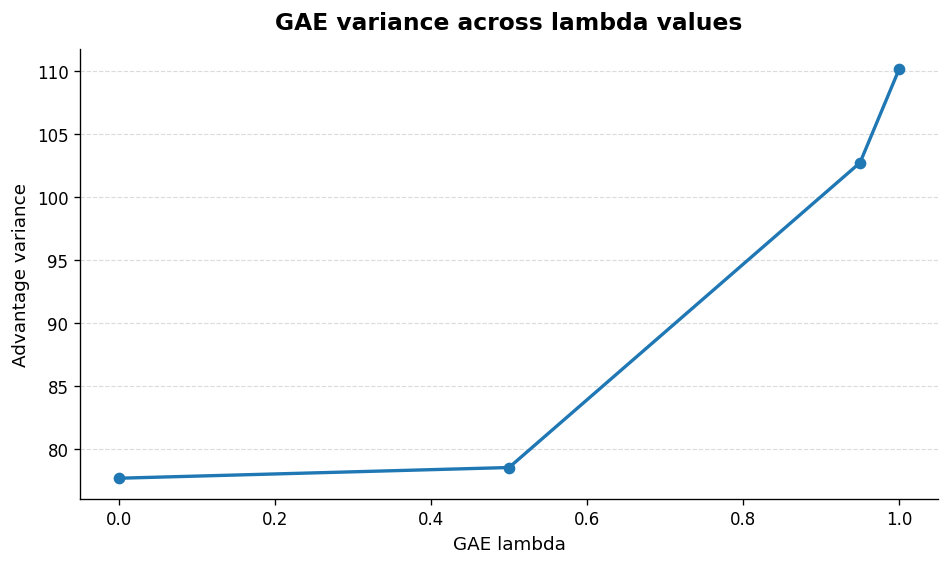

WindowsPath('assignment2_artifacts/figures/task_2_gae_variance.png')

In [243]:
saved_task2_rollout = np.load(
    task2_rollout_path,
    allow_pickle=False,
)

task2_rewards = torch.as_tensor(
    saved_task2_rollout["rewards"],
    dtype=torch.float32,
    device=DEVICE,
)
task2_values = torch.as_tensor(
    saved_task2_rollout["values"],
    dtype=torch.float32,
    device=DEVICE,
)
task2_dones = torch.as_tensor(
    saved_task2_rollout["dones"],
    dtype=torch.float32,
    device=DEVICE,
)
task2_final_values_tensor = (
    torch.as_tensor(
        saved_task2_rollout[
            "final_values"
        ],
        dtype=torch.float32,
        device=DEVICE,
    )
)

(
    task2_advantages,
    task2_returns,
) = generalized_advantage_estimation(
    rewards=task2_rewards,
    values=task2_values,
    dones=task2_dones,
    final_values=(
        task2_final_values_tensor
    ),
    gamma=TASK2_CONFIG.gamma,
    gae_lambda=(
        TASK2_CONFIG.gae_lambda
    ),
)

task2_td_errors = (
    task2_rewards
    + TASK2_CONFIG.gamma
    * torch.cat([
        task2_values[1:],
        task2_final_values_tensor
        .unsqueeze(0),
    ])
    * (
        1.0
        - task2_dones.unsqueeze(-1)
    )
    - task2_values
)

enriched_task2_path = (
    DATA_DIR
    / "task_2_rollout_with_gae.npz"
)

np.savez_compressed(
    enriched_task2_path,
    **{
        key: saved_task2_rollout[key]
        for key
        in saved_task2_rollout.files
    },
    td_errors=(
        task2_td_errors
        .cpu()
        .numpy()
    ),
    advantages=(
        task2_advantages
        .cpu()
        .numpy()
    ),
    returns=(
        task2_returns
        .cpu()
        .numpy()
    ),
)

display(pd.DataFrame([
    {
        "Agent": agent_id + 1,
        "TD mean": float(
            task2_td_errors[
                :,
                agent_id,
            ].mean().item()
        ),
        "TD variance": float(
            task2_td_errors[
                :,
                agent_id,
            ].var().item()
        ),
        "Advantage mean": float(
            task2_advantages[
                :,
                agent_id,
            ].mean().item()
        ),
        "Advantage variance": float(
            task2_advantages[
                :,
                agent_id,
            ].var().item()
        ),
        "Return mean": float(
            task2_returns[
                :,
                agent_id,
            ].mean().item()
        ),
    }
    for agent_id in range(
        NUM_AGENTS
    )
]))

lambda_rows = []

for lambda_value in (
    0.0,
    0.5,
    0.95,
    1.0,
):
    (
        lambda_advantages,
        lambda_returns,
    ) = generalized_advantage_estimation(
        rewards=task2_rewards,
        values=task2_values,
        dones=task2_dones,
        final_values=(
            task2_final_values_tensor
        ),
        gamma=TASK2_CONFIG.gamma,
        gae_lambda=lambda_value,
    )

    lambda_rows.append({
        "GAE lambda": lambda_value,
        "Advantage variance": float(
            lambda_advantages.var().item()
        ),
        "Mean absolute advantage": float(
            lambda_advantages
            .abs()
            .mean()
            .item()
        ),
        "Return variance": float(
            lambda_returns.var().item()
        ),
    })

lambda_table = pd.DataFrame(
    lambda_rows
)
display(lambda_table)

figure, axis = plt.subplots(
    figsize=(7.8, 4.6),
    constrained_layout=True,
)
axis.plot(
    lambda_table["GAE lambda"],
    lambda_table[
        "Advantage variance"
    ],
    marker="o",
    linewidth=2,
)
finish_axis(
    axis,
    "GAE variance across lambda values",
    "GAE lambda",
    "Advantage variance",
    False,
)
save_and_show(
    figure,
    "task_2_gae_variance",
)

<a id="t-2-4"></a>

## <a id="t-2-4">2.4: Optimizer Module</a>

In [244]:
def ppo_loss_terms(
    distribution: Categorical,
    actions: torch.Tensor,
    old_log_probabilities: torch.Tensor,
    advantages: torch.Tensor,
    predicted_values: torch.Tensor,
    returns: torch.Tensor,
    config: PPOConfig,
) -> Dict[str, torch.Tensor]:
    new_log_probabilities = distribution.log_prob(actions)
    probability_ratio = torch.exp(
        new_log_probabilities - old_log_probabilities
    )

    unclipped_objective = probability_ratio * advantages
    clipped_objective = torch.clamp(
        probability_ratio,
        1.0 - config.clip_epsilon,
        1.0 + config.clip_epsilon,
    ) * advantages

    actor_loss = -torch.min(
        unclipped_objective,
        clipped_objective,
    ).mean()
    critic_loss = F.mse_loss(predicted_values, returns)
    entropy = distribution.entropy().mean()
    total_loss = (
        actor_loss
        + config.value_coefficient * critic_loss
        - config.entropy_coefficient * entropy
    )

    return {
        'actor_loss': actor_loss,
        'critic_loss': critic_loss,
        'entropy': entropy,
        'total_loss': total_loss,
        'mean_probability_ratio': probability_ratio.mean(),
    }

,Agent,Actor loss,Critic loss,Entropy,Total loss,Mean probability ratio,Actor parameter change,Critic parameter change
0,1,-0.014166,177.577206,1.601266,88.758425,0.999138,0.002068,0.006705
1,2,-0.015110,111.172120,1.606728,55.554882,1.001547,0.002060,0.006645
2,3,-0.013944,139.305260,1.603090,69.622655,0.998821,0.002076,0.006705


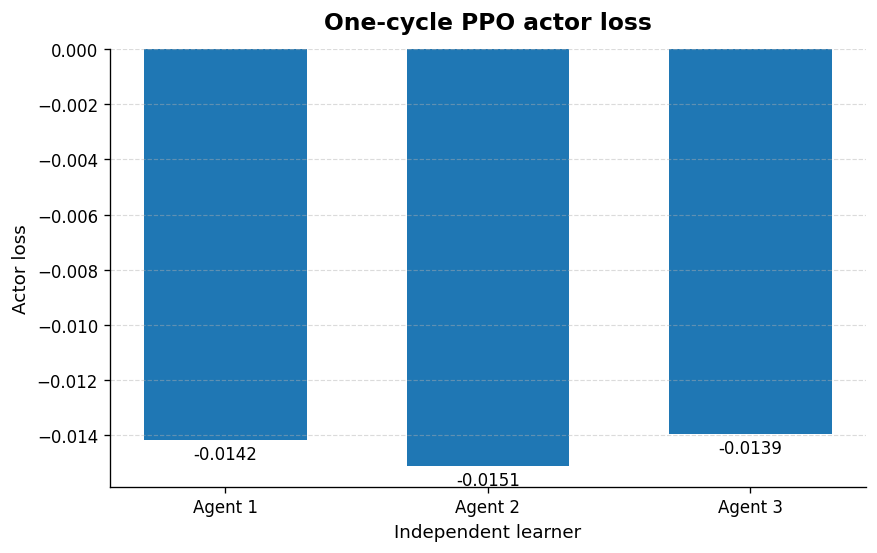

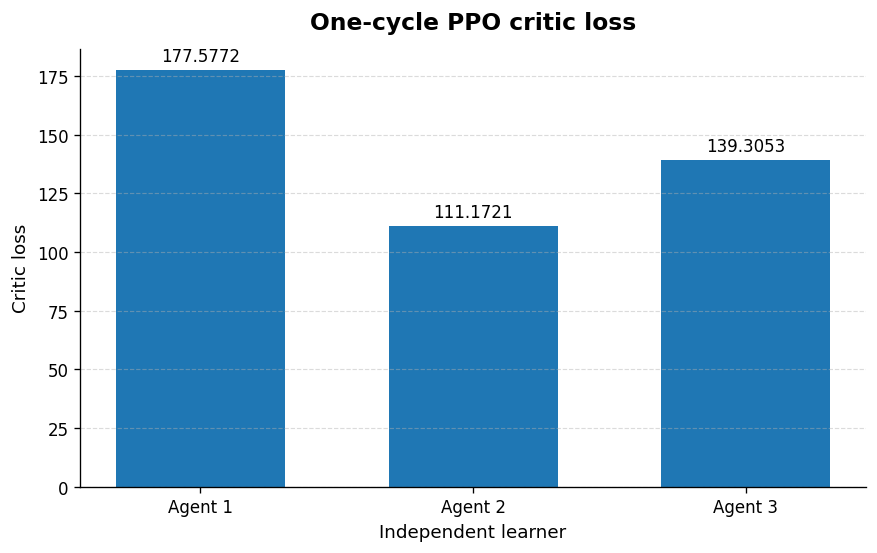

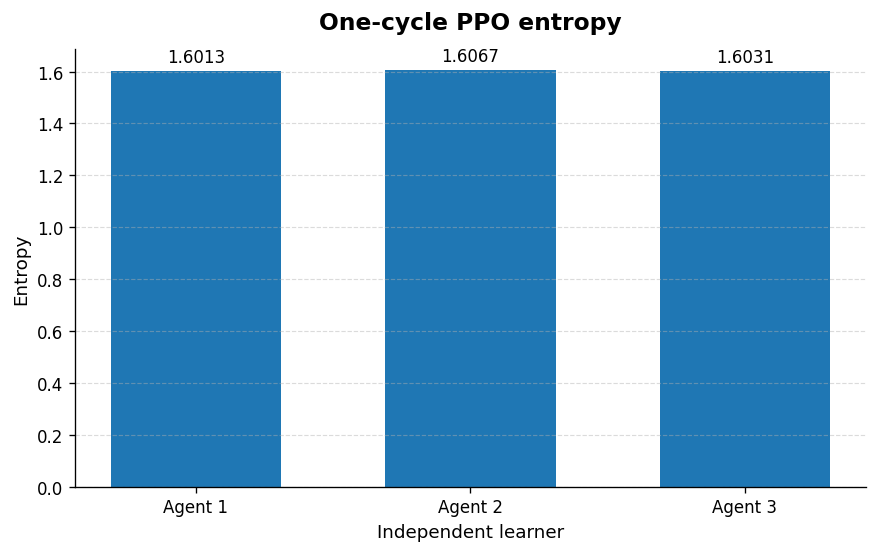

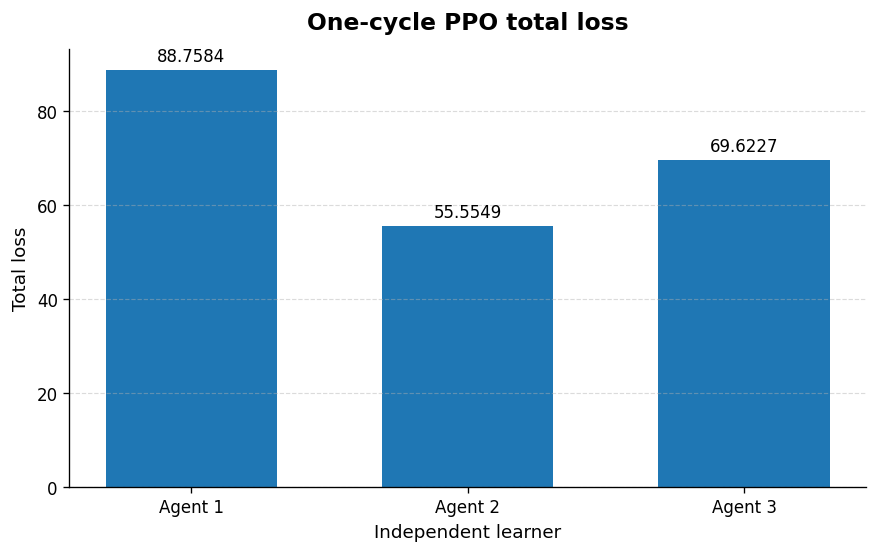

In [245]:
task2_observations_tensor = (
    torch.as_tensor(
        saved_task2_rollout[
            "observations"
        ],
        dtype=torch.float32,
        device=DEVICE,
    )
)
task2_actions_tensor = (
    torch.as_tensor(
        saved_task2_rollout[
            "actions"
        ],
        dtype=torch.long,
        device=DEVICE,
    )
)
task2_old_log_probabilities = (
    torch.as_tensor(
        saved_task2_rollout[
            "log_probabilities"
        ],
        dtype=torch.float32,
        device=DEVICE,
    )
)

task2_optimizer_rows = []

for agent_id in range(NUM_AGENTS):
    actor = task2_actors[agent_id]
    critic = task2_critics[agent_id]

    actor_optimizer = (
        torch.optim.Adam(
            actor.parameters(),
            lr=(
                TASK2_CONFIG
                .actor_learning_rate
            ),
            weight_decay=(
                TASK2_CONFIG
                .weight_decay
            ),
        )
    )
    critic_optimizer = (
        torch.optim.Adam(
            critic.parameters(),
            lr=(
                TASK2_CONFIG
                .critic_learning_rate
            ),
            weight_decay=(
                TASK2_CONFIG
                .weight_decay
            ),
        )
    )

    actor_before = (
        parameter_vector(actor)
    )
    critic_before = (
        parameter_vector(critic)
    )

    agent_advantages = (
        task2_advantages[
            :,
            agent_id,
        ]
    )
    agent_advantages = (
        agent_advantages
        - agent_advantages.mean()
    ) / (
        agent_advantages.std()
        + 1e-8
    )

    metric_values = {
        "actor_loss": [],
        "critic_loss": [],
        "entropy": [],
        "total_loss": [],
        "mean_probability_ratio": [],
    }

    for _ in range(
        TASK2_CONFIG.update_epochs
    ):
        permutation = torch.randperm(
            TASK2_CONFIG.rollout_length,
            device=DEVICE,
        )

        for start in range(
            0,
            TASK2_CONFIG.rollout_length,
            TASK2_CONFIG.minibatch_size,
        ):
            indices = permutation[
                start:
                start
                + TASK2_CONFIG.minibatch_size
            ]

            observations = (
                task2_observations_tensor[
                    indices,
                    agent_id,
                ]
            )
            actions = (
                task2_actions_tensor[
                    indices,
                    agent_id,
                ]
            )
            old_log_probabilities = (
                task2_old_log_probabilities[
                    indices,
                    agent_id,
                ]
            )
            advantages = (
                agent_advantages[indices]
            )
            returns = (
                task2_returns[
                    indices,
                    agent_id,
                ]
            )

            distribution = (
                actor.distribution(
                    observations
                )
            )
            predicted_values = (
                critic(
                    observations
                ).squeeze(-1)
            )

            loss_terms = ppo_loss_terms(
                distribution=distribution,
                actions=actions,
                old_log_probabilities=(
                    old_log_probabilities
                ),
                advantages=advantages,
                predicted_values=(
                    predicted_values
                ),
                returns=returns,
                config=TASK2_CONFIG,
            )

            actor_optimizer.zero_grad()
            critic_optimizer.zero_grad()

            loss_terms[
                "total_loss"
            ].backward()

            nn.utils.clip_grad_norm_(
                actor.parameters(),
                TASK2_CONFIG
                .max_gradient_norm,
            )
            nn.utils.clip_grad_norm_(
                critic.parameters(),
                TASK2_CONFIG
                .max_gradient_norm,
            )

            actor_optimizer.step()
            critic_optimizer.step()

            for metric_name in (
                "actor_loss",
                "critic_loss",
                "entropy",
                "total_loss",
                "mean_probability_ratio",
            ):
                metric_values[
                    metric_name
                ].append(
                    loss_terms[
                        metric_name
                    ].item()
                )

    actor_change = torch.mean(
        torch.abs(
            parameter_vector(actor)
            - actor_before
        )
    ).item()

    critic_change = torch.mean(
        torch.abs(
            parameter_vector(critic)
            - critic_before
        )
    ).item()

    task2_optimizer_rows.append({
        "Agent": agent_id + 1,
        "Actor loss": float(
            np.mean(
                metric_values[
                    "actor_loss"
                ]
            )
        ),
        "Critic loss": float(
            np.mean(
                metric_values[
                    "critic_loss"
                ]
            )
        ),
        "Entropy": float(
            np.mean(
                metric_values[
                    "entropy"
                ]
            )
        ),
        "Total loss": float(
            np.mean(
                metric_values[
                    "total_loss"
                ]
            )
        ),
        "Mean probability ratio": float(
            np.mean(
                metric_values[
                    "mean_probability_ratio"
                ]
            )
        ),
        "Actor parameter change": (
            actor_change
        ),
        "Critic parameter change": (
            critic_change
        ),
    })

task2_optimizer_table = (
    pd.DataFrame(
        task2_optimizer_rows
    )
)
display(
    task2_optimizer_table.style.format(
        precision=6
    )
)

assert (
    task2_optimizer_table[
        "Actor parameter change"
    ] > 0
).all()
assert (
    task2_optimizer_table[
        "Critic parameter change"
    ] > 0
).all()

np.savez_compressed(
    DATA_DIR
    / "task_2_optimizer_metrics.npz",
    **{
        column: (
            task2_optimizer_table[
                column
            ].to_numpy()
        )
        for column
        in task2_optimizer_table.columns
    },
)

for metric_name in (
    "Actor loss",
    "Critic loss",
    "Entropy",
    "Total loss",
):
    figure, axis = plt.subplots(
        figsize=(7.2, 4.5),
        constrained_layout=True,
    )

    bars = axis.bar(
        task2_optimizer_table[
            "Agent"
        ],
        task2_optimizer_table[
            metric_name
        ],
        width=0.62,
    )

    axis.set_xticks(
        task2_optimizer_table[
            "Agent"
        ]
    )
    axis.set_xticklabels([
        "Agent 1",
        "Agent 2",
        "Agent 3",
    ])
    axis.bar_label(
        bars,
        fmt="%.4f",
        padding=3,
    )

    finish_axis(
        axis,
        (
            "One-cycle PPO "
            f"{metric_name.lower()}"
        ),
        "Independent learner",
        metric_name,
        False,
    )
    save_and_show(
        figure,
        (
            "task_2_optimizer_"
            f"{metric_name}"
        ),
    )

# <a id="task-3">Task 3: Independent Proximal Policy Optimization</a>

<a id="task-3-navigation"></a>

> **Task 3 Navigation**

- [Back to Contents](#top)



- [3.1: Source](#t-3-1)
- [3.2: IPPO Training Results](#t-3-2)
- [3.3: IPPO Performance Evaluation](#t-3-3)
- [3.4: IPPO Visual Demonstration](#t-3-4)

<a id="t-3-1"></a>

## <a id="t-3-1">3.1: Source</a>

In [246]:
class IPPO:
    algorithm_name = 'IPPO'

    def __init__(
        self,
        config: PPOConfig = PPO_CONFIG,
        device: torch.device = DEVICE,
    ) -> None:
        self.config = config
        self.device = device

        self.actors = nn.ModuleList([
            ActorNetwork(
                hidden_dimensions=config.hidden_dimensions
            )
            for _ in range(NUM_AGENTS)
        ]).to(device)

        self.critics = nn.ModuleList([
            CriticNetwork(
                LOCAL_OBSERVATION_DIMENSION,
                1,
                config.hidden_dimensions,
            )
            for _ in range(NUM_AGENTS)
        ]).to(device)

        self.actor_optimizers = [
            torch.optim.Adam(
                actor.parameters(),
                lr=config.actor_learning_rate,
                weight_decay=config.weight_decay,
            )
            for actor in self.actors
        ]
        self.critic_optimizers = [
            torch.optim.Adam(
                critic.parameters(),
                lr=config.critic_learning_rate,
                weight_decay=config.weight_decay,
            )
            for critic in self.critics
        ]

    @torch.no_grad()
    def act(self, observations: np.ndarray, deterministic: bool = False):
        observation_tensor = torch.as_tensor(
            observations, dtype=torch.float32, device=self.device
        )

        actions, log_probabilities, values, probabilities = [], [], [], []
        for agent_id in range(NUM_AGENTS):
            agent_observation = observation_tensor[agent_id].unsqueeze(0)
            distribution = self.actors[agent_id].distribution(agent_observation)
            action = (
                torch.argmax(distribution.logits, dim=-1)
                if deterministic else distribution.sample()
            )
            value = self.critics[agent_id](agent_observation).squeeze(-1)

            actions.append(action.item())
            log_probabilities.append(distribution.log_prob(action).item())
            values.append(value.item())
            probabilities.append(distribution.probs.squeeze(0).cpu().numpy())

        return (
            np.asarray(actions, dtype=np.int64),
            np.asarray(log_probabilities, dtype=np.float32),
            np.asarray(values, dtype=np.float32),
            np.asarray(probabilities, dtype=np.float32),
        )

    @torch.no_grad()
    def values(self, observations: np.ndarray) -> np.ndarray:
        observation_tensor = torch.as_tensor(
            observations, dtype=torch.float32, device=self.device
        )
        return np.asarray([
            self.critics[agent_id](
                observation_tensor[agent_id].unsqueeze(0)
            ).item()
            for agent_id in range(NUM_AGENTS)
        ], dtype=np.float32)

    @torch.no_grad()
    def probe(self, observations: np.ndarray, global_state: np.ndarray):
        _, _, values, probabilities = self.act(observations, deterministic=True)
        return probabilities, values

    def collect_rollout(self, environment: CleaningGridEnv) -> RolloutBatch:
        observations, _ = environment.reset()

        stored_observations, stored_states = [], []
        stored_actions, stored_log_probabilities = [], []
        stored_rewards, stored_values, stored_dones = [], [], []
        episode_summaries: List[Dict] = []

        episode_returns = np.zeros(NUM_AGENTS, dtype=np.float32)
        episode_length = 0
        episode_had_violation = False

        for _ in range(self.config.rollout_length):
            global_state = environment.get_global_state()
            actions, log_probabilities, values, _ = self.act(observations)
            next_observations, rewards, terminated, truncated, info = (
                environment.step(actions)
            )
            done = terminated or truncated

            stored_observations.append(observations)
            stored_states.append(global_state)
            stored_actions.append(actions)
            stored_log_probabilities.append(log_probabilities)
            stored_rewards.append(rewards)
            stored_values.append(values)
            stored_dones.append(float(done))

            episode_returns += rewards
            episode_length += 1
            episode_had_violation |= bool(info['violation_agents'])
            observations = next_observations

            if done:
                episode_summaries.append({
                    'return_per_agent': episode_returns.copy(),
                    'team_return': float(episode_returns.sum()),
                    'length': episode_length,
                    'success': float(terminated),
                    'completion_rate': info['weighted_cleaning_fraction'],
                    'violation': float(episode_had_violation),
                })
                observations, _ = environment.reset()
                episode_returns.fill(0)
                episode_length = 0
                episode_had_violation = False

        final_values = self.values(observations)

        tensor_data = {
            'observations': torch.as_tensor(
                np.asarray(stored_observations),
                dtype=torch.float32, device=self.device,
            ),
            'global_states': torch.as_tensor(
                np.asarray(stored_states),
                dtype=torch.float32, device=self.device,
            ),
            'actions': torch.as_tensor(
                np.asarray(stored_actions),
                dtype=torch.long, device=self.device,
            ),
            'old_log_probabilities': torch.as_tensor(
                np.asarray(stored_log_probabilities),
                dtype=torch.float32, device=self.device,
            ),
            'rewards': torch.as_tensor(
                np.asarray(stored_rewards),
                dtype=torch.float32, device=self.device,
            ),
            'values': torch.as_tensor(
                np.asarray(stored_values),
                dtype=torch.float32, device=self.device,
            ),
            'dones': torch.as_tensor(
                np.asarray(stored_dones),
                dtype=torch.float32, device=self.device,
            ),
        }

        advantages, returns = generalized_advantage_estimation(
            tensor_data['rewards'],
            tensor_data['values'],
            tensor_data['dones'],
            torch.as_tensor(final_values, dtype=torch.float32, device=self.device),
            self.config.gamma,
            self.config.gae_lambda,
        )

        return RolloutBatch(
            advantages=advantages,
            returns=returns,
            episode_summaries=episode_summaries,
            **tensor_data,
        )

    def update(self, batch: RolloutBatch) -> List[Dict[str, float]]:
        time_steps = batch.actions.shape[0]
        metrics: List[Dict[str, float]] = []

        for agent_id in range(NUM_AGENTS):
            observations = batch.observations[:, agent_id]
            actions = batch.actions[:, agent_id]
            old_log_probabilities = batch.old_log_probabilities[:, agent_id]
            advantages = batch.advantages[:, agent_id]
            returns = batch.returns[:, agent_id]
            advantages = (
                advantages - advantages.mean()
            ) / (advantages.std() + 1e-8)

            totals = {
                'actor_loss': 0.0,
                'critic_loss': 0.0,
                'entropy': 0.0,
                'total_loss': 0.0,
                'probability_ratio': 0.0,
                'updates': 0,
            }

            for _ in range(self.config.update_epochs):
                permutation = torch.randperm(time_steps, device=self.device)
                for start in range(0, time_steps, self.config.minibatch_size):
                    indices = permutation[start:start + self.config.minibatch_size]
                    distribution = self.actors[agent_id].distribution(
                        observations[indices]
                    )
                    predicted_values = self.critics[agent_id](
                        observations[indices]
                    ).squeeze(-1)
                    losses = ppo_loss_terms(
                        distribution,
                        actions[indices],
                        old_log_probabilities[indices],
                        advantages[indices],
                        predicted_values,
                        returns[indices],
                        self.config,
                    )

                    actor_objective = (
                        losses['actor_loss']
                        - self.config.entropy_coefficient * losses['entropy']
                    )
                    critic_objective = (
                        self.config.value_coefficient * losses['critic_loss']
                    )

                    self.actor_optimizers[agent_id].zero_grad()
                    actor_objective.backward()
                    nn.utils.clip_grad_norm_(
                        self.actors[agent_id].parameters(),
                        self.config.max_gradient_norm,
                    )
                    self.actor_optimizers[agent_id].step()

                    self.critic_optimizers[agent_id].zero_grad()
                    critic_objective.backward()
                    nn.utils.clip_grad_norm_(
                        self.critics[agent_id].parameters(),
                        self.config.max_gradient_norm,
                    )
                    self.critic_optimizers[agent_id].step()

                    totals['actor_loss'] += losses['actor_loss'].item()
                    totals['critic_loss'] += losses['critic_loss'].item()
                    totals['entropy'] += losses['entropy'].item()
                    totals['total_loss'] += losses['total_loss'].item()
                    totals['probability_ratio'] += (
                        losses['mean_probability_ratio'].item()
                    )
                    totals['updates'] += 1

            count = max(1, totals.pop('updates'))
            metrics.append({key: value / count for key, value in totals.items()})

        return metrics

    def save(self, path: Path) -> None:
        torch.save({
            'algorithm': self.algorithm_name,
            'config': asdict(self.config),
            'actors': self.actors.state_dict(),
            'critics': self.critics.state_dict(),
        }, path)

    def load(self, path: Path) -> None:
        checkpoint = torch.load(path, map_location=self.device, weights_only=False)
        self.actors.load_state_dict(checkpoint['actors'])
        self.critics.load_state_dict(checkpoint['critics'])

In [247]:
ippo_sanity_model = IPPO()

ippo_architecture = pd.DataFrame([
    {
        'Component': 'All independent actors',
        'Count': 3,
        'Parameters': trainable_parameter_count(ippo_sanity_model.actors),
    },
    {
        'Component': 'All independent critics',
        'Count': 3,
        'Parameters': trainable_parameter_count(ippo_sanity_model.critics),
    },
])

display(ippo_architecture)
assert len(ippo_sanity_model.actors) == 3
assert len(ippo_sanity_model.critics) == 3

,Component,Count,Parameters
0,All independent actors,3,72879
1,All independent critics,3,72483


In [248]:
ippo_one_cycle_environment = CleaningGridEnv('fixed', seed=100)
ippo_one_cycle_batch = ippo_sanity_model.collect_rollout(
    ippo_one_cycle_environment
)
ippo_one_cycle_metrics = ippo_sanity_model.update(ippo_one_cycle_batch)

ippo_shapes = pd.DataFrame({
    'Field': [
        'observations', 'actions', 'old log probabilities',
        'rewards', 'values', 'advantages', 'returns',
    ],
    'Shape': [
        tuple(ippo_one_cycle_batch.observations.shape),
        tuple(ippo_one_cycle_batch.actions.shape),
        tuple(ippo_one_cycle_batch.old_log_probabilities.shape),
        tuple(ippo_one_cycle_batch.rewards.shape),
        tuple(ippo_one_cycle_batch.values.shape),
        tuple(ippo_one_cycle_batch.advantages.shape),
        tuple(ippo_one_cycle_batch.returns.shape),
    ],
})
display(ippo_shapes)
display(pd.DataFrame(ippo_one_cycle_metrics, index=['Agent 1', 'Agent 2', 'Agent 3']))

np.savez_compressed(
    DATA_DIR / 'task2_ippo_one_cycle_rollout.npz',
    observations=ippo_one_cycle_batch.observations.cpu().numpy(),
    actions=ippo_one_cycle_batch.actions.cpu().numpy(),
    log_probabilities=(
        ippo_one_cycle_batch.old_log_probabilities.cpu().numpy()
    ),
    rewards=ippo_one_cycle_batch.rewards.cpu().numpy(),
    values=ippo_one_cycle_batch.values.cpu().numpy(),
    advantages=ippo_one_cycle_batch.advantages.cpu().numpy(),
    returns=ippo_one_cycle_batch.returns.cpu().numpy(),
)

,Field,Shape
0,observations,"(32, 3, 12, 12, 5)"
1,actions,"(32, 3)"
2,old log probabilities,"(32, 3)"
3,rewards,"(32, 3)"
4,values,"(32, 3)"
5,advantages,"(32, 3)"
6,returns,"(32, 3)"


,actor_loss,critic_loss,entropy,total_loss,probability_ratio
Agent 1,-0.001712,168.466965,1.605051,84.215721,0.999303
Agent 2,-0.001949,117.110752,1.601451,58.537413,1.000665
Agent 3,-0.002820,104.224949,1.605918,52.093596,0.999568


### Shared training and evaluation functions

In [249]:
def model_episode(
    model,
    dirt_mode: str,
    seed: int,
    deterministic: bool = True,
) -> Dict:
    environment = CleaningGridEnv(dirt_mode, seed=seed)
    observations, _ = environment.reset(seed=seed)

    episode_return = np.zeros(NUM_AGENTS, dtype=np.float32)
    contribution = np.zeros(NUM_AGENTS, dtype=np.float32)
    action_counts = np.zeros((NUM_AGENTS, ACTION_DIMENSION), dtype=np.int32)
    final_info = None

    for step_index in range(MAX_EPISODE_STEPS):
        global_state = environment.get_global_state()
        if model.algorithm_name == 'MAPPO':
            actions, _, values, probabilities = model.act(
                observations, global_state, deterministic
            )
        else:
            actions, _, values, probabilities = model.act(
                observations, deterministic
            )

        next_observations, rewards, terminated, truncated, info = (
            environment.step(actions)
        )
        done = terminated or truncated

        if done:
            next_values = np.zeros(NUM_AGENTS, dtype=np.float32)
        elif model.algorithm_name == 'MAPPO':
            next_values = model.values(
                next_observations,
                environment.get_global_state(),
            )
        else:
            next_values = model.values(next_observations)

        contribution += (
            rewards
            + model.config.gamma * next_values
            - values
        )
        episode_return += rewards
        for agent_id, action in enumerate(actions):
            action_counts[agent_id, int(action)] += 1

        observations = next_observations
        final_info = info
        if done:
            break

    return {
        'return_per_agent': episode_return,
        'team_return': float(episode_return.sum()),
        'episode_length': step_index + 1,
        'full_success': float(final_info['all_dirt_cleaned']),
        'completion_rate': float(final_info['weighted_cleaning_fraction']),
        'safety_violation': float(bool(final_info['violation_agents'])),
        'termination_reason': final_info['termination_reason'],
        'global_rcr': float(final_info['global_rcr']),
        'rcr_map': environment.rcr_map(),
        'contribution': contribution,
        'action_counts': action_counts,
    }


def evaluate_model(model, dirt_mode: str, seeds: Sequence[int]) -> Dict:
    rows = [model_episode(model, dirt_mode, int(seed)) for seed in seeds]
    return {
        'return_per_agent': np.stack([row['return_per_agent'] for row in rows]),
        'team_return': np.asarray([row['team_return'] for row in rows]),
        'episode_length': np.asarray([row['episode_length'] for row in rows]),
        'full_success': np.asarray([row['full_success'] for row in rows]),
        'completion_rate': np.asarray([row['completion_rate'] for row in rows]),
        'safety_violation': np.asarray([row['safety_violation'] for row in rows]),
        'termination_reason': np.asarray([row['termination_reason'] for row in rows]),
        'global_rcr': np.asarray([row['global_rcr'] for row in rows]),
        'rcr_map': np.mean(np.stack([row['rcr_map'] for row in rows]), axis=0),
        'contribution': np.stack([row['contribution'] for row in rows]),
        'action_counts': np.stack([row['action_counts'] for row in rows]),
        'seeds': np.asarray(seeds),
    }


def evaluation_summary(label: str, evaluation: Dict) -> Dict:
    successful_lengths = evaluation['episode_length'][evaluation['full_success'] > 0]
    return {
        'Model': label,
        'Mean team return': evaluation['team_return'].mean(),
        'Agent 1 return': evaluation['return_per_agent'][:, 0].mean(),
        'Agent 2 return': evaluation['return_per_agent'][:, 1].mean(),
        'Agent 3 return': evaluation['return_per_agent'][:, 2].mean(),
        'Weighted completion': evaluation['completion_rate'].mean(),
        'Full success rate': evaluation['full_success'].mean(),
        'Successful length': (
            successful_lengths.mean() if len(successful_lengths) else np.nan
        ),
        'Violation rate': evaluation['safety_violation'].mean(),
        'Global RCR': evaluation['global_rcr'].mean(),
    }


def plot_agent_training_metric(history: Dict, metric: str, title: str) -> None:
    figure, axis = plt.subplots(figsize=(8.5, 4.8), constrained_layout=True)
    for agent_id in range(NUM_AGENTS):
        axis.plot(
            history['update'],
            history[metric][:, agent_id],
            linewidth=2,
            marker='o' if len(history['update']) <= 15 else None,
            markersize=4,
            label=f'Agent {agent_id + 1}',
        )
    finish_axis(
        axis, title, 'PPO update', metric.replace('_', ' ').title(), True
    )
    save_and_show(figure, title)


def plot_training_performance(history: Dict, title: str) -> None:
    figure, axis = plt.subplots(figsize=(8.5, 4.8), constrained_layout=True)
    updates = np.asarray(history['update'])
    values = np.asarray(history['mean_team_return'])
    raw_line, = axis.plot(updates, values, linewidth=1.2, alpha=0.45, label='Raw')
    window = max(1, min(20, len(values) // 8))
    axis.plot(
        updates,
        rolling_mean(values, window),
        linewidth=2.4,
        color=raw_line.get_color(),
        label=f'Rolling mean ({window})',
    )
    finish_axis(axis, title, 'PPO update', 'Mean completed-episode team return', True)
    save_and_show(figure, title)


def train_model(
    model,
    dirt_mode: str,
    run_name: str,
    updates: int,
    seed: int,
) -> Tuple[Dict, Path]:
    environment = CleaningGridEnv(dirt_mode, seed=seed)
    probe_environment = CleaningGridEnv(dirt_mode, seed=seed + 999)
    probe_observations, _ = probe_environment.reset(seed=seed + 999)
    probe_state = probe_environment.get_global_state()

    history = {
        'update': [],
        'actor_loss': [],
        'critic_loss': [],
        'entropy': [],
        'total_loss': [],
        'probability_ratio': [],
        'mean_team_return': [],
        'mean_completion_rate': [],
        'mean_violation_rate': [],
        'mean_episode_length': [],
        'policy_trace': [],
        'value_trace': [],
        'elapsed_seconds': [],
    }

    best_score = -float('inf')
    best_path = CHECKPOINT_DIR / f'{run_name}_best.pt'
    start_time = time.perf_counter()

    iterator = trange(updates, desc=run_name) if updates > 1 else range(updates)
    for update_index in iterator:
        batch = model.collect_rollout(environment)
        metrics = model.update(batch)

        if batch.episode_summaries:
            team_returns = [row['team_return'] for row in batch.episode_summaries]
            completion_rates = [row['completion_rate'] for row in batch.episode_summaries]
            violation_rates = [row['violation'] for row in batch.episode_summaries]
            lengths = [row['length'] for row in batch.episode_summaries]
        else:
            team_returns = [batch.rewards.sum(dim=1).mean().item()]
            completion_rates = [0.0]
            violation_rates = [0.0]
            lengths = [PPO_CONFIG.rollout_length]

        probabilities, values = model.probe(probe_observations, probe_state)

        history['update'].append(update_index + 1)
        history['actor_loss'].append([row['actor_loss'] for row in metrics])
        history['critic_loss'].append([row['critic_loss'] for row in metrics])
        history['entropy'].append([row['entropy'] for row in metrics])
        history['total_loss'].append([row['total_loss'] for row in metrics])
        history['probability_ratio'].append([
            row.get('probability_ratio', 1.0) for row in metrics
        ])
        history['mean_team_return'].append(float(np.mean(team_returns)))
        history['mean_completion_rate'].append(float(np.mean(completion_rates)))
        history['mean_violation_rate'].append(float(np.mean(violation_rates)))
        history['mean_episode_length'].append(float(np.mean(lengths)))
        history['policy_trace'].append(probabilities)
        history['value_trace'].append(values)
        history['elapsed_seconds'].append(time.perf_counter() - start_time)

        checkpoint_score = (
            100.0 * np.mean(completion_rates)
            + np.mean(team_returns)
            - 20.0 * np.mean(violation_rates)
        )
        if checkpoint_score > best_score:
            best_score = checkpoint_score
            model.save(best_path)

    for key in history:
        history[key] = np.asarray(history[key])

    np.savez_compressed(
        DATA_DIR / f'{run_name}_training_metrics.npz',
        **history,
    )

    model.load(best_path)
    return history, best_path

<a id="t-3-2"></a>

## <a id="t-3-2">3.2: IPPO Training Results</a>

In [250]:
trained_models: Dict[str, object] = {}
training_histories: Dict[str, Dict] = {}
checkpoints: Dict[str, Path] = {}

if RUN_TRAINING:
    for mode_index, dirt_mode in enumerate(
        ("fixed", "random")
    ):
        run_name = f"ippo_{dirt_mode}"

        set_global_seed(
            MODEL_INITIALIZATION_SEED
        )

        model = IPPO()

        history, checkpoint = train_model(
            model,
            dirt_mode,
            run_name,
            EXPERIMENT_CONFIG
            .training_updates,
            SEED + 100 * mode_index,
        )

        trained_models[
            run_name
        ] = model
        training_histories[
            run_name
        ] = history
        checkpoints[
            run_name
        ] = checkpoint

display(pd.DataFrame([
    {
        "Run": run_name,
        "Updates": int(
            history["update"][-1]
        ),
        "Final team return": float(
            history[
                "mean_team_return"
            ][-1]
        ),
        "Final cleaning rate": float(
            history[
                "mean_completion_rate"
            ][-1]
        ),
        "Final violation rate": float(
            history[
                "mean_violation_rate"
            ][-1]
        ),
    }
    for run_name, history
    in training_histories.items()
    if run_name.startswith("ippo")
]).round(4))

,Run,Updates,Final team return,Final cleaning rate,Final violation rate
0,ippo_fixed,1,-19.0333,0.0312,1.0
1,ippo_random,1,-19.3667,0.0243,1.0


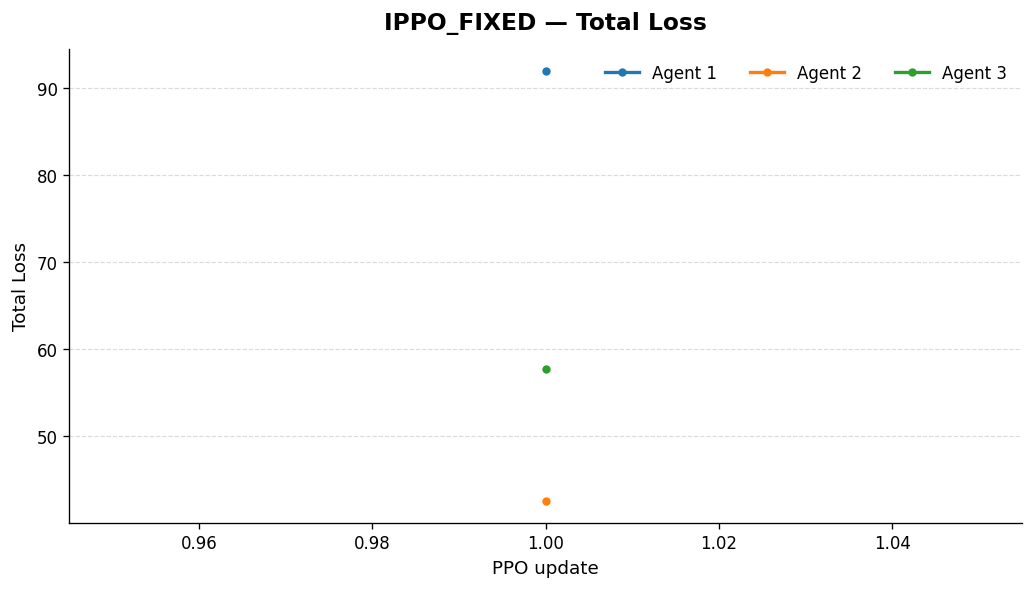

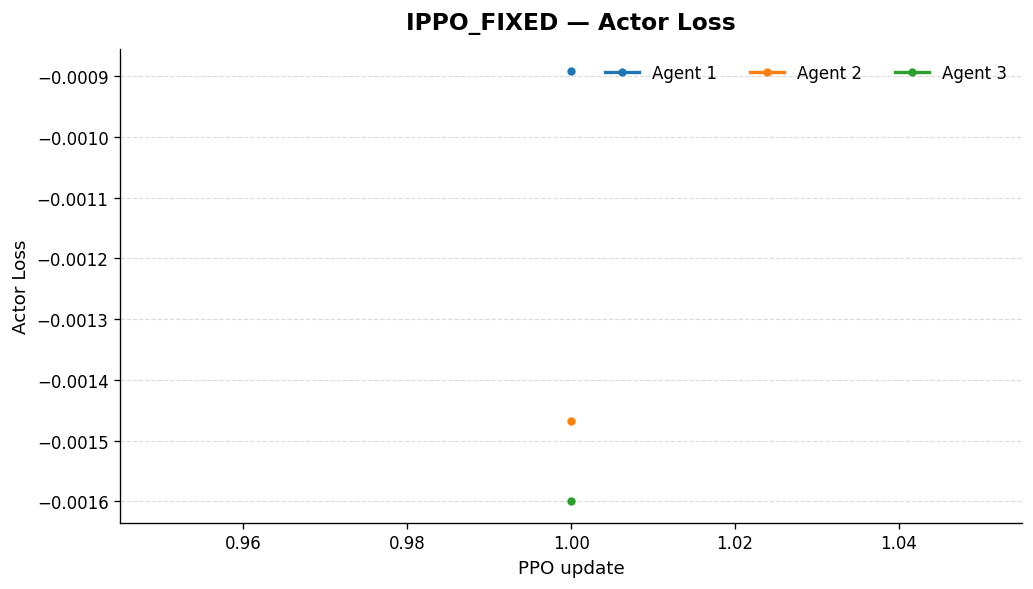

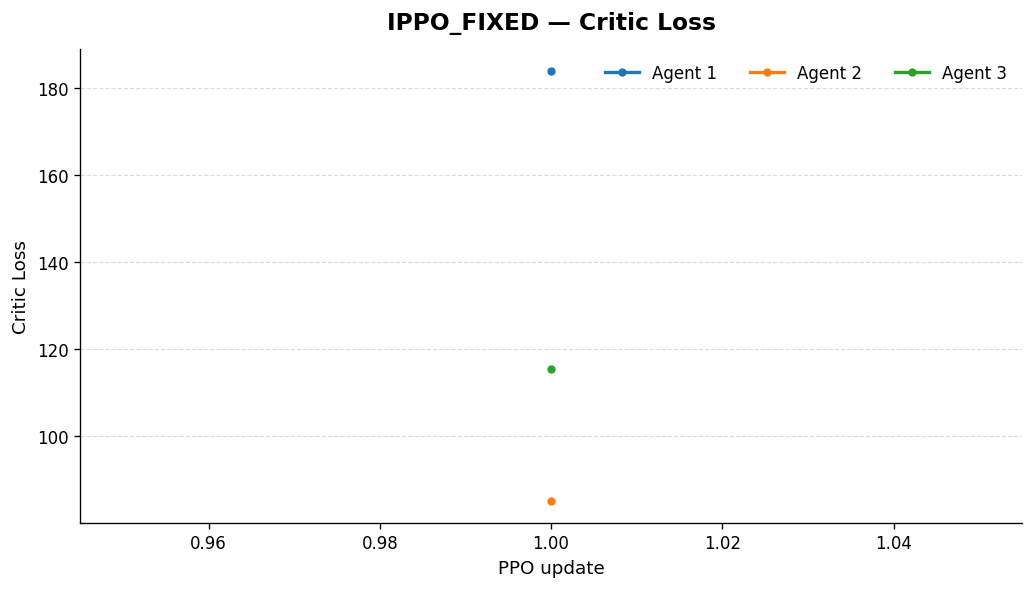

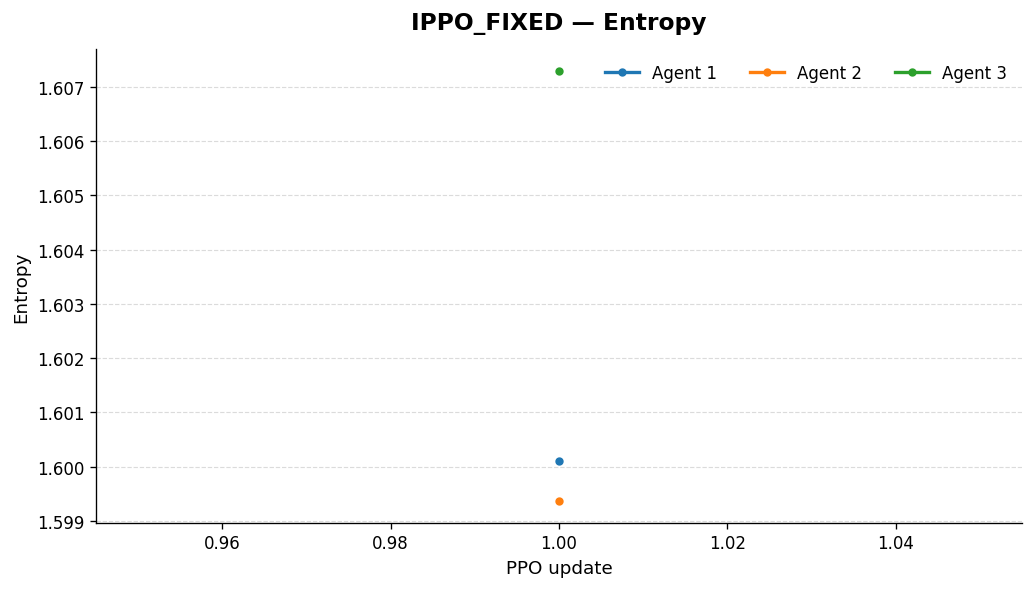

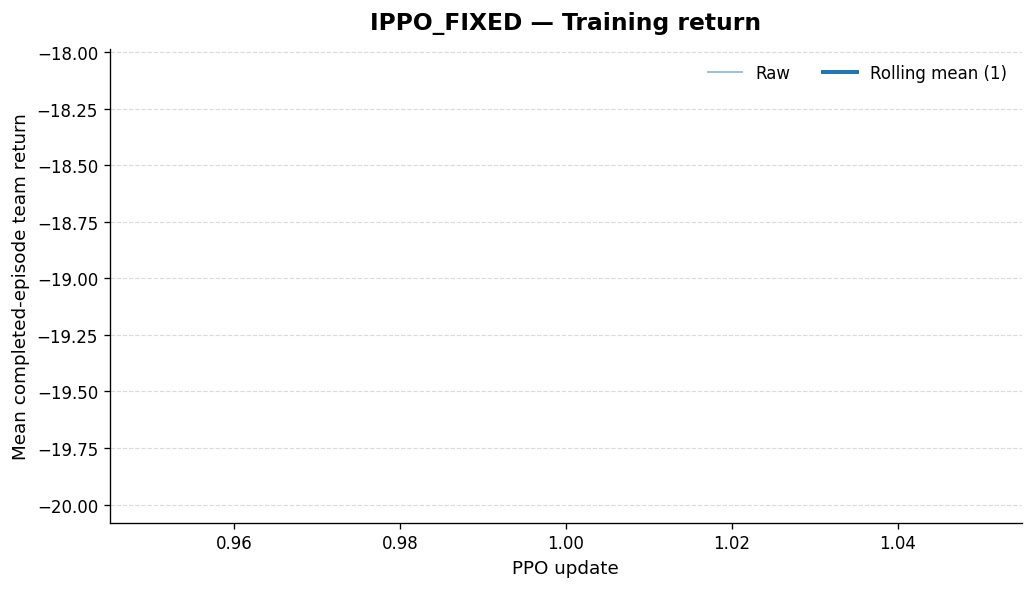

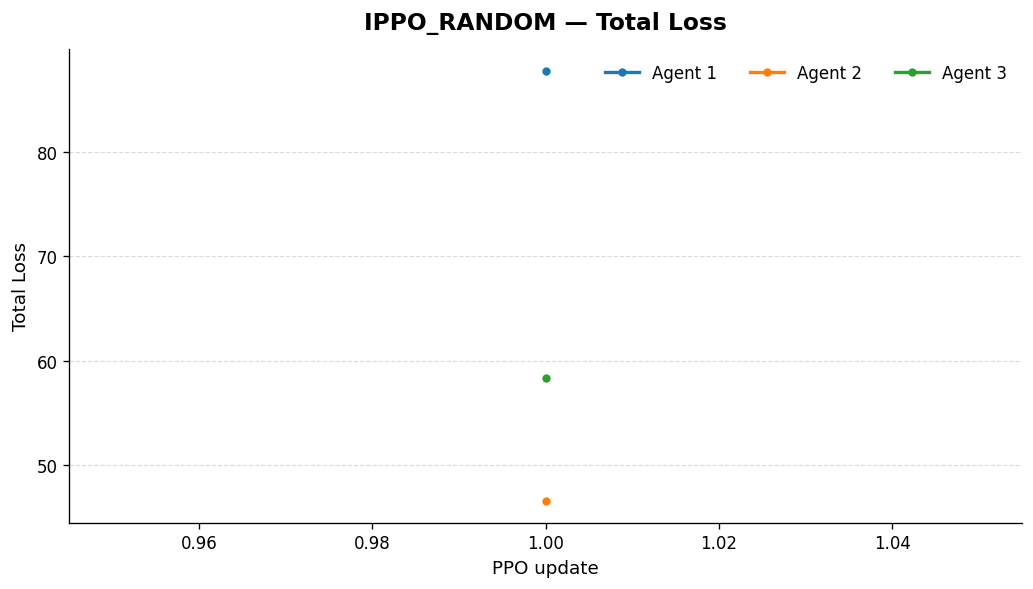

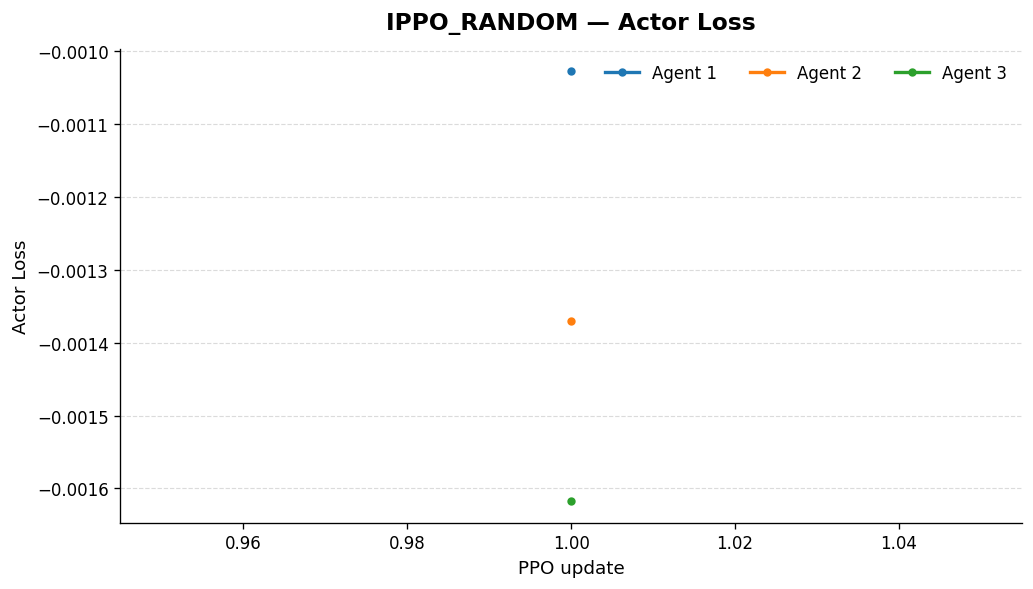

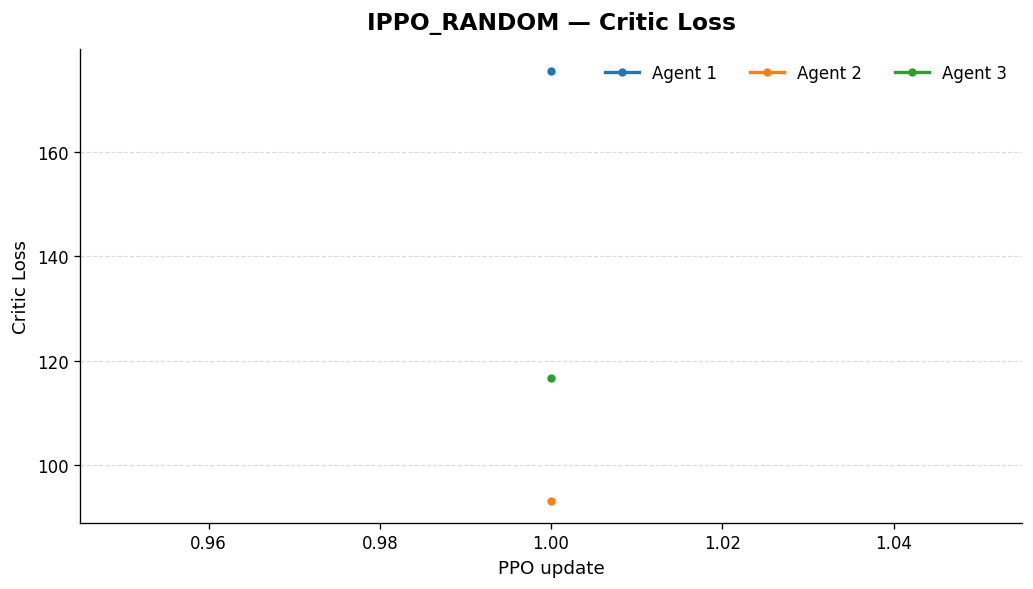

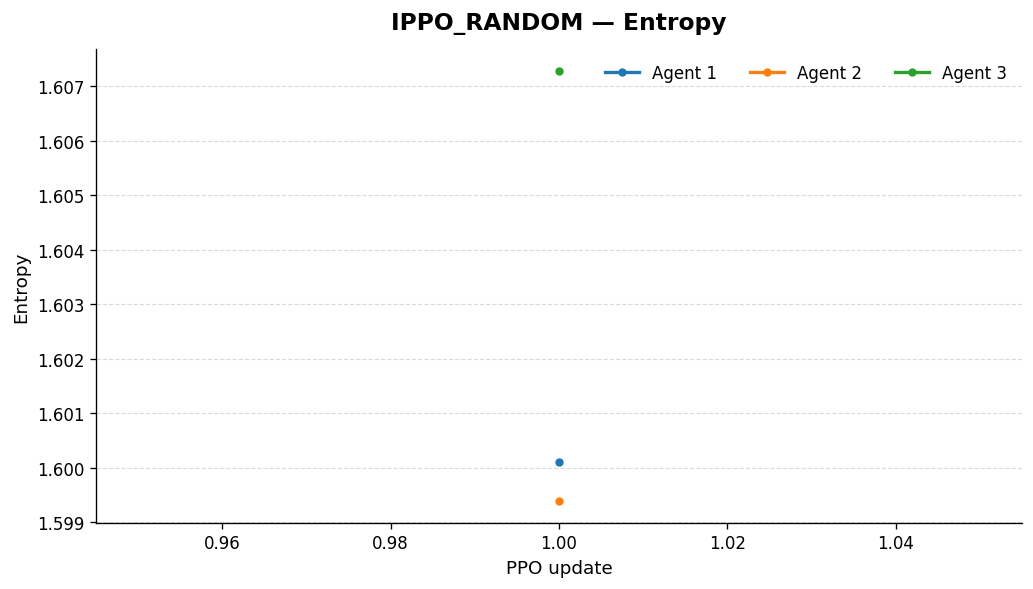

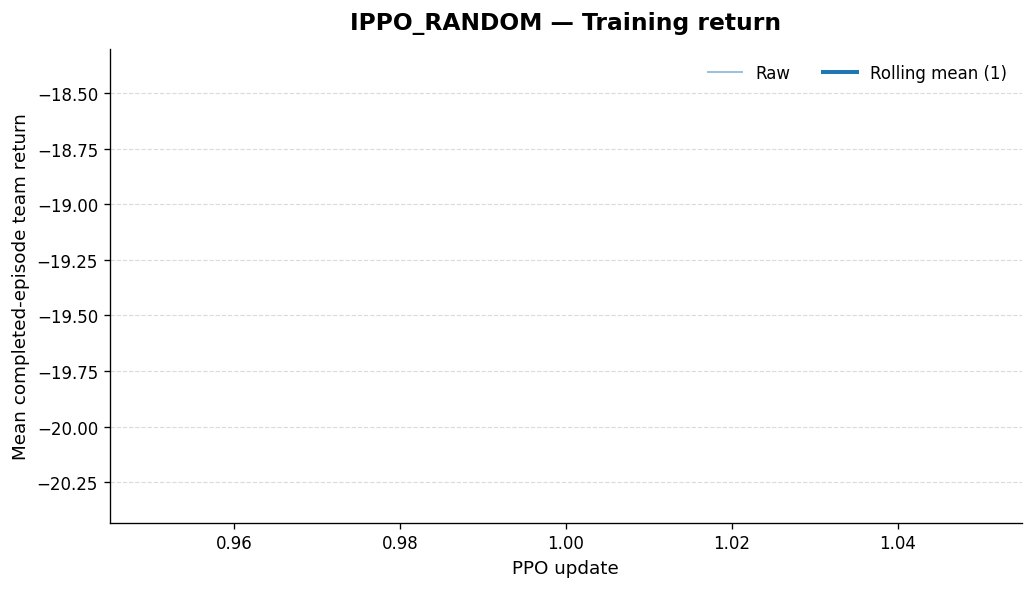

In [251]:
if RUN_TRAINING:
    for run_name in ('ippo_fixed', 'ippo_random'):
        history = training_histories[run_name]
        for metric in ('total_loss', 'actor_loss', 'critic_loss', 'entropy'):
            plot_agent_training_metric(
                history,
                metric,
                f'{run_name.upper()} — {metric.replace("_", " ").title()}',
            )
        plot_training_performance(
            history,
            f'{run_name.upper()} — Training return',
        )

<a id="t-3-3"></a>

## <a id="t-3-3">3.3: IPPO Performance Evaluation</a>

In [252]:
ippo_evaluations: Dict[str, Dict] = {}

if RUN_TRAINING:
    for mode_index, dirt_mode in enumerate(('fixed', 'random')):
        run_name = f'ippo_{dirt_mode}'
        seeds = np.arange(
            5000 + mode_index * 1000,
            5000 + mode_index * 1000 + EXPERIMENT_CONFIG.evaluation_episodes,
        )
        evaluation = evaluate_model(
            trained_models[run_name], dirt_mode, seeds
        )
        ippo_evaluations[run_name] = evaluation
        np.savez_compressed(
            DATA_DIR / f'{run_name}_evaluation.npz',
            **evaluation,
        )

    display(pd.DataFrame([
        evaluation_summary(name, result)
        for name, result in ippo_evaluations.items()
    ]).round(4))

,Model,Mean team return,Agent 1 return,Agent 2 return,Agent 3 return,Weighted completion,Full success rate,Successful length,Violation rate,Global RCR
0,ippo_fixed,-2.8,15.300000,-8.4,-9.7,0.0417,0.0,NaN,1.0,0.3333
1,ippo_random,-0.8,16.299999,-8.4,-8.7,0.0833,0.0,NaN,1.0,0.3333


<a id="t-3-4"></a>

## <a id="t-3-4">3.4: IPPO Visual Demonstration</a>

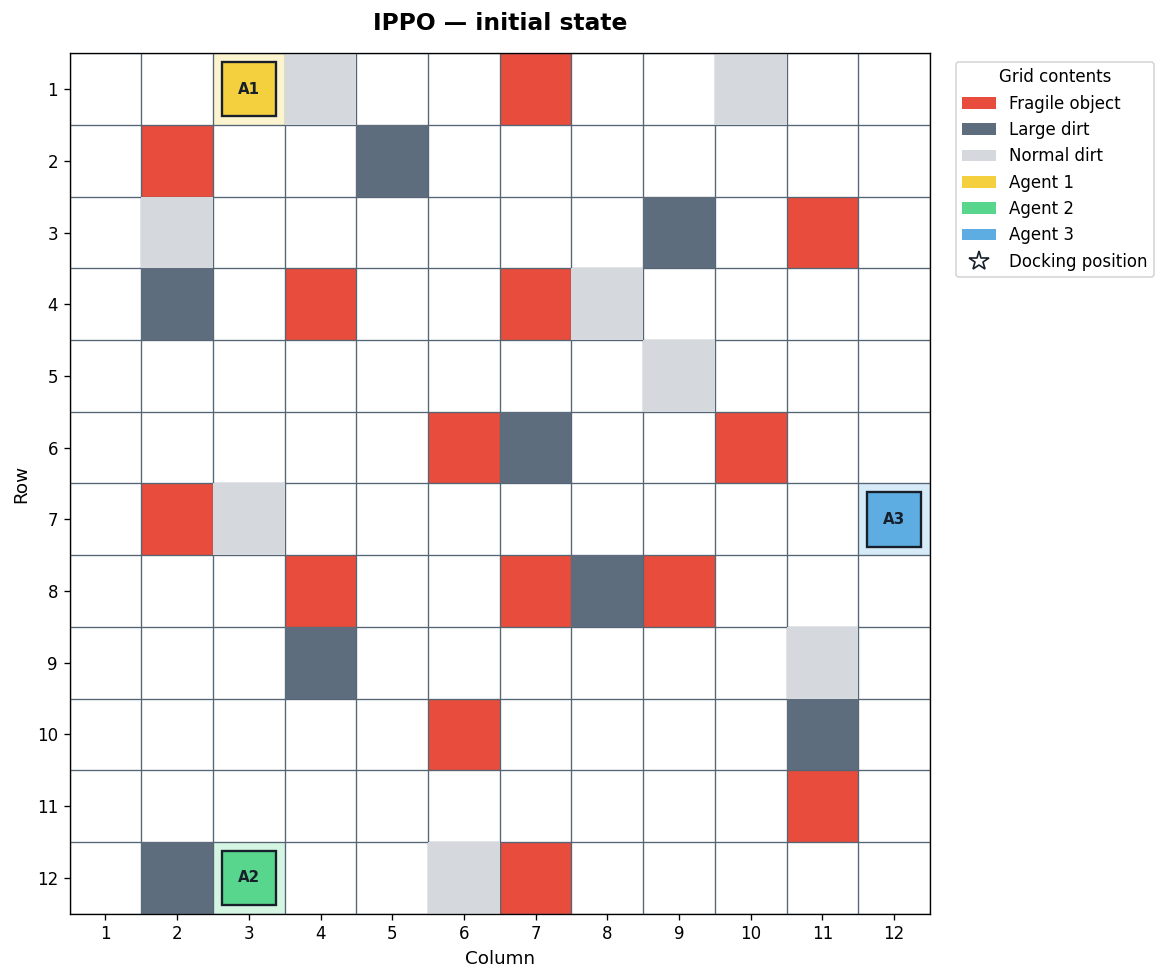

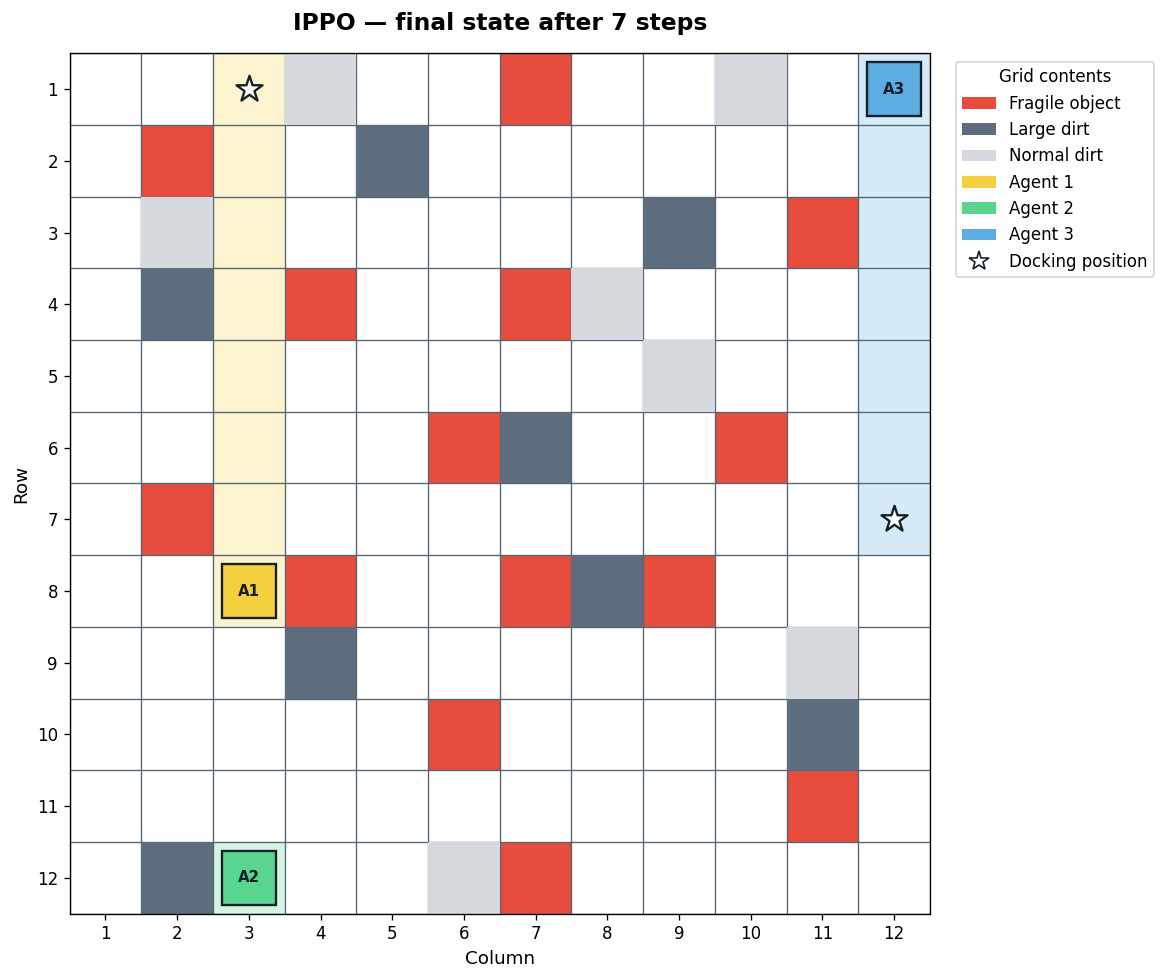

{'step': 7, 'agent_positions': [(7, 2), (11, 2), (0, 11)], 'normal_dirt_remaining': 7, 'large_dirt_remaining': 8, 'weighted_dirt_remaining': 23, 'weighted_cleaning_fraction': 0.04166666666666663, 'all_dirt_cleaned': False, 'violation_agents': [2], 'violation_reasons': {2: 'boundary'}, 'reward_events': [[('time_step', -0.1), ('new_cell', 2.0)], [('time_step', -0.1), ('idle', -0.1), ('revisit', -1.0)], [('time_step', -0.1), ('boundary', -20.0), ('revisit', -1.0)]], 'termination_reason': 'safety_violation', 'global_rcr': 0.3333333333333333}


In [253]:
if RUN_TRAINING:
    demonstration_environment = CleaningGridEnv('fixed', seed=123)
    demonstration_observations, _ = demonstration_environment.reset(seed=123)

    initial_figure, _ = demonstration_environment.render('IPPO — initial state')
    save_and_show(initial_figure, 'ippo_demonstration_initial')

    for demonstration_step in range(MAX_EPISODE_STEPS):
        actions = trained_models['ippo_fixed'].act(
            demonstration_observations, deterministic=True
        )[0]
        demonstration_observations, _, terminated, truncated, demonstration_info = (
            demonstration_environment.step(actions)
        )
        if terminated or truncated:
            break

    final_figure, _ = demonstration_environment.render(
        f'IPPO — final state after {demonstration_step + 1} steps'
    )
    save_and_show(final_figure, 'ippo_demonstration_final')
    print(demonstration_info)

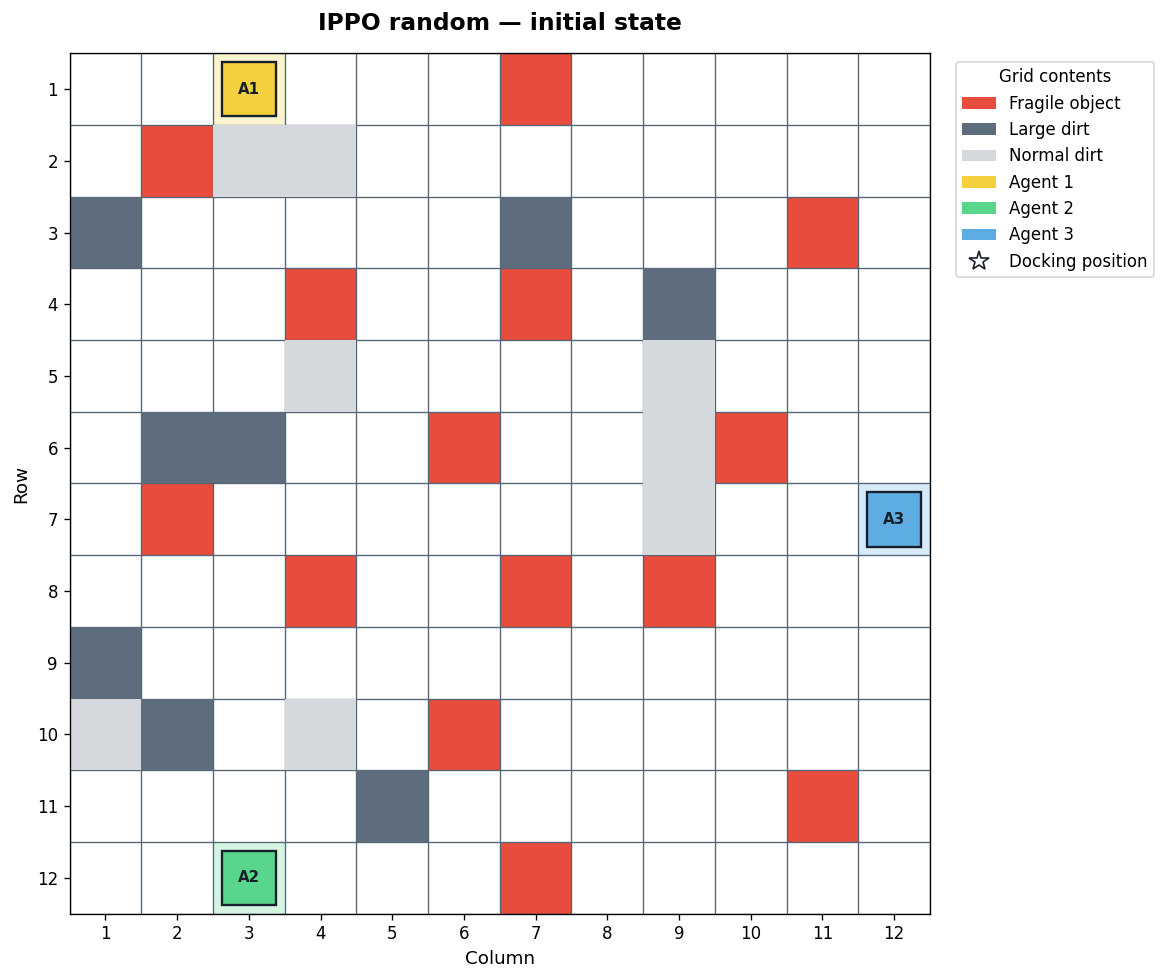

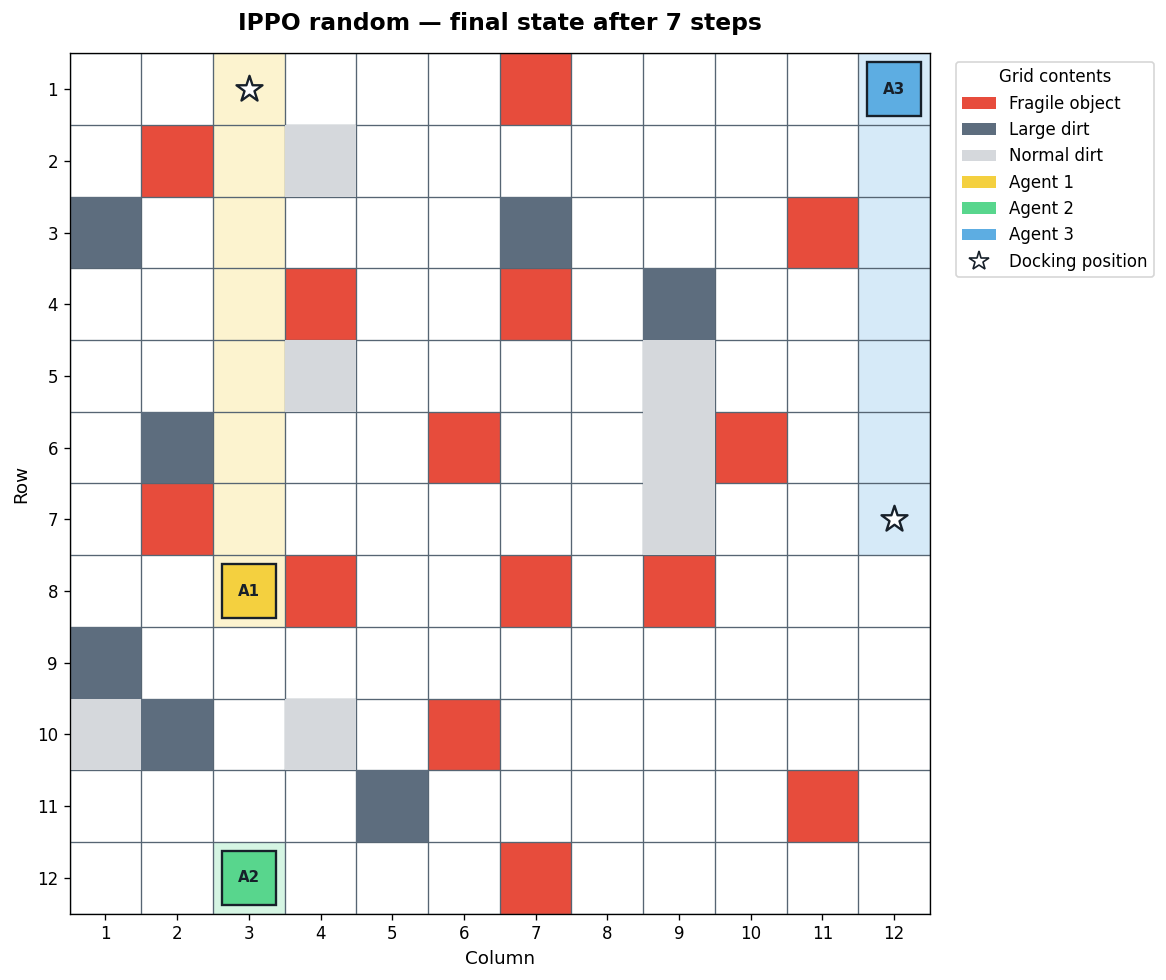

{'step': 7, 'agent_positions': [(7, 2), (11, 2), (0, 11)], 'normal_dirt_remaining': 7, 'large_dirt_remaining': 7, 'weighted_dirt_remaining': 21, 'weighted_cleaning_fraction': 0.125, 'all_dirt_cleaned': False, 'violation_agents': [2], 'violation_reasons': {2: 'boundary'}, 'reward_events': [[('time_step', -0.1), ('new_cell', 2.0)], [('time_step', -0.1), ('idle', -0.1), ('revisit', -1.0)], [('time_step', -0.1), ('boundary', -20.0), ('revisit', -1.0)]], 'termination_reason': 'safety_violation', 'global_rcr': 0.3333333333333333}


In [254]:
if RUN_TRAINING:
    random_ippo_environment = (
        CleaningGridEnv(
            "random",
            seed=125,
        )
    )
    random_ippo_observations, _ = (
        random_ippo_environment.reset(
            seed=125
        )
    )

    initial_figure, _ = (
        random_ippo_environment.render(
            "IPPO random — initial state"
        )
    )
    save_and_show(
        initial_figure,
        "ippo_random_demo_initial",
    )

    for demonstration_step in range(
        MAX_EPISODE_STEPS
    ):
        actions = trained_models[
            "ippo_random"
        ].act(
            random_ippo_observations,
            deterministic=True,
        )[0]

        (
            random_ippo_observations,
            _,
            terminated,
            truncated,
            random_ippo_info,
        ) = random_ippo_environment.step(
            actions
        )

        if terminated or truncated:
            break

    final_figure, _ = (
        random_ippo_environment.render(
            (
                "IPPO random — final state "
                f"after {demonstration_step + 1} steps"
            )
        )
    )
    save_and_show(
        final_figure,
        "ippo_random_demo_final",
    )
    print(random_ippo_info)

# <a id="task-4">Task 4: Multi-Agent Proximal Policy Optimization</a>

<a id="task-4-navigation"></a>

> **Task 4 Navigation**

- [Back to Contents](#top)



- [4.1: Source](#t-4-1)
- [4.2: MAPPO Training Results](#t-4-2)
- [4.3: MAPPO Performance Evaluation](#t-4-3)
- [4.4: MAPPO Visual Demonstration](#t-4-4)

<a id="t-4-1"></a>

## <a id="t-4-1">4.1: Source</a>

In [255]:
class MAPPO:
    algorithm_name = 'MAPPO'

    def __init__(
        self,
        config: PPOConfig = PPO_CONFIG,
        device: torch.device = DEVICE,
    ) -> None:
        self.config = config
        self.device = device

        self.actor = ActorNetwork(
            hidden_dimensions=config.hidden_dimensions,
            agent_id_dimension=NUM_AGENTS,
        ).to(device)
        self.critic = CriticNetwork(
            GLOBAL_STATE_DIMENSION,
            NUM_AGENTS,
            config.hidden_dimensions,
        ).to(device)

        self.actor_optimizer = torch.optim.Adam(
            self.actor.parameters(),
            lr=config.actor_learning_rate,
            weight_decay=config.weight_decay,
        )
        self.critic_optimizer = torch.optim.Adam(
            self.critic.parameters(),
            lr=config.critic_learning_rate,
            weight_decay=config.weight_decay,
        )

    def agent_ids(self, repetitions: int = 1) -> torch.Tensor:
        return torch.eye(
            NUM_AGENTS, dtype=torch.float32, device=self.device
        ).repeat(repetitions, 1)

    @torch.no_grad()
    def act(
        self,
        observations: np.ndarray,
        global_state: np.ndarray,
        deterministic: bool = False,
    ):
        observation_tensor = torch.as_tensor(
            observations, dtype=torch.float32, device=self.device
        )
        state_tensor = torch.as_tensor(
            global_state, dtype=torch.float32, device=self.device
        ).unsqueeze(0)

        distribution = self.actor.distribution(
            observation_tensor,
            self.agent_ids(),
        )
        actions = (
            torch.argmax(distribution.logits, dim=-1)
            if deterministic else distribution.sample()
        )
        values = self.critic(state_tensor).squeeze(0)

        return (
            actions.cpu().numpy(),
            distribution.log_prob(actions).cpu().numpy(),
            values.cpu().numpy(),
            distribution.probs.cpu().numpy(),
        )

    @torch.no_grad()
    def values(
        self,
        observations: np.ndarray,
        global_state: np.ndarray,
    ) -> np.ndarray:
        state_tensor = torch.as_tensor(
            global_state, dtype=torch.float32, device=self.device
        ).unsqueeze(0)
        return self.critic(state_tensor).squeeze(0).cpu().numpy()

    @torch.no_grad()
    def probe(self, observations: np.ndarray, global_state: np.ndarray):
        _, _, values, probabilities = self.act(
            observations, global_state, deterministic=True
        )
        return probabilities, values

    def collect_rollout(self, environment: CleaningGridEnv) -> RolloutBatch:
        observations, _ = environment.reset()

        stored_observations, stored_states = [], []
        stored_actions, stored_log_probabilities = [], []
        stored_rewards, stored_values, stored_dones = [], [], []
        episode_summaries: List[Dict] = []

        episode_returns = np.zeros(NUM_AGENTS, dtype=np.float32)
        episode_length = 0
        episode_had_violation = False

        for _ in range(self.config.rollout_length):
            global_state = environment.get_global_state()
            actions, log_probabilities, values, _ = self.act(
                observations, global_state
            )
            next_observations, rewards, terminated, truncated, info = (
                environment.step(actions)
            )
            done = terminated or truncated

            stored_observations.append(observations)
            stored_states.append(global_state)
            stored_actions.append(actions)
            stored_log_probabilities.append(log_probabilities)
            stored_rewards.append(rewards)
            stored_values.append(values)
            stored_dones.append(float(done))

            episode_returns += rewards
            episode_length += 1
            episode_had_violation |= bool(info['violation_agents'])
            observations = next_observations

            if done:
                episode_summaries.append({
                    'return_per_agent': episode_returns.copy(),
                    'team_return': float(episode_returns.sum()),
                    'length': episode_length,
                    'success': float(terminated),
                    'completion_rate': info['weighted_cleaning_fraction'],
                    'violation': float(episode_had_violation),
                })
                observations, _ = environment.reset()
                episode_returns.fill(0)
                episode_length = 0
                episode_had_violation = False

        final_state = environment.get_global_state()
        final_values = self.values(observations, final_state)

        tensor_data = {
            'observations': torch.as_tensor(
                np.asarray(stored_observations),
                dtype=torch.float32, device=self.device,
            ),
            'global_states': torch.as_tensor(
                np.asarray(stored_states),
                dtype=torch.float32, device=self.device,
            ),
            'actions': torch.as_tensor(
                np.asarray(stored_actions),
                dtype=torch.long, device=self.device,
            ),
            'old_log_probabilities': torch.as_tensor(
                np.asarray(stored_log_probabilities),
                dtype=torch.float32, device=self.device,
            ),
            'rewards': torch.as_tensor(
                np.asarray(stored_rewards),
                dtype=torch.float32, device=self.device,
            ),
            'values': torch.as_tensor(
                np.asarray(stored_values),
                dtype=torch.float32, device=self.device,
            ),
            'dones': torch.as_tensor(
                np.asarray(stored_dones),
                dtype=torch.float32, device=self.device,
            ),
        }

        advantages, returns = generalized_advantage_estimation(
            tensor_data['rewards'],
            tensor_data['values'],
            tensor_data['dones'],
            torch.as_tensor(final_values, dtype=torch.float32, device=self.device),
            self.config.gamma,
            self.config.gae_lambda,
        )

        return RolloutBatch(
            advantages=advantages,
            returns=returns,
            episode_summaries=episode_summaries,
            **tensor_data,
        )

    def update(self, batch: RolloutBatch) -> List[Dict[str, float]]:
        time_steps = batch.actions.shape[0]
        actor_samples = time_steps * NUM_AGENTS

        flattened_observations = batch.observations.reshape(
            actor_samples, GRID_SIZE, GRID_SIZE, LOCAL_CHANNELS
        )
        flattened_actions = batch.actions.reshape(-1)
        flattened_old_log_probabilities = batch.old_log_probabilities.reshape(-1)
        flattened_advantages = batch.advantages.reshape(-1)
        flattened_advantages = (
            flattened_advantages - flattened_advantages.mean()
        ) / (flattened_advantages.std() + 1e-8)
        flattened_agent_ids = self.agent_ids(time_steps)

        for _ in range(self.config.update_epochs):
            actor_permutation = torch.randperm(actor_samples, device=self.device)
            for start in range(0, actor_samples, self.config.minibatch_size):
                indices = actor_permutation[start:start + self.config.minibatch_size]
                distribution = self.actor.distribution(
                    flattened_observations[indices],
                    flattened_agent_ids[indices],
                )
                new_log_probabilities = distribution.log_prob(
                    flattened_actions[indices]
                )
                ratio = torch.exp(
                    new_log_probabilities
                    - flattened_old_log_probabilities[indices]
                )
                unclipped = ratio * flattened_advantages[indices]
                clipped = torch.clamp(
                    ratio,
                    1.0 - self.config.clip_epsilon,
                    1.0 + self.config.clip_epsilon,
                ) * flattened_advantages[indices]
                actor_loss = -torch.min(unclipped, clipped).mean()
                entropy = distribution.entropy().mean()

                self.actor_optimizer.zero_grad()
                (
                    actor_loss
                    - self.config.entropy_coefficient * entropy
                ).backward()
                nn.utils.clip_grad_norm_(
                    self.actor.parameters(),
                    self.config.max_gradient_norm,
                )
                self.actor_optimizer.step()

            critic_batch_size = max(
                1, self.config.minibatch_size // NUM_AGENTS
            )
            critic_permutation = torch.randperm(time_steps, device=self.device)
            for start in range(0, time_steps, critic_batch_size):
                indices = critic_permutation[start:start + critic_batch_size]
                predicted_values = self.critic(batch.global_states[indices])
                critic_loss = F.mse_loss(
                    predicted_values, batch.returns[indices]
                )
                self.critic_optimizer.zero_grad()
                (self.config.value_coefficient * critic_loss).backward()
                nn.utils.clip_grad_norm_(
                    self.critic.parameters(),
                    self.config.max_gradient_norm,
                )
                self.critic_optimizer.step()

        # Per-agent diagnostics after the shared update.
        diagnostics: List[Dict[str, float]] = []
        with torch.no_grad():
            predicted_values = self.critic(batch.global_states)
            for agent_id in range(NUM_AGENTS):
                observations = batch.observations[:, agent_id]
                actions = batch.actions[:, agent_id]
                old_log_probabilities = batch.old_log_probabilities[:, agent_id]
                advantages = batch.advantages[:, agent_id]
                advantages = (
                    advantages - advantages.mean()
                ) / (advantages.std() + 1e-8)
                distribution = self.actor.distribution(
                    observations,
                    self.agent_ids()[agent_id].repeat(time_steps, 1),
                )
                losses = ppo_loss_terms(
                    distribution,
                    actions,
                    old_log_probabilities,
                    advantages,
                    predicted_values[:, agent_id],
                    batch.returns[:, agent_id],
                    self.config,
                )
                diagnostics.append({
                    'actor_loss': losses['actor_loss'].item(),
                    'critic_loss': losses['critic_loss'].item(),
                    'entropy': losses['entropy'].item(),
                    'total_loss': losses['total_loss'].item(),
                    'probability_ratio': losses['mean_probability_ratio'].item(),
                })

        return diagnostics

    def save(self, path: Path) -> None:
        torch.save({
            'algorithm': self.algorithm_name,
            'config': asdict(self.config),
            'actor': self.actor.state_dict(),
            'critic': self.critic.state_dict(),
        }, path)

    def load(self, path: Path) -> None:
        checkpoint = torch.load(path, map_location=self.device, weights_only=False)
        self.actor.load_state_dict(checkpoint['actor'])
        self.critic.load_state_dict(checkpoint['critic'])

In [256]:
mappo_sanity_model = MAPPO()

mappo_architecture = pd.DataFrame([
    {
        'Component': 'Shared actor',
        'Count': 1,
        'Parameters': trainable_parameter_count(mappo_sanity_model.actor),
    },
    {
        'Component': 'Centralized critic',
        'Count': 1,
        'Parameters': trainable_parameter_count(mappo_sanity_model.critic),
    },
])

display(mappo_architecture)
assert mappo_sanity_model.actor.agent_id_dimension == 3

,Component,Count,Parameters
0,Shared actor,1,24389
1,Centralized critic,1,70307


In [257]:
mappo_one_cycle_environment = CleaningGridEnv('fixed', seed=200)
mappo_one_cycle_batch = mappo_sanity_model.collect_rollout(
    mappo_one_cycle_environment
)
mappo_one_cycle_metrics = mappo_sanity_model.update(mappo_one_cycle_batch)

mappo_shapes = pd.DataFrame({
    'Field': [
        'observations', 'global states', 'actions',
        'old log probabilities', 'rewards', 'values',
        'advantages', 'returns',
    ],
    'Shape': [
        tuple(mappo_one_cycle_batch.observations.shape),
        tuple(mappo_one_cycle_batch.global_states.shape),
        tuple(mappo_one_cycle_batch.actions.shape),
        tuple(mappo_one_cycle_batch.old_log_probabilities.shape),
        tuple(mappo_one_cycle_batch.rewards.shape),
        tuple(mappo_one_cycle_batch.values.shape),
        tuple(mappo_one_cycle_batch.advantages.shape),
        tuple(mappo_one_cycle_batch.returns.shape),
    ],
})
display(mappo_shapes)
display(pd.DataFrame(mappo_one_cycle_metrics, index=['Agent 1', 'Agent 2', 'Agent 3']))

np.savez_compressed(
    DATA_DIR / 'task2_mappo_one_cycle_rollout.npz',
    observations=mappo_one_cycle_batch.observations.cpu().numpy(),
    global_states=mappo_one_cycle_batch.global_states.cpu().numpy(),
    actions=mappo_one_cycle_batch.actions.cpu().numpy(),
    log_probabilities=(
        mappo_one_cycle_batch.old_log_probabilities.cpu().numpy()
    ),
    rewards=mappo_one_cycle_batch.rewards.cpu().numpy(),
    values=mappo_one_cycle_batch.values.cpu().numpy(),
    advantages=mappo_one_cycle_batch.advantages.cpu().numpy(),
    returns=mappo_one_cycle_batch.returns.cpu().numpy(),
)

,Field,Shape
0,observations,"(32, 3, 12, 12, 5)"
1,global states,"(32, 3, 12, 12, 5)"
2,actions,"(32, 3)"
3,old log probabilities,"(32, 3)"
4,rewards,"(32, 3)"
5,values,"(32, 3)"
6,advantages,"(32, 3)"
7,returns,"(32, 3)"


,actor_loss,critic_loss,entropy,total_loss,probability_ratio
Agent 1,-0.005055,110.801605,1.595844,55.379791,0.998798
Agent 2,-0.010406,176.316879,1.599540,88.132034,0.999535
Agent 3,-0.007706,142.796844,1.597408,71.374741,0.997948


<a id="t-4-2"></a>

## <a id="t-4-2">4.2: MAPPO Training Results</a>

In [258]:
if RUN_TRAINING:
    for mode_index, dirt_mode in enumerate(
        ("fixed", "random")
    ):
        run_name = f"mappo_{dirt_mode}"

        set_global_seed(
            MODEL_INITIALIZATION_SEED
            + 1_000
        )

        model = MAPPO()

        history, checkpoint = train_model(
            model,
            dirt_mode,
            run_name,
            EXPERIMENT_CONFIG
            .training_updates,
            SEED
            + 1_000
            + 100 * mode_index,
        )

        trained_models[
            run_name
        ] = model
        training_histories[
            run_name
        ] = history
        checkpoints[
            run_name
        ] = checkpoint

display(pd.DataFrame([
    {
        "Run": run_name,
        "Updates": int(
            history["update"][-1]
        ),
        "Final team return": float(
            history[
                "mean_team_return"
            ][-1]
        ),
        "Final cleaning rate": float(
            history[
                "mean_completion_rate"
            ][-1]
        ),
        "Final violation rate": float(
            history[
                "mean_violation_rate"
            ][-1]
        ),
    }
    for run_name, history
    in training_histories.items()
    if run_name.startswith("mappo")
]).round(4))

,Run,Updates,Final team return,Final cleaning rate,Final violation rate
0,mappo_fixed,1,-18.1545,0.0455,1.0
1,mappo_random,1,-19.6091,0.0152,1.0


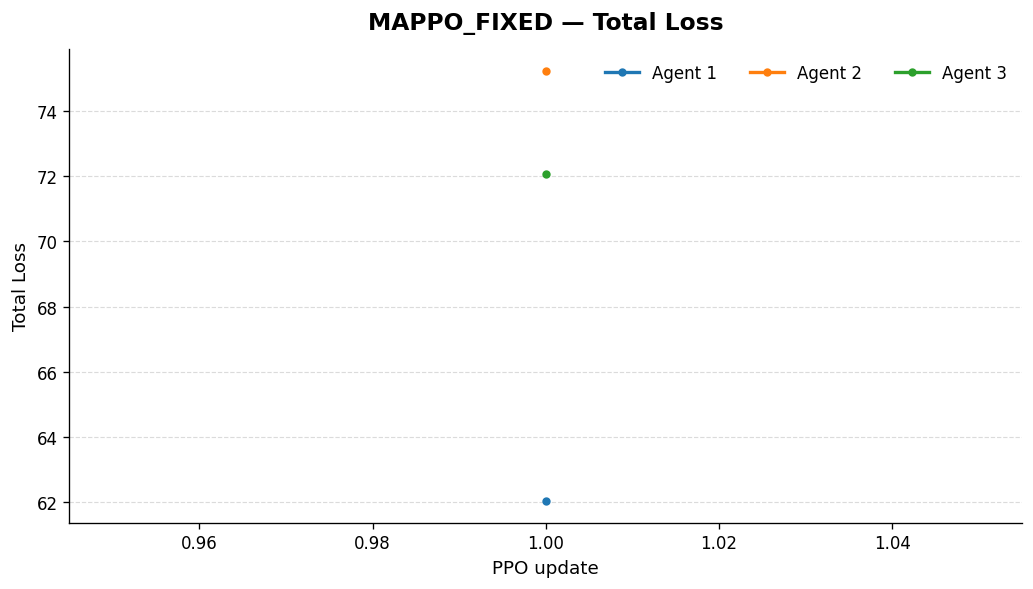

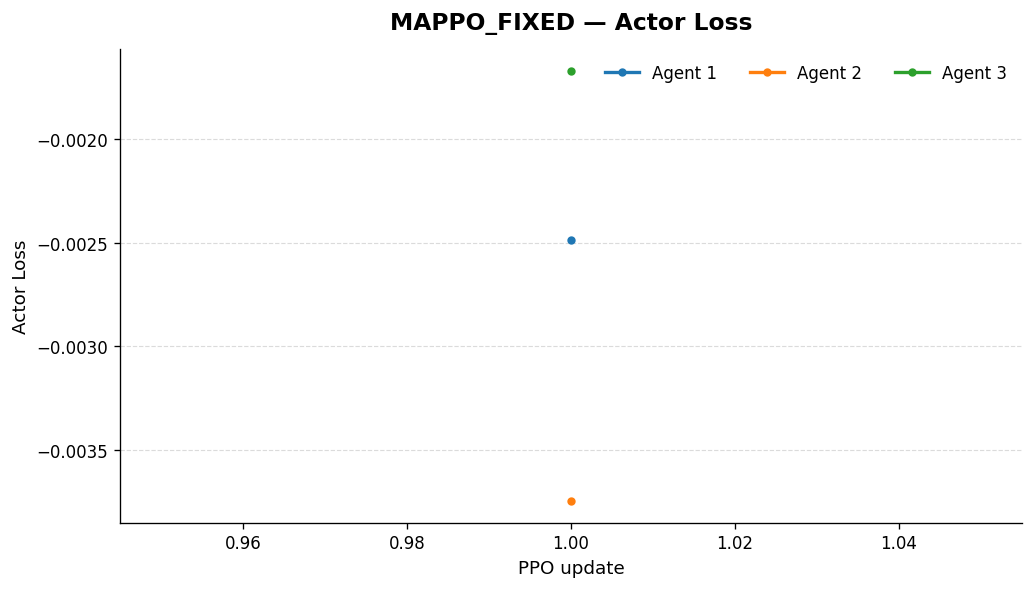

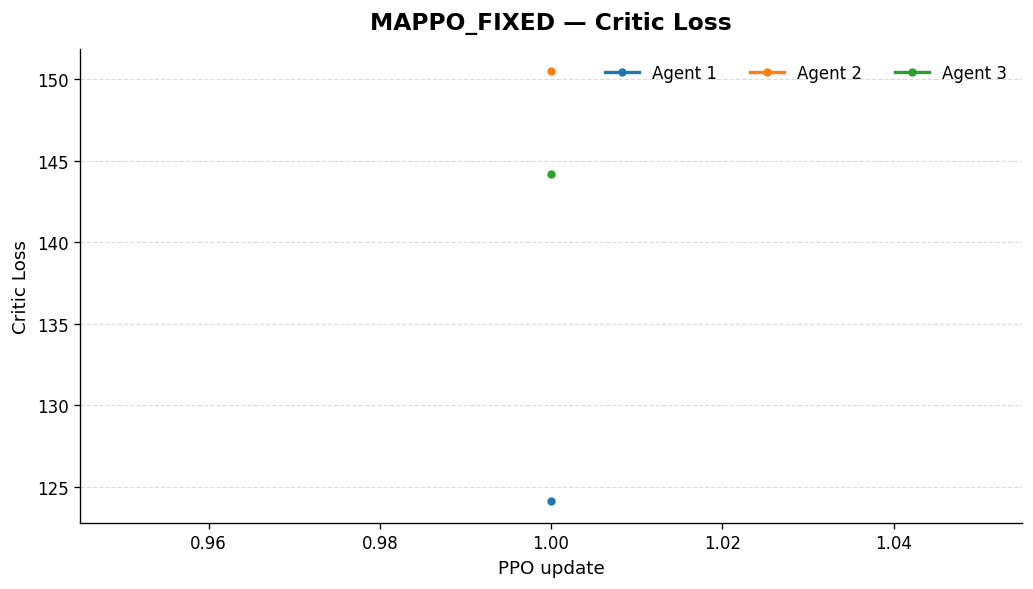

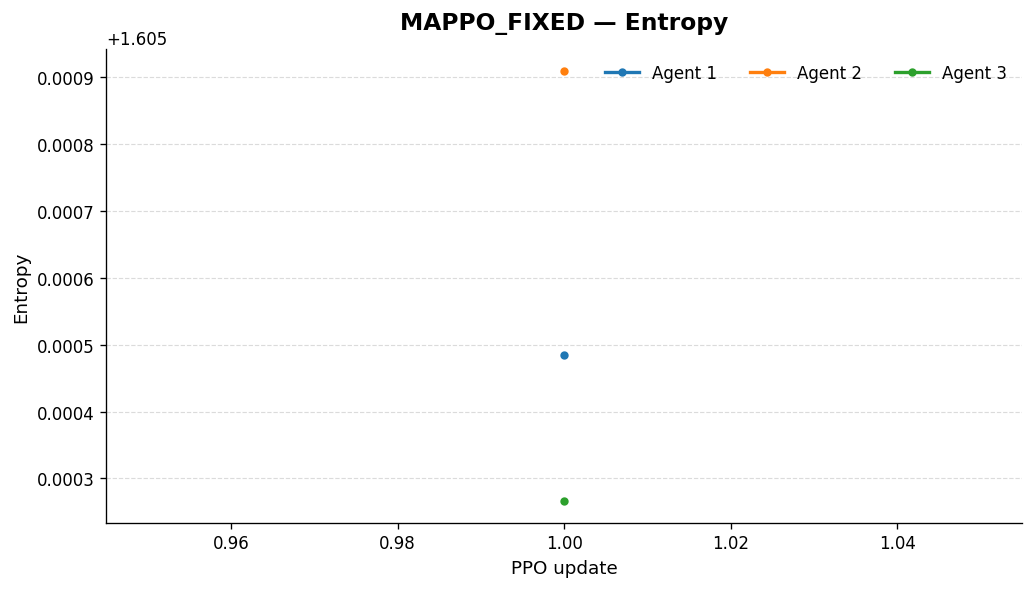

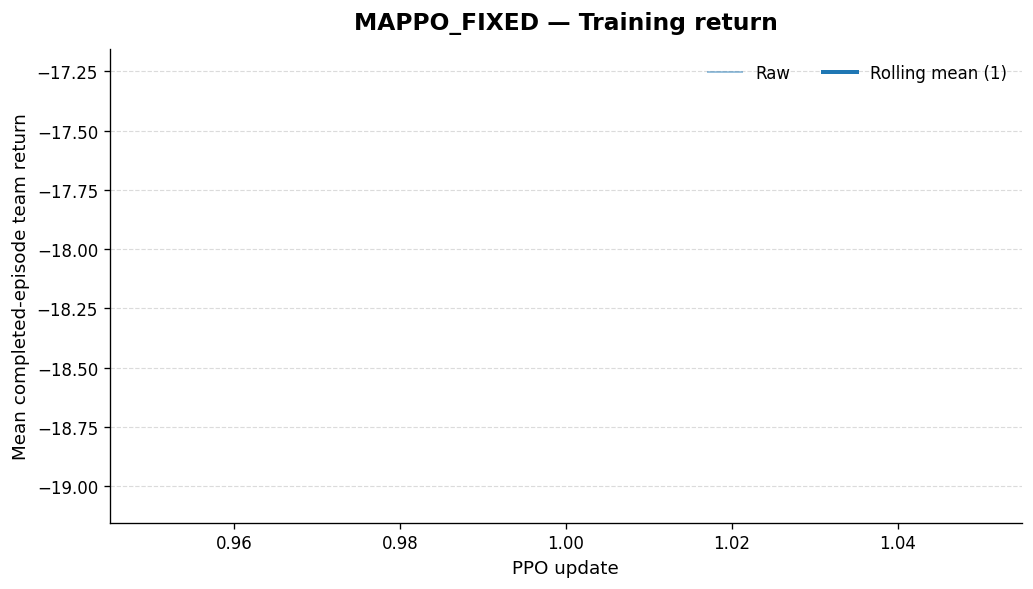

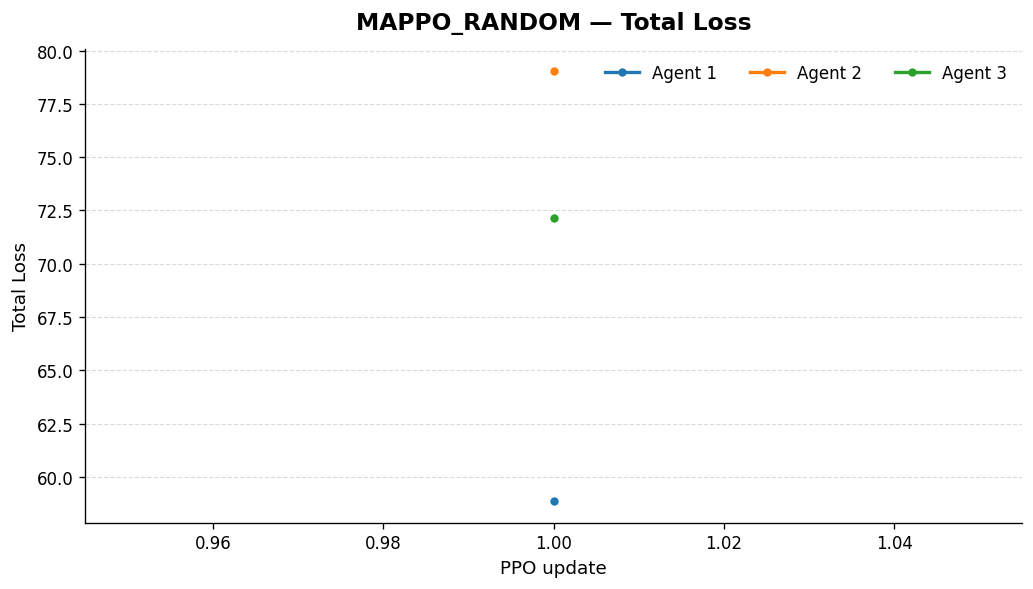

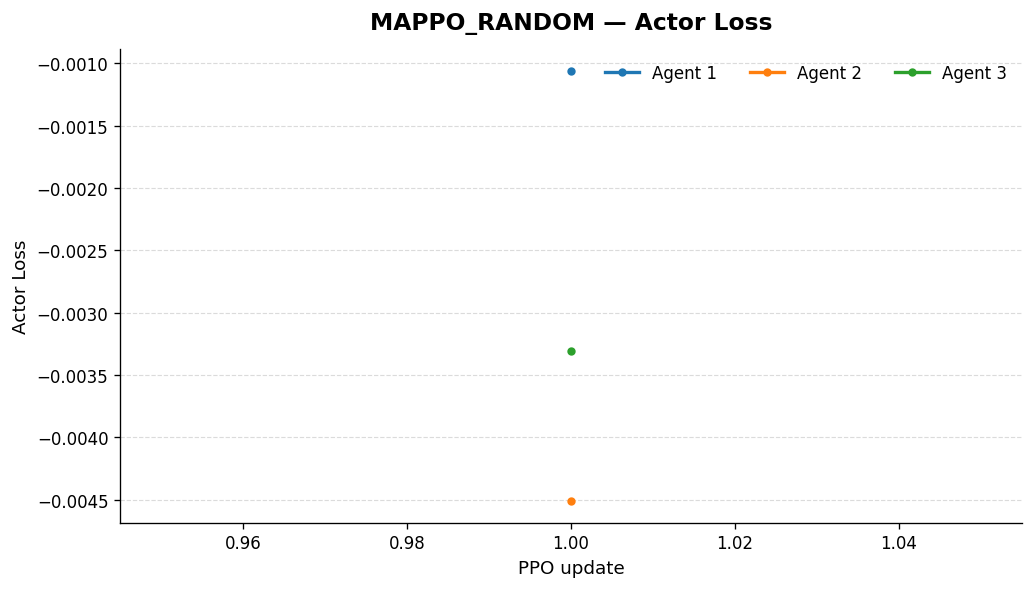

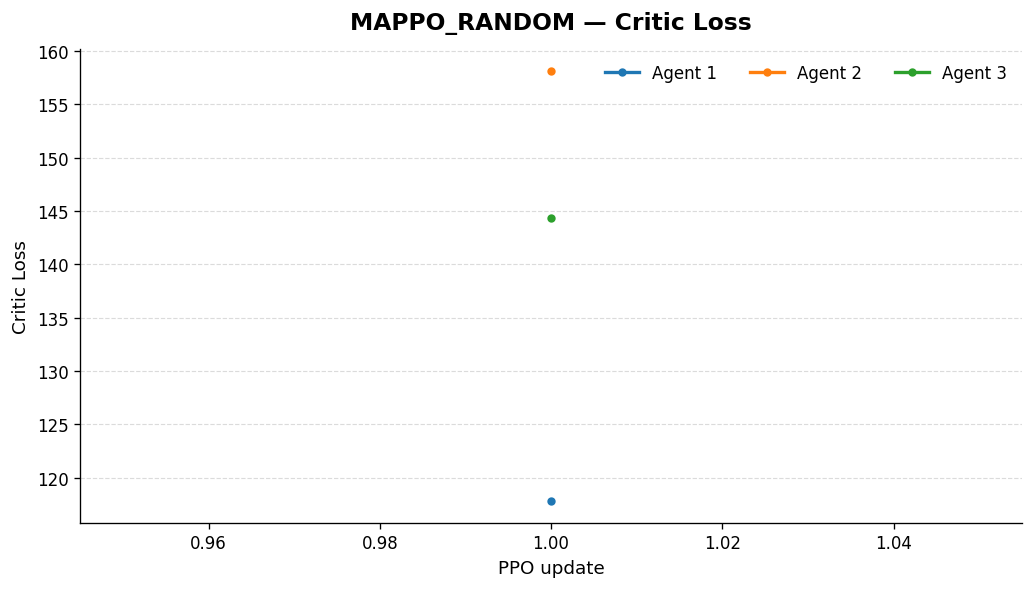

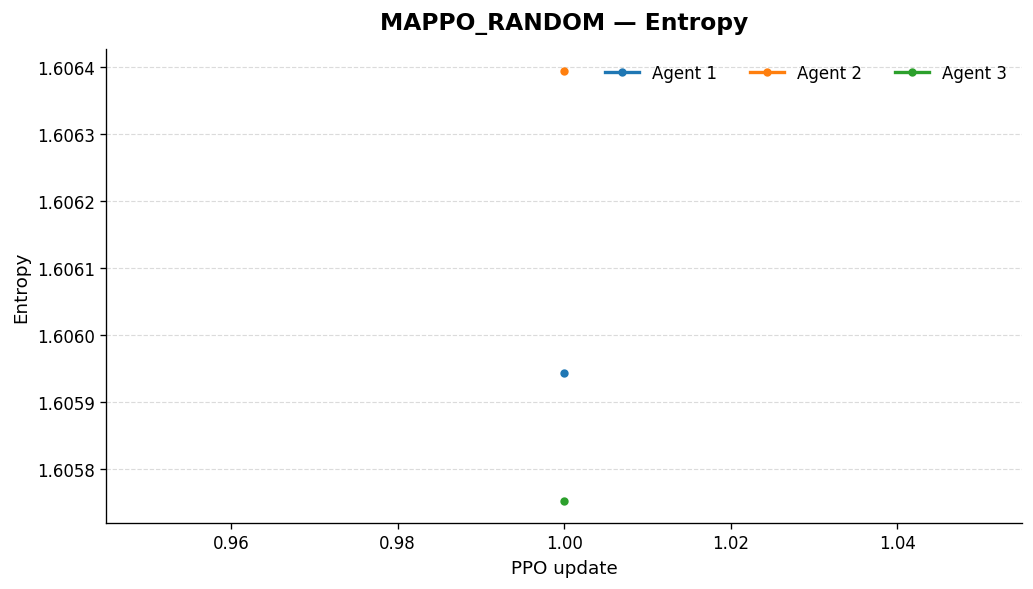

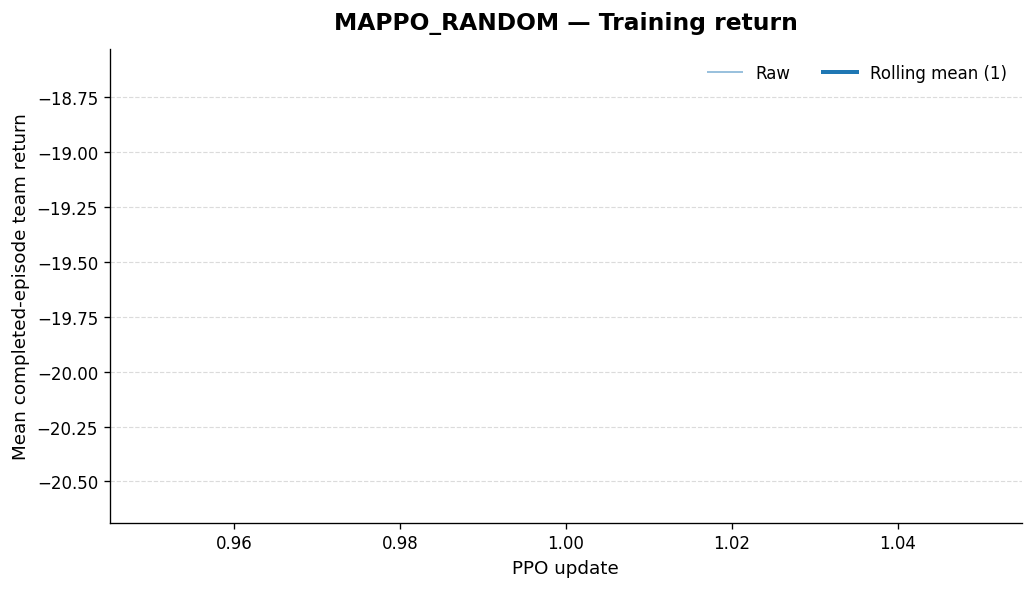

In [259]:
if RUN_TRAINING:
    for run_name in ('mappo_fixed', 'mappo_random'):
        history = training_histories[run_name]
        for metric in ('total_loss', 'actor_loss', 'critic_loss', 'entropy'):
            plot_agent_training_metric(
                history,
                metric,
                f'{run_name.upper()} — {metric.replace("_", " ").title()}',
            )
        plot_training_performance(
            history,
            f'{run_name.upper()} — Training return',
        )

<a id="t-4-3"></a>

## <a id="t-4-3">4.3: MAPPO Performance Evaluation</a>

In [260]:
mappo_evaluations: Dict[str, Dict] = {}

if RUN_TRAINING:
    for mode_index, dirt_mode in enumerate(('fixed', 'random')):
        run_name = f'mappo_{dirt_mode}'
        seeds = np.arange(
            7000 + mode_index * 1000,
            7000 + mode_index * 1000 + EXPERIMENT_CONFIG.evaluation_episodes,
        )
        evaluation = evaluate_model(
            trained_models[run_name], dirt_mode, seeds
        )
        mappo_evaluations[run_name] = evaluation
        np.savez_compressed(
            DATA_DIR / f'{run_name}_evaluation.npz',
            **evaluation,
        )

    display(pd.DataFrame([
        evaluation_summary(name, result)
        for name, result in mappo_evaluations.items()
    ]).round(4))

,Model,Mean team return,Agent 1 return,Agent 2 return,Agent 3 return,Weighted completion,Full success rate,Successful length,Violation rate,Global RCR
0,mappo_fixed,-17.3,1.9,-21.1,1.9,0.0000,0.0,NaN,1.0,0.1667
1,mappo_random,-16.3,1.9,-21.1,2.9,0.0208,0.0,NaN,1.0,0.1667


<a id="t-4-4"></a>

## <a id="t-4-4">4.4: MAPPO Visual Demonstration</a>

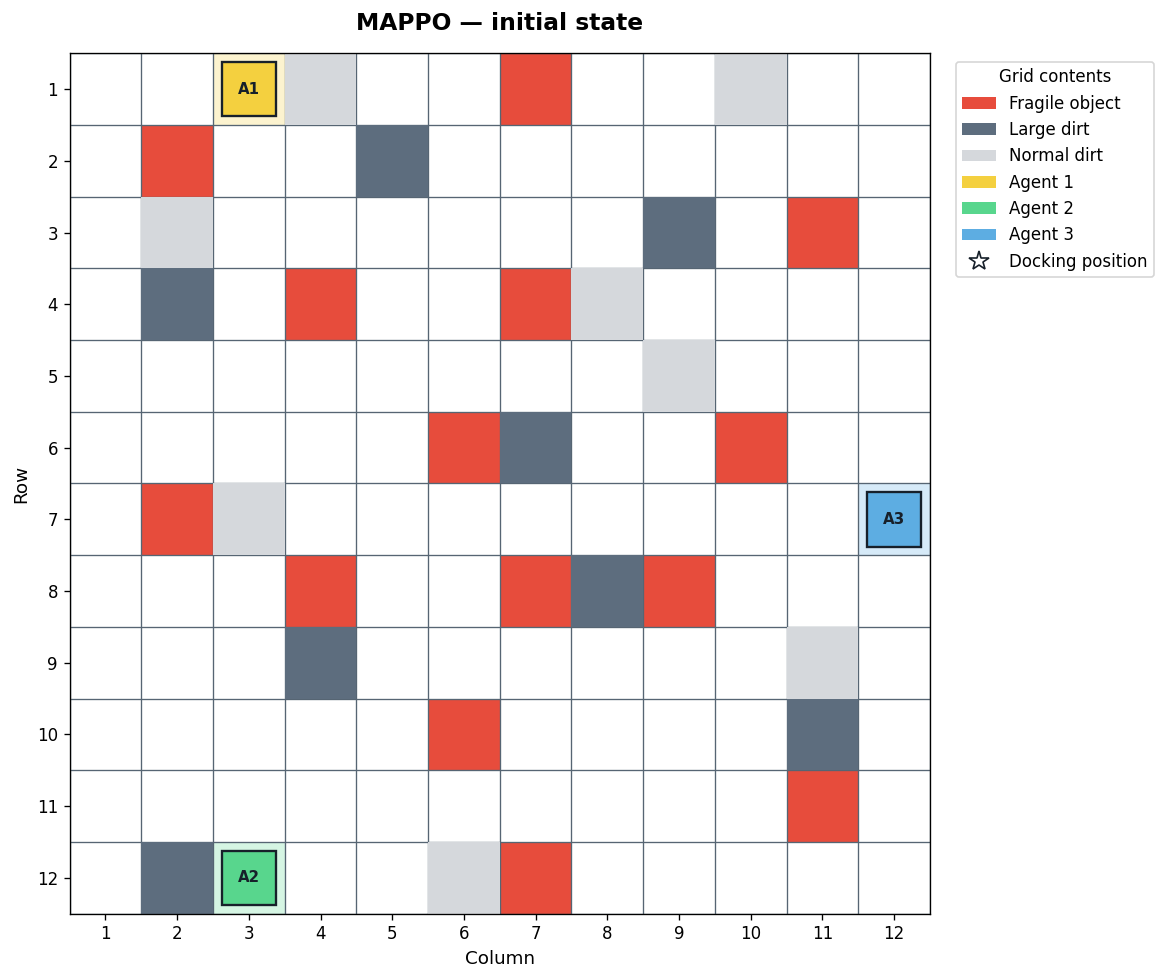

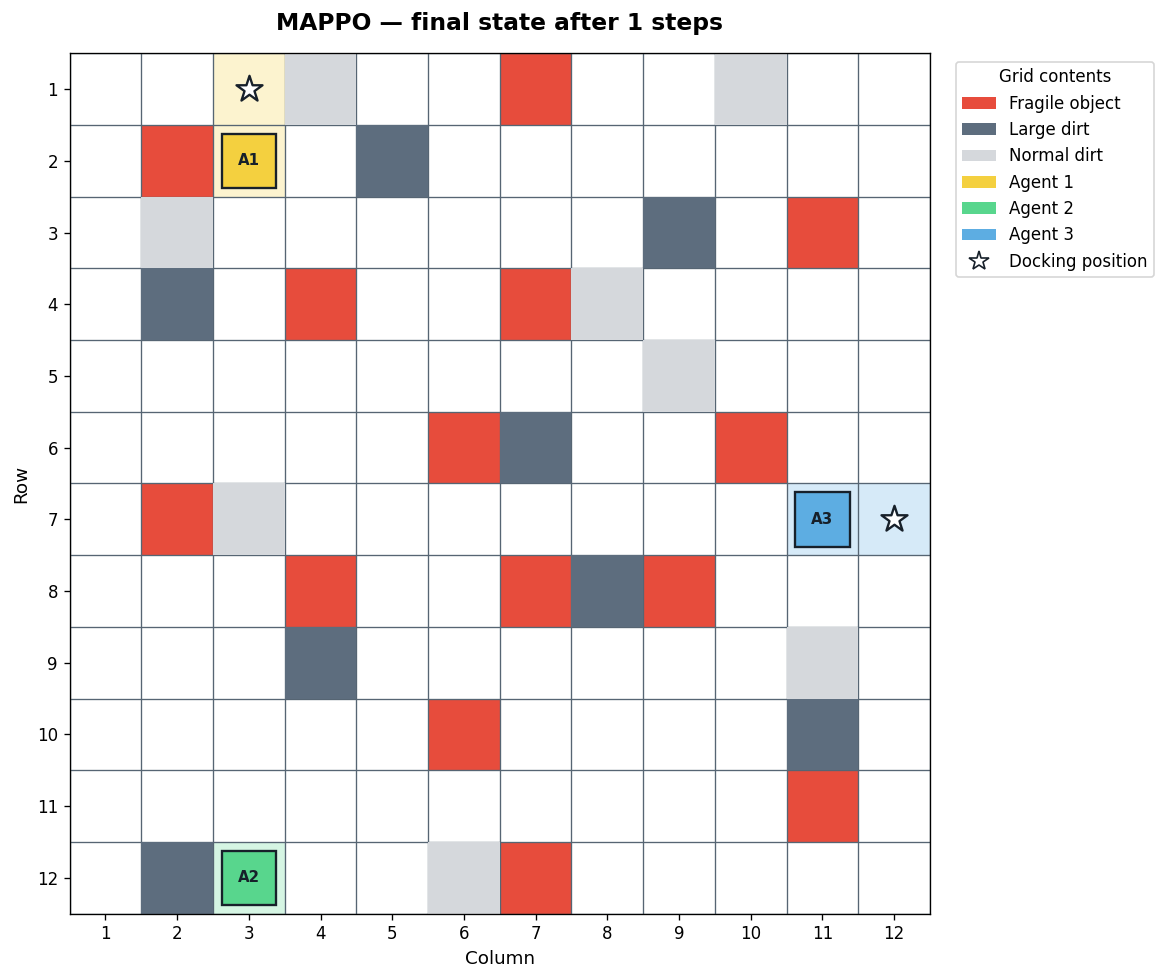

{'step': 1, 'agent_positions': [(1, 2), (11, 2), (6, 10)], 'normal_dirt_remaining': 8, 'large_dirt_remaining': 8, 'weighted_dirt_remaining': 24, 'weighted_cleaning_fraction': 0.0, 'all_dirt_cleaned': False, 'violation_agents': [1], 'violation_reasons': {1: 'boundary'}, 'reward_events': [[('time_step', -0.1), ('new_cell', 2.0)], [('time_step', -0.1), ('boundary', -20.0), ('revisit', -1.0)], [('time_step', -0.1), ('new_cell', 2.0)]], 'termination_reason': 'safety_violation', 'global_rcr': 0.16666666666666666}


In [261]:
if RUN_TRAINING:
    demonstration_environment = CleaningGridEnv('fixed', seed=124)
    demonstration_observations, _ = demonstration_environment.reset(seed=124)

    initial_figure, _ = demonstration_environment.render('MAPPO — initial state')
    save_and_show(initial_figure, 'mappo_demonstration_initial')

    for demonstration_step in range(MAX_EPISODE_STEPS):
        actions = trained_models['mappo_fixed'].act(
            demonstration_observations,
            demonstration_environment.get_global_state(),
            deterministic=True,
        )[0]
        demonstration_observations, _, terminated, truncated, demonstration_info = (
            demonstration_environment.step(actions)
        )
        if terminated or truncated:
            break

    final_figure, _ = demonstration_environment.render(
        f'MAPPO — final state after {demonstration_step + 1} steps'
    )
    save_and_show(final_figure, 'mappo_demonstration_final')
    print(demonstration_info)

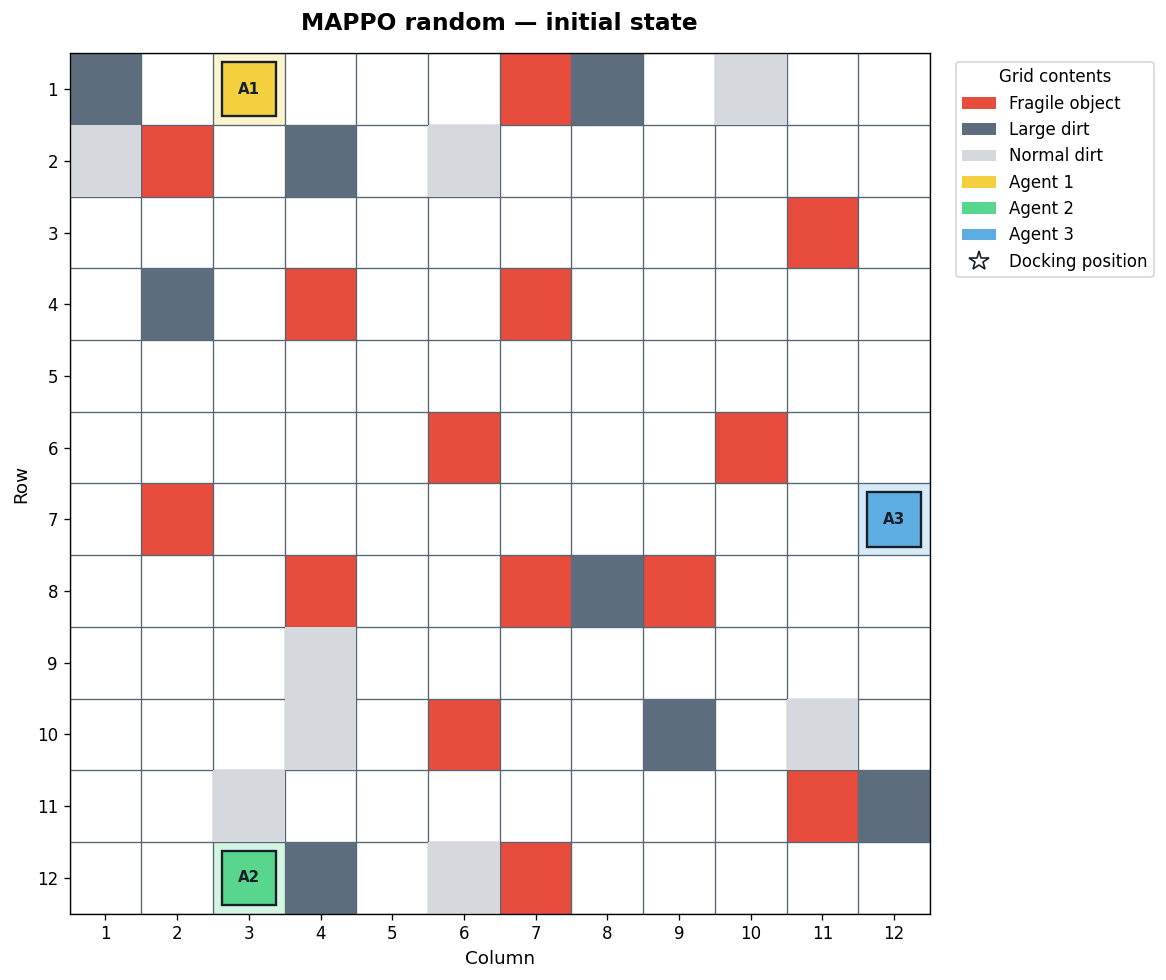

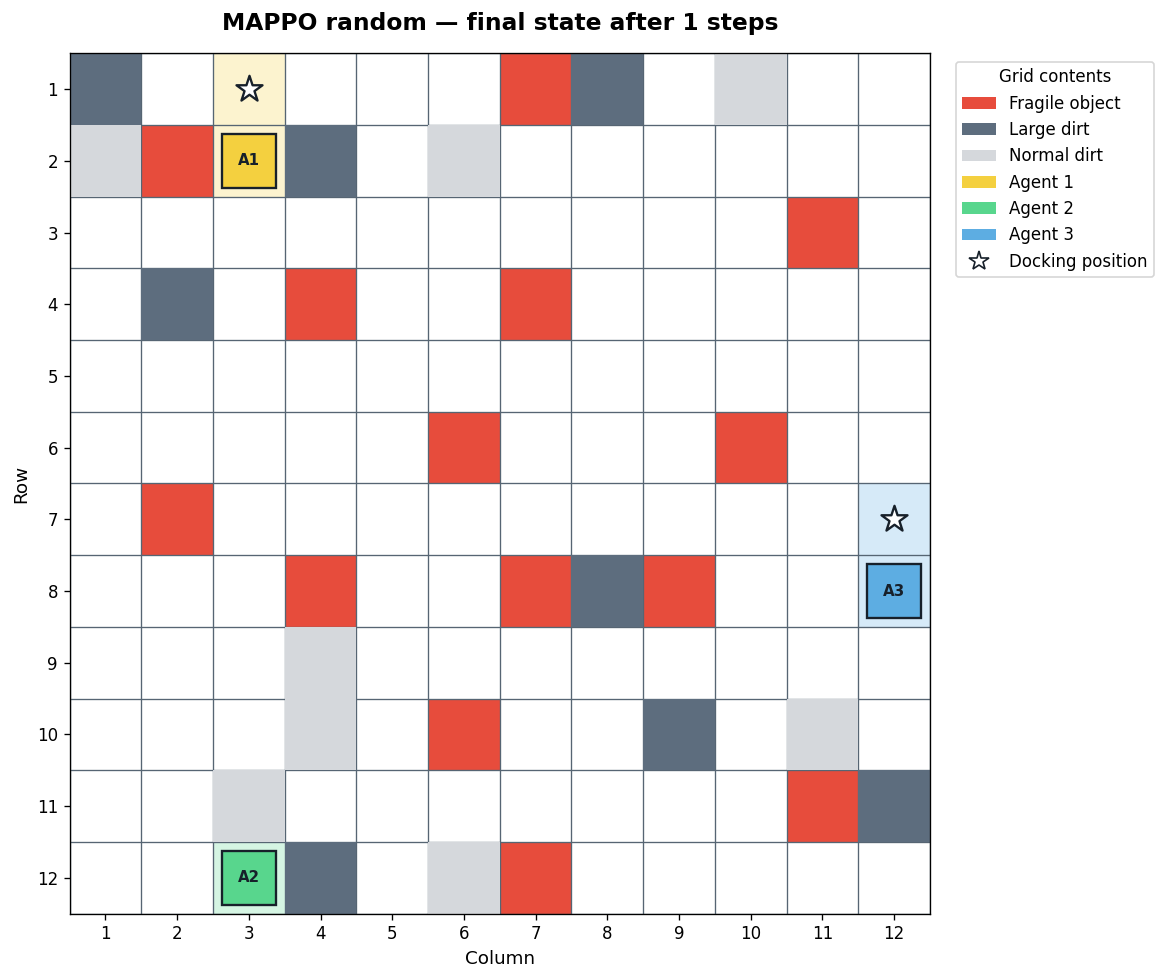

{'step': 1, 'agent_positions': [(1, 2), (11, 2), (7, 11)], 'normal_dirt_remaining': 8, 'large_dirt_remaining': 8, 'weighted_dirt_remaining': 24, 'weighted_cleaning_fraction': 0.0, 'all_dirt_cleaned': False, 'violation_agents': [1], 'violation_reasons': {1: 'boundary'}, 'reward_events': [[('time_step', -0.1), ('new_cell', 2.0)], [('time_step', -0.1), ('boundary', -20.0), ('revisit', -1.0)], [('time_step', -0.1), ('new_cell', 2.0)]], 'termination_reason': 'safety_violation', 'global_rcr': 0.16666666666666666}


In [262]:
if RUN_TRAINING:
    random_mappo_environment = (
        CleaningGridEnv(
            "random",
            seed=126,
        )
    )
    random_mappo_observations, _ = (
        random_mappo_environment.reset(
            seed=126
        )
    )

    initial_figure, _ = (
        random_mappo_environment.render(
            "MAPPO random — initial state"
        )
    )
    save_and_show(
        initial_figure,
        "mappo_random_demo_initial",
    )

    for demonstration_step in range(
        MAX_EPISODE_STEPS
    ):
        actions = trained_models[
            "mappo_random"
        ].act(
            random_mappo_observations,
            random_mappo_environment
            .get_global_state(),
            deterministic=True,
        )[0]

        (
            random_mappo_observations,
            _,
            terminated,
            truncated,
            random_mappo_info,
        ) = random_mappo_environment.step(
            actions
        )

        if terminated or truncated:
            break

    final_figure, _ = (
        random_mappo_environment.render(
            (
                "MAPPO random — final state "
                f"after {demonstration_step + 1} steps"
            )
        )
    )
    save_and_show(
        final_figure,
        "mappo_random_demo_final",
    )
    print(random_mappo_info)

# <a id="task-5">Task 5: Comprehensive Evaluation</a>

<a id="task-5-navigation"></a>

> **Task 5 Navigation**

- [Back to Contents](#top)



- [5.1: Generalization Analysis](#t-5-1)
- [5.2: Global Redundancy Coverage Ratio Map](#t-5-2)
- [5.3: Agents' Contribution Analysis](#t-5-3)
- [5.4: Jensen–Shannon Divergence Pairwise Matrix](#t-5-4)

<a id="t-5-1"></a>

## <a id="t-5-1">5.1: Generalization Analysis</a>


In [263]:
generalisation_evaluations: Dict[str, Dict] = {}

if RUN_TRAINING:
    generalisation_seeds = np.arange(
        100_000,
        100_000 + EXPERIMENT_CONFIG.generalisation_episodes,
    )

    for run_name, model in trained_models.items():
        evaluation = evaluate_model(model, 'random', generalisation_seeds)
        generalisation_evaluations[run_name] = evaluation
        np.savez_compressed(
            DATA_DIR / f'{run_name}_generalisation.npz',
            **evaluation,
        )

    generalisation_table = pd.DataFrame([
        evaluation_summary(name, result)
        for name, result in generalisation_evaluations.items()
    ]).sort_values('Weighted completion', ascending=False)

    display(generalisation_table.round(4))

,Model,Mean team return,Agent 1 return,Agent 2 return,Agent 3 return,Weighted completion,Full success rate,Successful length,Violation rate,Global RCR
0,ippo_fixed,-0.8000,15.3,-8.4,-7.7000,0.0833,0.0,NaN,1.0,0.3333
1,ippo_random,-0.8000,15.3,-8.4,-7.7000,0.0833,0.0,NaN,1.0,0.3333
2,mappo_fixed,-15.9667,1.9,-21.1,3.2333,0.0278,0.0,NaN,1.0,0.1667
3,mappo_random,-17.3000,1.9,-21.1,1.9000,0.0000,0.0,NaN,1.0,0.1667


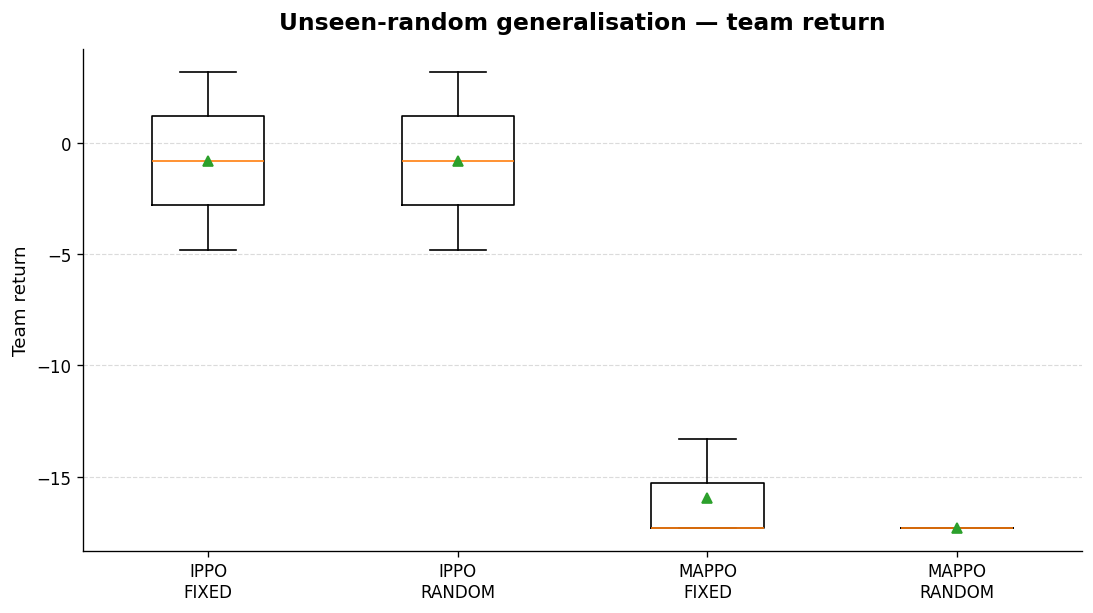

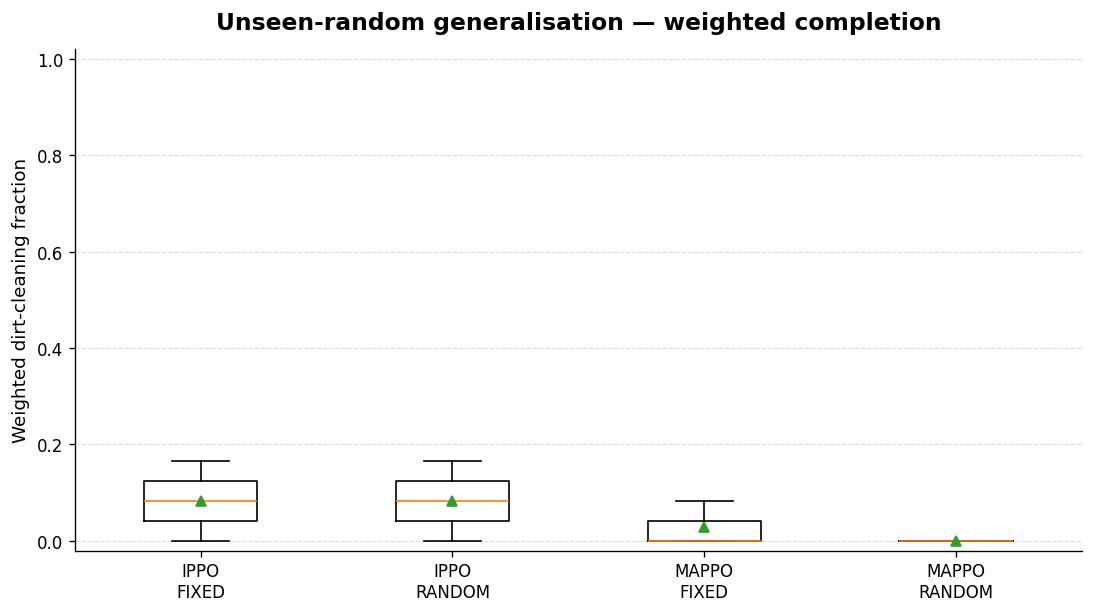

In [264]:
def comparison_boxplot(
    evaluations: Dict[str, Dict],
    metric: str,
    title: str,
    y_label: str,
    y_limits: Optional[Tuple[float, float]] = None,
) -> None:
    labels = list(evaluations)
    figure, axis = plt.subplots(figsize=(9, 5), constrained_layout=True)
    axis.boxplot(
        [evaluations[label][metric] for label in labels],
        tick_labels=[label.replace('_', '\n').upper() for label in labels],
        showmeans=True,
    )
    if y_limits:
        axis.set_ylim(*y_limits)
    finish_axis(axis, title, None, y_label, False)
    save_and_show(figure, title)


if RUN_TRAINING:
    comparison_boxplot(
        generalisation_evaluations,
        'team_return',
        'Unseen-random generalisation — team return',
        'Team return',
    )
    comparison_boxplot(
        generalisation_evaluations,
        'completion_rate',
        'Unseen-random generalisation — weighted completion',
        'Weighted dirt-cleaning fraction',
        (-0.02, 1.02),
    )

In [265]:
if RUN_TRAINING:
    comprehensive_summary = (
        pd.DataFrame([
            evaluation_summary(
                name,
                result,
            )
            for name, result
            in generalisation_evaluations.items()
        ])
        .sort_values(
            "Weighted completion",
            ascending=False,
        )
    )

    display(
        comprehensive_summary.style.format(
            precision=4,
            na_rep="N/A",
        )
    )

    comprehensive_summary.to_csv(
        DATA_DIR
        / "task_5_generalisation_summary.csv",
        index=False,
    )

,Model,Mean team return,Agent 1 return,Agent 2 return,Agent 3 return,Weighted completion,Full success rate,Successful length,Violation rate,Global RCR
0,ippo_fixed,-0.8000,15.3000,-8.4000,-7.7000,0.0833,0.0000,N/A,1.0000,0.3333
1,ippo_random,-0.8000,15.3000,-8.4000,-7.7000,0.0833,0.0000,N/A,1.0000,0.3333
2,mappo_fixed,-15.9667,1.9000,-21.1000,3.2333,0.0278,0.0000,N/A,1.0000,0.1667
3,mappo_random,-17.3000,1.9000,-21.1000,1.9000,0.0000,0.0000,N/A,1.0000,0.1667


<a id="t-5-2"></a>

## <a id="t-5-2">5.2: Global Redundancy Coverage Ratio Map</a>

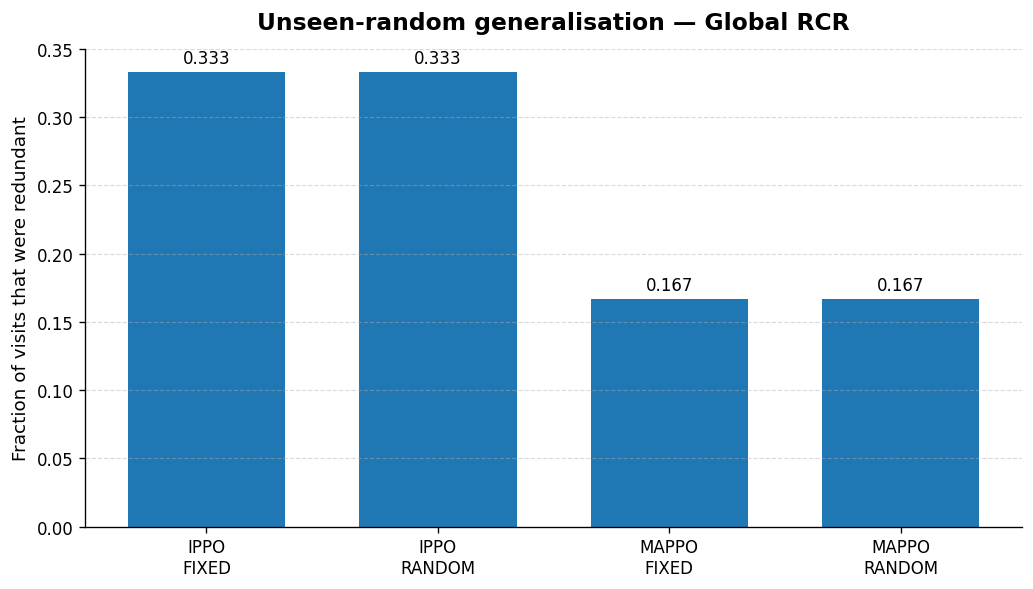

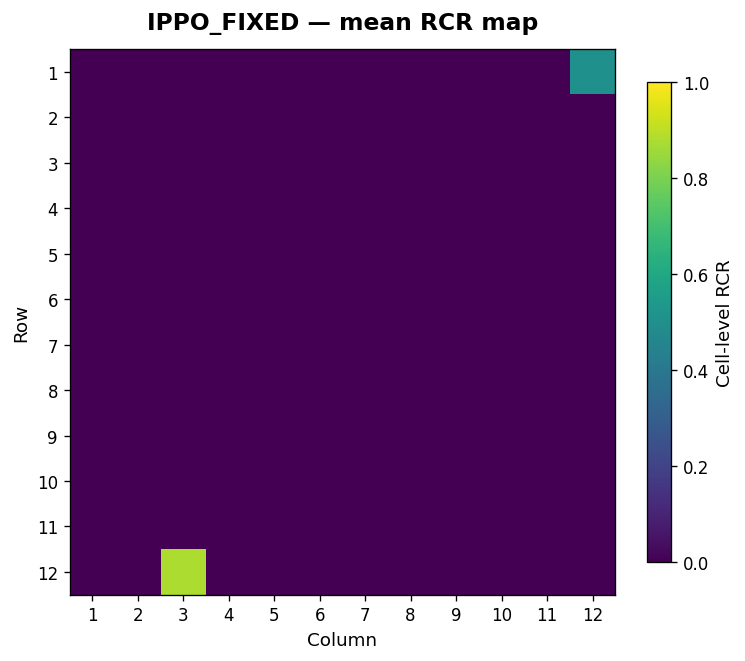

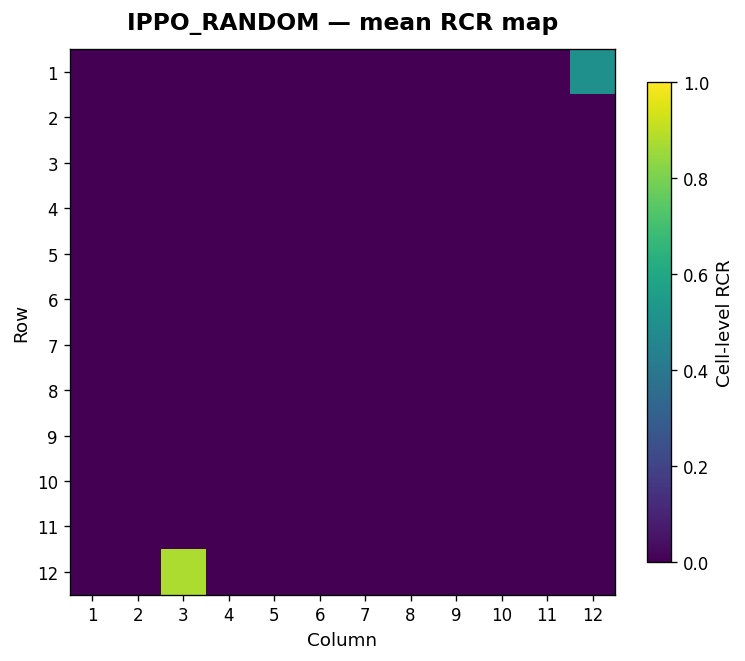

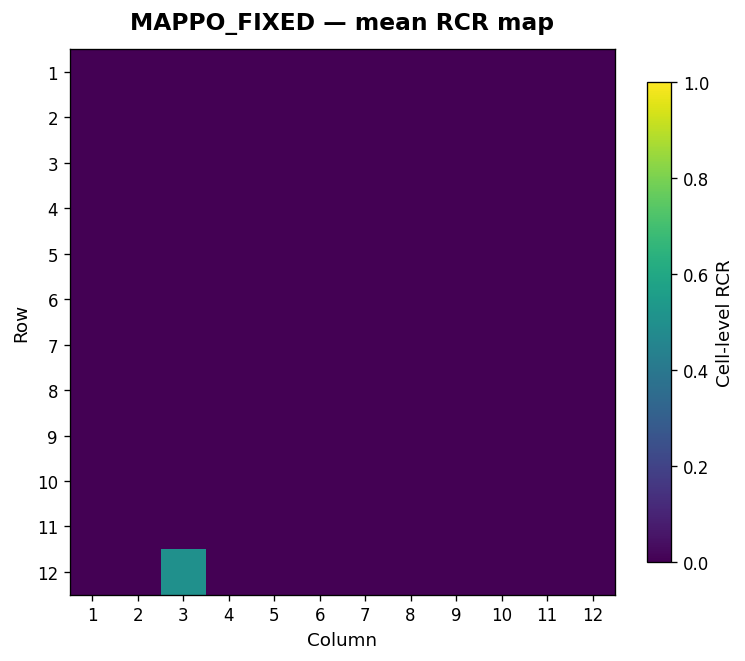

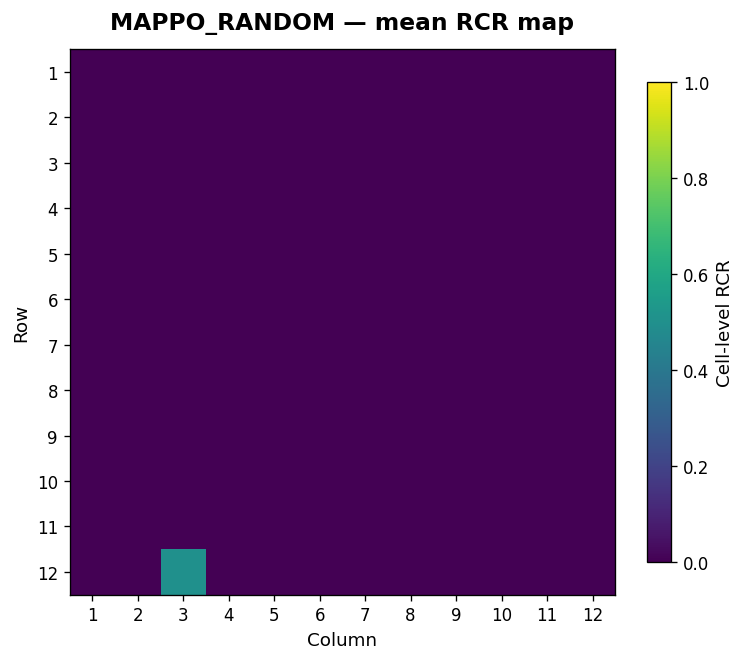

In [266]:
if RUN_TRAINING:
    labels = list(generalisation_evaluations)
    rcr_values = [
        generalisation_evaluations[label]['global_rcr'].mean()
        for label in labels
    ]

    figure, axis = plt.subplots(figsize=(8.5, 4.8), constrained_layout=True)
    bars = axis.bar(np.arange(len(labels)), rcr_values, width=0.68)
    axis.set_xticks(np.arange(len(labels)))
    axis.set_xticklabels([
        label.replace('_', '\n').upper() for label in labels
    ])
    axis.bar_label(bars, fmt='%.3f', padding=3)
    finish_axis(
        axis,
        'Unseen-random generalisation — Global RCR',
        None,
        'Fraction of visits that were redundant',
        False,
    )
    save_and_show(figure, 'generalisation_global_rcr')

    for label, evaluation in generalisation_evaluations.items():
        figure, axis = plt.subplots(figsize=(6.4, 5.4), constrained_layout=True)
        image = axis.imshow(
            evaluation['rcr_map'],
            vmin=0,
            vmax=1,
            origin='upper',
            interpolation='nearest',
        )
        axis.set_xticks(range(GRID_SIZE))
        axis.set_yticks(range(GRID_SIZE))
        axis.set_xticklabels(range(1, GRID_SIZE + 1))
        axis.set_yticklabels(range(1, GRID_SIZE + 1))
        axis.set_xlabel('Column')
        axis.set_ylabel('Row')
        axis.set_title(f'{label.upper()} — mean RCR map', pad=12)
        colour_bar = figure.colorbar(image, ax=axis, shrink=0.88)
        colour_bar.set_label('Cell-level RCR')
        save_and_show(figure, f'{label}_rcr_map')

<a id="t-5-3"></a>

## <a id="t-5-3">5.3: Agents' Contribution Analysis</a>

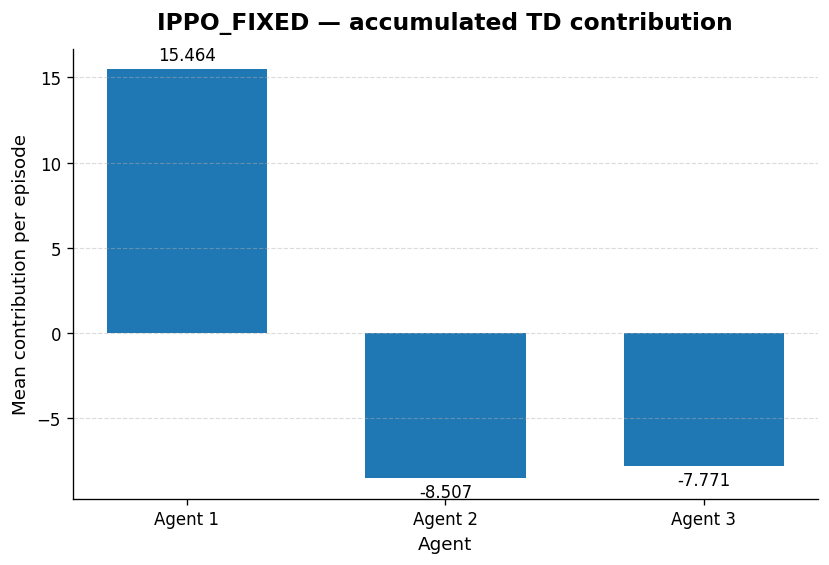

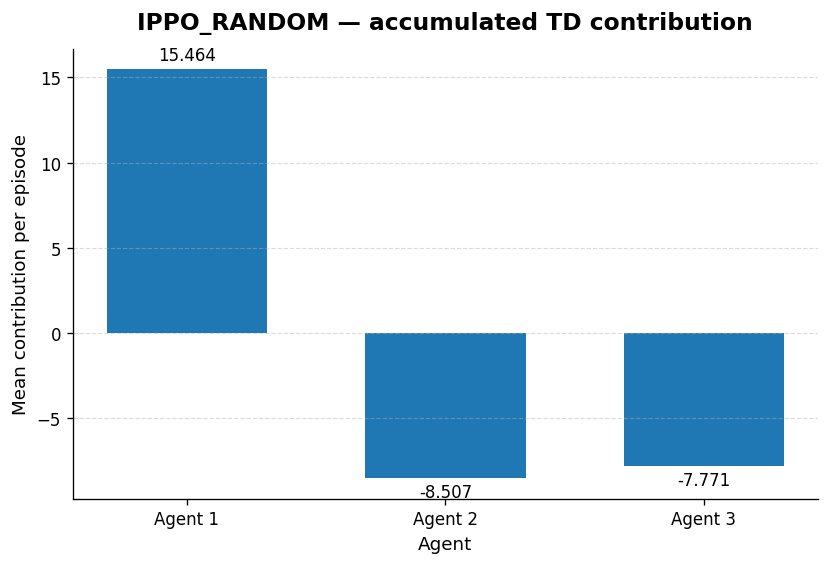

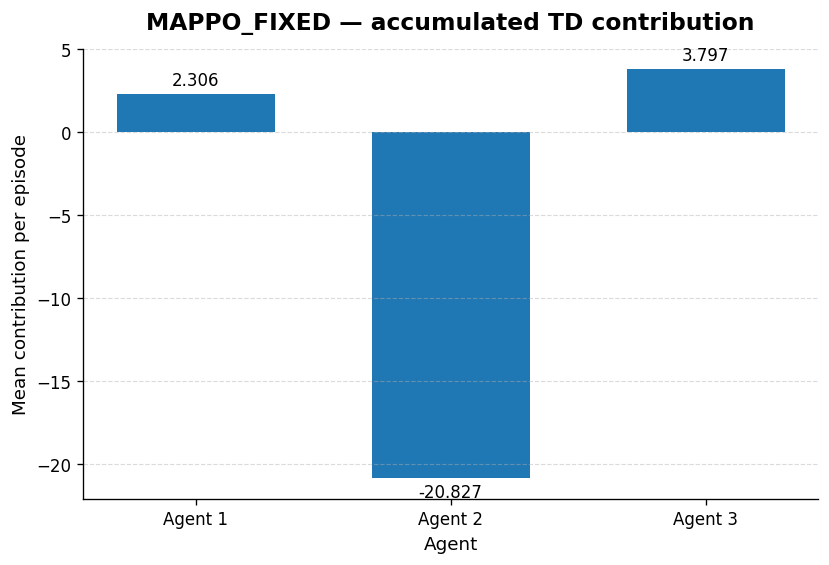

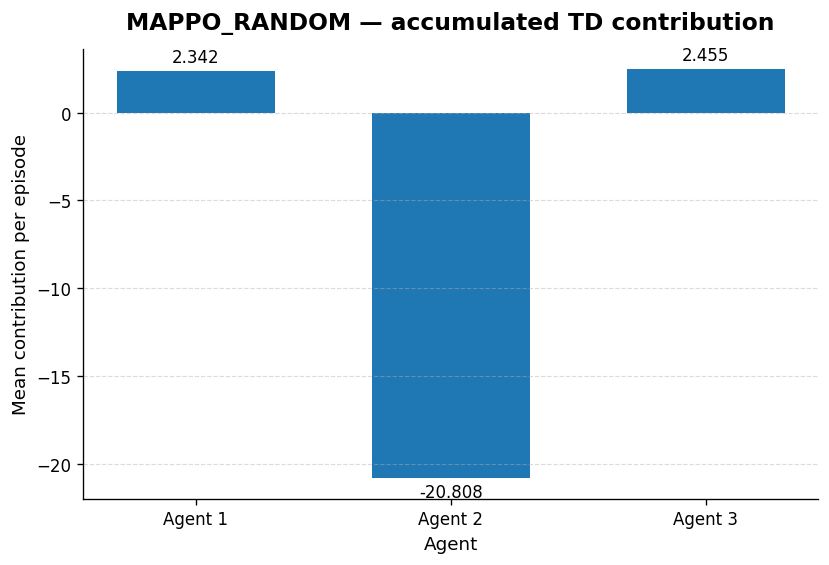

In [267]:
if RUN_TRAINING:
    for label, evaluation in generalisation_evaluations.items():
        mean_contribution = evaluation['contribution'].mean(axis=0)
        figure, axis = plt.subplots(figsize=(6.8, 4.6), constrained_layout=True)
        bars = axis.bar(np.arange(1, NUM_AGENTS + 1), mean_contribution, width=0.62)
        axis.set_xticks([1, 2, 3])
        axis.set_xticklabels(['Agent 1', 'Agent 2', 'Agent 3'])
        axis.bar_label(bars, fmt='%.3f', padding=3)
        finish_axis(
            axis,
            f'{label.upper()} — accumulated TD contribution',
            'Agent',
            'Mean contribution per episode',
            False,
        )
        save_and_show(figure, f'{label}_agent_contribution')

<a id="t-5-4"></a>

## <a id="t-5-4">5.4: Jensen–Shannon Divergence Pairwise Matrix</a>

In [268]:
def collect_probe_observations(
    count: int,
    seed: int = 123_456,
) -> np.ndarray:
    environment = CleaningGridEnv(
        'random', seed=seed, truncate_on_safety_violation=False
    )
    observations, _ = environment.reset(seed=seed)
    collected: List[np.ndarray] = []

    while len(collected) < count:
        for agent_id in range(NUM_AGENTS):
            collected.append(observations[agent_id].copy())
            if len(collected) >= count:
                break

        actions = environment.rng.integers(
            0, ACTION_DIMENSION, size=NUM_AGENTS
        )
        observations, _, terminated, truncated, _ = environment.step(actions)
        if terminated or truncated:
            observations, _ = environment.reset()

    return np.stack(collected[:count])


def identical_probe_policy_probabilities(
    model,
    probe_observations: np.ndarray,
) -> np.ndarray:
    probe_tensor = torch.as_tensor(
        probe_observations,
        dtype=torch.float32,
        device=model.device,
    )
    probabilities = []

    with torch.no_grad():
        if model.algorithm_name == 'IPPO':
            for agent_id in range(NUM_AGENTS):
                probabilities.append(
                    model.actors[agent_id]
                    .distribution(probe_tensor)
                    .probs.cpu().numpy()
                )
        else:
            for agent_id in range(NUM_AGENTS):
                agent_ids = torch.eye(
                    NUM_AGENTS,
                    dtype=torch.float32,
                    device=model.device,
                )[agent_id].repeat(len(probe_tensor), 1)
                probabilities.append(
                    model.actor
                    .distribution(probe_tensor, agent_ids)
                    .probs.cpu().numpy()
                )

    return np.stack(probabilities)


def jensen_shannon_divergence(
    probability_p: np.ndarray,
    probability_q: np.ndarray,
    epsilon: float = 1e-12,
) -> float:
    probability_p = np.clip(probability_p, epsilon, 1.0)
    probability_q = np.clip(probability_q, epsilon, 1.0)
    mixture = 0.5 * (probability_p + probability_q)
    return float(
        0.5 * np.sum(probability_p * np.log(probability_p / mixture))
        + 0.5 * np.sum(probability_q * np.log(probability_q / mixture))
    )


def pairwise_jsd_matrix(probabilities: np.ndarray) -> np.ndarray:
    matrix = np.zeros((NUM_AGENTS, NUM_AGENTS), dtype=np.float32)
    for first in range(NUM_AGENTS):
        for second in range(first + 1, NUM_AGENTS):
            values = [
                jensen_shannon_divergence(
                    probabilities[first, probe_index],
                    probabilities[second, probe_index],
                )
                for probe_index in range(probabilities.shape[1])
            ]
            matrix[first, second] = matrix[second, first] = np.mean(values)
    return matrix

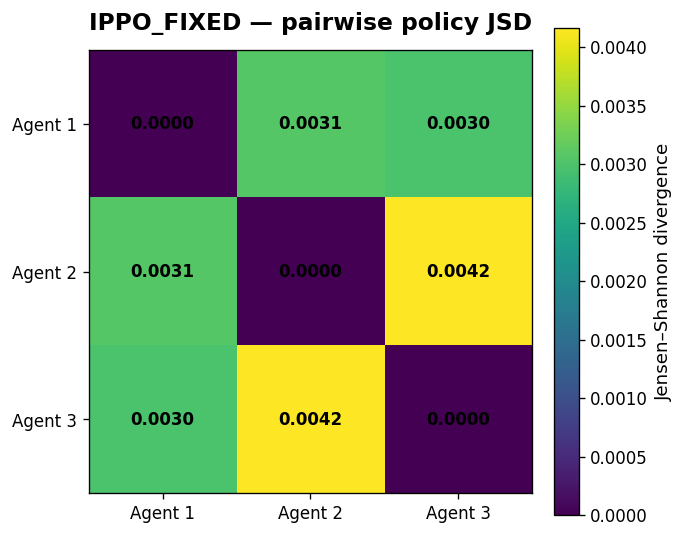

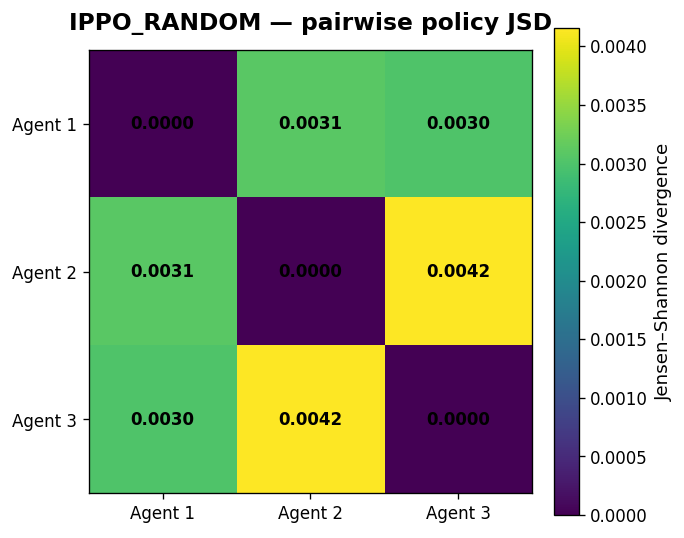

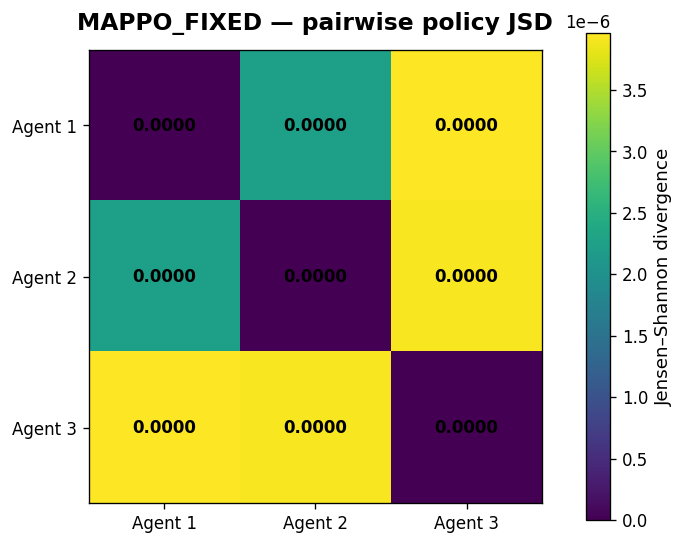

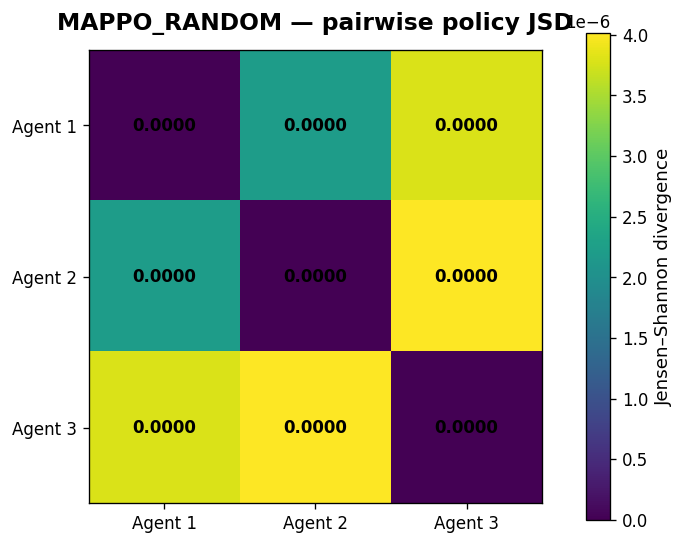

In [269]:
jsd_matrices: Dict[str, np.ndarray] = {}

if RUN_TRAINING:
    probe_observations = collect_probe_observations(
        EXPERIMENT_CONFIG.probe_observations
    )

    for label, model in trained_models.items():
        probabilities = identical_probe_policy_probabilities(
            model, probe_observations
        )
        matrix = pairwise_jsd_matrix(probabilities)
        jsd_matrices[label] = matrix

        figure, axis = plt.subplots(figsize=(5.6, 4.8), constrained_layout=True)
        image = axis.imshow(matrix, vmin=0, interpolation='nearest')
        axis.set_xticks(range(NUM_AGENTS))
        axis.set_yticks(range(NUM_AGENTS))
        axis.set_xticklabels(['Agent 1', 'Agent 2', 'Agent 3'])
        axis.set_yticklabels(['Agent 1', 'Agent 2', 'Agent 3'])

        for row in range(NUM_AGENTS):
            for col in range(NUM_AGENTS):
                axis.text(
                    col, row, f'{matrix[row, col]:.4f}',
                    ha='center', va='center', fontweight='bold',
                )

        axis.set_title(f'{label.upper()} — pairwise policy JSD', pad=12)
        colour_bar = figure.colorbar(image, ax=axis, shrink=0.86)
        colour_bar.set_label('Jensen–Shannon divergence')
        save_and_show(figure, f'{label}_policy_jsd')

### Paired bootstrap comparison

In [270]:
def bootstrap_mean_difference(
    first: np.ndarray,
    second: np.ndarray,
    samples: int,
    seed: int = 9876,
) -> Tuple[float, float, float]:
    if len(first) != len(second):
        raise ValueError('Paired arrays must have the same length.')

    differences = np.asarray(first) - np.asarray(second)
    rng = np.random.default_rng(seed)
    bootstrap_means = np.empty(samples, dtype=float)

    for sample_index in range(samples):
        indices = rng.integers(0, len(differences), size=len(differences))
        bootstrap_means[sample_index] = differences[indices].mean()

    lower, upper = np.percentile(bootstrap_means, [2.5, 97.5])
    return float(differences.mean()), float(lower), float(upper)


if RUN_TRAINING:
    comparisons = []
    reference = generalisation_evaluations['ippo_random']
    candidate = generalisation_evaluations['mappo_random']

    for metric, label in (
        ('team_return', 'Team return'),
        ('completion_rate', 'Weighted completion'),
        ('global_rcr', 'Global RCR'),
        ('safety_violation', 'Violation rate'),
    ):
        mean_difference, lower, upper = bootstrap_mean_difference(
            candidate[metric],
            reference[metric],
            EXPERIMENT_CONFIG.bootstrap_samples,
        )
        comparisons.append({
            'Metric': label,
            'MAPPO random − IPPO random': mean_difference,
            '95% CI lower': lower,
            '95% CI upper': upper,
        })

    display(pd.DataFrame(comparisons).round(4))

,Metric,MAPPO random − IPPO random,95% CI lower,95% CI upper
0,Team return,-16.5000,-20.5000,-12.5000
1,Weighted completion,-0.0833,-0.1667,0.0000
2,Global RCR,-0.1667,-0.1667,-0.1667
3,Violation rate,0.0000,0.0000,0.0000


### Integrated comparison

In [271]:
if RUN_TRAINING:
    integrated_rows = []

    for label, evaluation in (
        generalisation_evaluations.items()
    ):
        successful_lengths = (
            evaluation[
                "episode_length"
            ][
                evaluation[
                    "full_success"
                ] > 0
            ]
        )

        contribution_vector = (
            evaluation[
                "contribution"
            ].mean(axis=0)
        )

        jsd_matrix = (
            jsd_matrices[label]
        )
        mean_pairwise_jsd = float(
            jsd_matrix[
                np.triu_indices(
                    NUM_AGENTS,
                    k=1,
                )
            ].mean()
        )

        integrated_rows.append({
            "Model": label,
            "Team return": float(
                evaluation[
                    "team_return"
                ].mean()
            ),
            "Weighted completion": float(
                evaluation[
                    "completion_rate"
                ].mean()
            ),
            "Full success": float(
                evaluation[
                    "full_success"
                ].mean()
            ),
            "Successful length": (
                float(
                    successful_lengths.mean()
                )
                if len(successful_lengths)
                else np.nan
            ),
            "Safety violation": float(
                evaluation[
                    "safety_violation"
                ].mean()
            ),
            "Global RCR": float(
                evaluation[
                    "global_rcr"
                ].mean()
            ),
            "Contribution spread": float(
                contribution_vector.max()
                - contribution_vector.min()
            ),
            "Mean pairwise JSD": (
                mean_pairwise_jsd
            ),
        })

    integrated_comparison = (
        pd.DataFrame(
            integrated_rows
        )
    )

    display(
        integrated_comparison.style.format(
            precision=4,
            na_rep="N/A",
        )
    )

    integrated_comparison.to_csv(
        DATA_DIR
        / "task_5_integrated_comparison.csv",
        index=False,
    )

,Model,Team return,Weighted completion,Full success,Successful length,Safety violation,Global RCR,Contribution spread,Mean pairwise JSD
0,ippo_fixed,-0.8000,0.0833,0.0000,N/A,1.0000,0.3333,23.9707,0.0034
1,ippo_random,-0.8000,0.0833,0.0000,N/A,1.0000,0.3333,23.9711,0.0034
2,mappo_fixed,-15.9667,0.0278,0.0000,N/A,1.0000,0.1667,24.6247,0.0000
3,mappo_random,-17.3000,0.0000,0.0000,N/A,1.0000,0.1667,23.2630,0.0000
